# Solutions — AI for Power & Energy Systems

> **Instructor / self-check version.** Every task below is worked through in full, with an explanation of *why* the implementation looks the way it does.
>
> If you are a student: attempt the exercise first. Reading a solution feels like learning and is not — the gap between recognising a correct answer and producing one is the entire skill this course is trying to build.

Ten chapters, one per tutorial, 51 tasks in total.

Work them in order. Ideas carry forward — chapter 06 assumes you derived
attention in chapter 05, chapter 10 assumes you masked something in
chapter 04 — but *code* dependencies stay inside a chapter, so you can run
one chapter without having done the previous one. Any task that reuses an
earlier task's code says which, in its own prompt.

### Task types

| Type | What it asks for |
| --- | --- |
| **Coding Task** (34) | Implement something. The scaffold shows the shape; you write the body. |
| **Analysis Task** (9) | Run an experiment and interpret the numbers. Partly code, mostly judgement. |
| **Reflection Question** (8) | Write an argument. No code. Worth discussing with someone. |

### Difficulty

| | Meaning |
| --- | --- |
| ★ | Direct application of something the tutorial showed. |
| ★★ | Requires combining two ideas, or getting an index right. |
| ★★★ | Open-ended, or the correct answer is not the obvious one. |

### Chapters

| # | Topic | Builds on | Tasks | Hardest |
| --- | --- | --- | --- | --- |
| 01 | Classical Machine Learning | [`01_classical_machine_learning.ipynb`](01_classical_machine_learning.ipynb) | 5 | ★★ |
| 02 | Neural Networks | [`02_neural_networks.ipynb`](02_neural_networks.ipynb) | 4 | ★★ |
| 03 | RNNs and LSTMs | [`03_rnns_and_lstms.ipynb`](03_rnns_and_lstms.ipynb) | 4 | ★★★ |
| 04 | Representation Learning | [`04_representation_learning.ipynb`](04_representation_learning.ipynb) | 4 | ★★★ |
| 05 | Attention | [`05_attention.ipynb`](05_attention.ipynb) | 4 | ★★★ |
| 06 | Transformers | [`06_transformers.ipynb`](06_transformers.ipynb) | 4 | ★★★ |
| 07 | Language Models | [`07_language_models.ipynb`](07_language_models.ipynb) | 5 | ★★★ |
| 08 | Pretrained LLMs and Adaptation | [`08_pretrained_llms_and_adaptation.ipynb`](08_pretrained_llms_and_adaptation.ipynb) | 4 | ★★★ |
| 09 | Foundation Models Beyond LLMs | [`09_foundation_models_beyond_llms.ipynb`](09_foundation_models_beyond_llms.ipynb) | 4 | ★★★ |
| 10 | Towards Grid Foundation Models | [`10_grid_foundation_models.ipynb`](10_grid_foundation_models.ipynb) | 6 | ★★★ |
| 11 | Federated Learning and Federated Foundation Models | [`11_federated_learning_and_foundation_models.ipynb`](11_federated_learning_and_foundation_models.ipynb) | 7 | ★★★ |

### Before you start

The environment is the course's own: `uv sync`, then select the
`ai-power-systems-course` kernel. Chapters 08 and 09 download pretrained
models the first time they run; set `AI_POWER_COURSE_OFFLINE=1` to skip
those cells and `AI_POWER_COURSE_FAST=1` to shrink every training budget.

In [1]:
# Shared imports and the reproducibility seed. Every chapter below
# re-imports what it needs, so chapters can also be run in isolation.
import numpy as np
import pandas as pd
import torch

from ai_power_course.config import fast_mode, offline_mode, set_seed
from ai_power_course.plotting import use_course_style

use_course_style()
set_seed()

print(f"reduced (fast) configuration: {fast_mode()} | offline: {offline_mode()}")
print("Every result below is seeded. If a number differs from a neighbour's,")
print("it is because one of you changed something — which is the point.")

reduced (fast) configuration: False | offline: False
Every result below is seeded. If a number differs from a neighbour's,
it is because one of you changed something — which is the point.


---

## Exercise 01 — Classical Machine Learning

*Builds on [`01_classical_machine_learning.ipynb`](01_classical_machine_learning.ipynb).*

Before any neural network, the discipline: framing the problem, splitting
the data so the split cannot lie to you, and building a baseline worth
beating.

The running problem for the whole exercise track is **day-ahead system load
forecasting** — predict the load 24 hours after the moment the forecast is
made. Every later chapter attacks the same problem with a different tool, so
the numbers are comparable throughout.

In [2]:
from ai_power_course.config import set_seed
from ai_power_course.data import load_energy_data, make_supervised, time_split
from ai_power_course.metrics import mae, rmse

set_seed()
dataset = load_energy_data()
print(dataset.describe())

frame = dataset.frame
HORIZON = 24
train_raw, valid_raw, test_raw = time_split(frame)
print(f"\ntrain {len(train_raw):,} h | validation {len(valid_raw):,} h | "
      f"test {len(test_raw):,} h")

DATA PROVENANCE: SIMULATED (not measurements)
  source   : synthetic
  title    : Synthetic European power-system time series (ai_power_course.synthetic)
  license  : MIT (generated by this repository)
  cite as  : Generated by ai_power_course.synthetic.generate_energy_frame, seed 20260101.
  notes    : Physically motivated simulation. Magnitudes are tuned to resemble Germany (~479 TWh/a load, PV CF 0.12, wind CF 0.20) but no value is a measurement.
rows      : 35,064 (2017-01-01 to 2020-12-31, h)
columns   : load_mw, pv_mw, wind_mw, residual_load_mw, price_eur_mwh, temperature_c, wind_speed_ms, clear_sky_index, is_night, is_weekend, is_holiday

train 17,520 h | validation 8,760 h | test 8,784 h


### Analysis Task 1.1 ★ — Inspect the dataset and find its structure

A forecasting model is a bet about structure. Before choosing one,
find out what structure is actually there. This dataset is hourly and
has three seasonalities and a weather driver; you should be able to
see all four.

**Your task.** Produce a two-panel figure: the mean load by hour of day (weekday
versus weekend on the same axes) and the mean load by month. Then
print the annual energy in TWh.

**Requirements**

- Use `frame`, which is already loaded.
- Both panels need axis labels and a title.
- Group with pandas rather than looping over rows.

<details><summary><b>Hints</b></summary>

- `frame.index` is a tz-aware `DatetimeIndex`, so `frame.index.hour` and `frame.index.month` are available directly.
- `frame.groupby([a, b]).load_mw.mean().unstack()` gives you a frame with one column per group.

</details>

**Expected outcome.** A double daily peak, a visibly lower weekend profile, and a winter
maximum. The annual energy should be on the order of a few hundred
TWh — this dataset is scaled to resemble Germany.

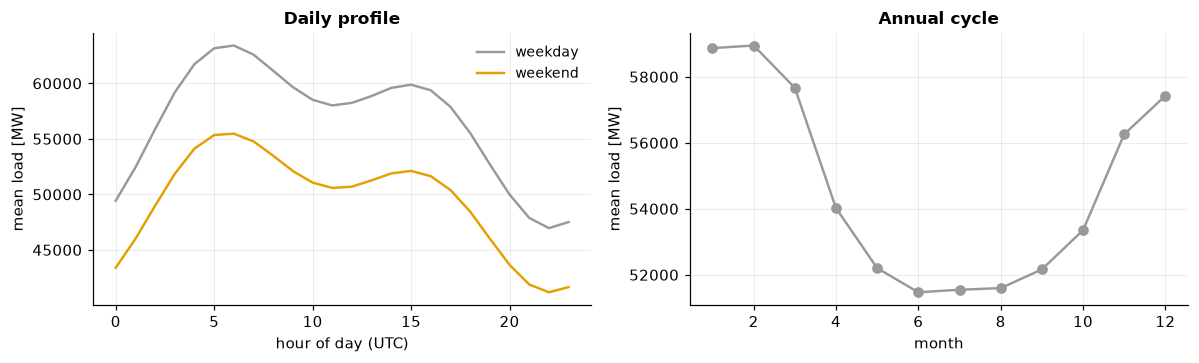

annual load energy: 479 TWh/a
weekday/weekend ratio at 08:00: 1.14


In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

hourly = (
    frame.groupby([frame.index.dayofweek >= 5, frame.index.hour])
    .load_mw.mean()
    .unstack(0)
)
axes[0].plot(hourly.index, hourly[False], label="weekday")
axes[0].plot(hourly.index, hourly[True], label="weekend")
axes[0].set_xlabel("hour of day (UTC)")
axes[0].set_ylabel("mean load [MW]")
axes[0].set_title("Daily profile")
axes[0].legend()

monthly = frame.groupby(frame.index.month).load_mw.mean()
axes[1].plot(monthly.index, monthly.to_numpy(), marker="o")
axes[1].set_xlabel("month")
axes[1].set_ylabel("mean load [MW]")
axes[1].set_title("Annual cycle")

fig.tight_layout()
plt.show()

years = (frame.index[-1] - frame.index[0]).days / 365.25
annual_twh = frame.load_mw.sum() / 1e6 / years
print(f"annual load energy: {annual_twh:.0f} TWh/a")
print(f"weekday/weekend ratio at 08:00: "
      f"{hourly.loc[8, False] / hourly.loc[8, True]:.2f}")

**Why this works.**

`groupby` on two keys then `unstack(0)` turns the boolean weekend key
into two columns, which is what lets both profiles go on one axis
without a loop.

Dividing the summed MW by `1e6` gives TWh because the data is hourly:
one MW held for one hour is one MWh. If the resolution were 15
minutes you would need a factor of 4, and forgetting it is one of the
most common unit errors in energy analysis.

### Coding Task 1.2 ★ — Build a leakage-free temporal split

A random train/test split of a time series lets the model interpolate
between neighbouring hours it has already memorised. The score goes
up, the model does not get better, and nothing warns you.

Tutorial 01 measured the damage: a shuffled split flattered a
1-nearest-neighbour model by 30%.

**Your task.** Build the supervised tables for all three splits using
`make_supervised`, then verify by hand that no feature uses
information from after the forecast origin.

**Requirements**

- Produce `X_train, y_train, X_valid, y_valid, X_test, y_test`.
- Use `horizon=HORIZON` and pass `temperature_c` as an exogenous feature.
- The verification must compare against the raw series, not against another function from the same module.

<details><summary><b>Hints</b></summary>

- `make_supervised(part, horizon=..., exogenous=(...))` returns `(X, y)`.
- Row `t` is the forecast origin: `load_mw_lag0` is the load *at* `t`, and `y` is the load at `t + horizon`.

</details>

**Expected outcome.** Three aligned tables with no missing values, and three assertions that
pass. If an assertion fails, the features and the target are
misaligned — fix that before training anything.

In [4]:
import numpy as np

EXOGENOUS = ("temperature_c",)

X_train, y_train = make_supervised(train_raw, horizon=HORIZON, exogenous=EXOGENOUS)
X_valid, y_valid = make_supervised(valid_raw, horizon=HORIZON, exogenous=EXOGENOUS)
X_test, y_test = make_supervised(test_raw, horizon=HORIZON, exogenous=EXOGENOUS)

print(f"X_train {X_train.shape} | X_valid {X_valid.shape} | X_test {X_test.shape}")

probe = X_train.index[1000]
series = train_raw.load_mw
position = series.index.get_loc(probe)

assert np.isclose(X_train.loc[probe, "load_mw_lag0"], series.iloc[position])
assert np.isclose(X_train.loc[probe, "load_mw_lag24"], series.iloc[position - 24])
assert np.isclose(y_train.loc[probe], series.iloc[position + HORIZON])
print("alignment verified against the raw series")

X_train (17328, 26) | X_valid (8568, 26) | X_test (8592, 26)
alignment verified against the raw series


In [5]:
assert not X_train.isna().any().any(), "features contain NaN"
assert len(X_train) == len(y_train), "X and y are not aligned"
assert X_train.index.max() < X_test.index.min(), "the splits overlap in time"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

The convention that makes this work is that lags count from the
*forecast origin*, not from the timestamp being predicted. `lag0` is
the most recent observation the forecaster actually has.

Counting from the predicted timestamp is the classic leak: at a
24-hour horizon, "the value one hour before the target" is not
available when the forecast is made. The feature table would still
build, the model would still train, and the error would be
impossively good.

### Coding Task 1.3 ★ — Persistence and seasonal-naive baselines

A forecast is only as good as what it beats, and "better than the
mean" is not an achievement on a series with a daily cycle.

Note an identity that catches people out: on hourly data at a
24-hour horizon, persistence and a 24-hour seasonal naive are the
*same* forecast.

*Reuses what you wrote in 1.2 — do those first.*

**Your task.** Implement a persistence forecast — the predicted load at the target
time equals the load observed at the forecast origin — and a weekly
seasonal naive. Score both.

**Requirements**

- Both must return a `pandas.Series` indexed by the forecast origins in `y_test.index`.
- Neither may use a value from after the origin.
- Report MAE and RMSE for each.

<details><summary><b>Hints</b></summary>

- `frame.load_mw.index.get_indexer(origins)` converts timestamps to integer positions you can offset.
- For a weekly naive at horizon h, the value you want sits `168 - h` steps before the origin.

</details>

**Expected outcome.** The weekly naive should clearly beat persistence: knowing the weekday
matters more at a 24-hour horizon than knowing the last value. Both
should be far better than predicting the training mean.

In [6]:
import pandas as pd

history = frame.load_mw
origins = y_test.index
positions = history.index.get_indexer(origins)

def persistence_forecast(history, origins, horizon):
    """Predict y[t + horizon] as the value observed at t."""
    positions = history.index.get_indexer(origins)
    return pd.Series(history.to_numpy()[positions], index=origins)

def weekly_naive_forecast(history, origins, horizon, season=168):
    """Predict y[t + horizon] as y[t + horizon - season]."""
    if season < horizon:
        raise ValueError("season must be at least the horizon, or this leaks")
    positions = history.index.get_indexer(origins)
    return pd.Series(history.to_numpy()[positions - (season - horizon)], index=origins)

baseline = {
    "persistence": persistence_forecast(history, origins, HORIZON),
    "seasonal naive (168 h)": weekly_naive_forecast(history, origins, HORIZON),
    "training mean": pd.Series(y_train.mean(), index=origins),
}
for name, prediction in baseline.items():
    print(f"{name:24s} MAE {mae(y_test, prediction):8,.1f} MW   "
          f"RMSE {rmse(y_test, prediction):8,.1f} MW")

persistence              MAE  3,358.2 MW   RMSE  4,600.2 MW
seasonal naive (168 h)   MAE  2,219.0 MW   RMSE  2,953.0 MW
training mean            MAE  5,549.6 MW   RMSE  6,852.0 MW


In [7]:
for _name, _p in baseline.items():
    assert _p.index.equals(y_test.index), f"{_name} is not aligned to the origins"
    assert _p.notna().all(), f"{_name} has gaps"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

The guard in `weekly_naive_forecast` matters. With `season < horizon`
the value you would need is itself in the future, and the "baseline"
becomes an oracle that no model can beat. Raising is better than
returning a spectacular number.

Persistence does not depend on the horizon at all — the last observed
value is the last observed value — which is exactly why its skill
collapses as the horizon grows.

### Coding Task 1.4 ★★ — Linear regression and gradient boosting

Two hypothesis classes on identical features. The linear model is
interpretable and cannot represent the V-shaped temperature response;
the tree ensemble can, and needs no feature scaling.

*Reuses what you wrote in 1.2, 1.3 — do those first.*

**Your task.** Fit a linear regression and a `HistGradientBoostingRegressor` on the
training split, then evaluate both on the test split alongside the
baselines from task 1.3.

**Requirements**

- Scale the features for the linear model with a `Pipeline`, so the scaler is fitted on training data only.
- Use `random_state=0` for the boosting model so the result is reproducible.
- Collect everything into one sorted results table.

<details><summary><b>Hints</b></summary>

- `make_pipeline(StandardScaler(), LinearRegression())` keeps the scaler inside the model, which is what makes cross-validation honest.
- `HistGradientBoostingRegressor(max_iter=..., learning_rate=...)` needs no scaling at all — trees compare, they do not add.

</details>

**Expected outcome.** Both learned models should beat every baseline comfortably. Gradient
boosting should beat the linear model, because the temperature
response and the hour x weekday interaction are exactly what trees
represent well.

In [8]:
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

set_seed()

linear = make_pipeline(StandardScaler(), LinearRegression())
linear.fit(X_train, y_train)

boosting = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.08,
    random_state=0,
)
boosting.fit(X_train, y_train)

predictions = dict(baseline)
predictions["linear regression"] = linear.predict(X_test)
predictions["gradient boosting"] = boosting.predict(X_test)

results = pd.DataFrame(
    {name: {"MAE": mae(y_test, p), "RMSE": rmse(y_test, p)}
     for name, p in predictions.items()}
).T.sort_values("MAE")
display(results.round(1))

,MAE,RMSE
gradient boosting,1766.3,2387.3
linear regression,2066.2,2651.9
seasonal naive (168 h),2219.0,2953.0
persistence,3358.2,4600.2
training mean,5549.6,6852.0


In [9]:
assert results.index[0] in {"gradient boosting", "linear regression"}, \
    "a learned model should top the table — check the feature alignment"
assert results.MAE.min() < results.loc["seasonal naive (168 h)", "MAE"], \
    "the learned models must beat the weekly naive baseline"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

The `Pipeline` is not cosmetic. Fitting a `StandardScaler` on the full
dataset before splitting leaks the test set's mean and variance into
training. It is a small leak, it is almost never caught in review, and
keeping the scaler inside the estimator makes it structurally
impossible.

Gradient boosting needs no scaling because a decision tree only ever
asks "is this feature above that threshold?" — a monotone rescaling
changes nothing.

### Reflection Question 1.5 ★★ — Why does a good model sometimes lose to persistence?

In this notebook the learned models won. In published energy
forecasting results they frequently do not, and the M4 competition
found the same across thousands of series.

**Your task.** Give three distinct mechanisms by which a well-implemented machine
learning model can fail to beat persistence on a real forecasting
task. For each, say what you would measure to detect it.

**Expected outcome.** Good answers separate *problem* properties (the horizon is short, the
series is near-random-walk) from *method* failures (distribution
shift between train and test, a leak in the baseline's favour,
over-tuned hyper-parameters).

**Mechanism 1 — the horizon is too short for anything else to matter.**
At a one-step horizon a load series is close to a random walk: the
best estimate of the next value really is the current one, and the
learnable signal is a small fraction of the variance.
*Detect it:* plot error against lead time. If the model and
persistence converge as the horizon shrinks, this is the explanation,
and the honest report is skill at each horizon rather than one
aggregate number.

**Mechanism 2 — distribution shift between training and test.**
The model has fitted a relationship that no longer holds: new
embedded generation, a tariff change, a pandemic, a mild winter.
Persistence has nothing to be wrong about, so it degrades gracefully
while the model degrades sharply.
*Detect it:* score both on rolling windows through the test period. A
model that wins early and loses late is drifting, not broken. Compare
the feature distributions between the splits.

**Mechanism 3 — the evaluation is not measuring what you think.**
Either the baseline is handicapped (misaligned by one step, which
makes it look worse than it is) or the model is flattered (a leaked
feature, a scaler fitted on everything, hyper-parameters tuned on the
test set). A model that beats a broken baseline has demonstrated
nothing.
*Detect it:* verify the baseline's alignment against the raw series,
as task 1.2 does; hold out a split that is touched exactly once; and
check that the reported gap survives cross-validation, since the
fold-to-fold spread on this dataset is around 9% — larger than many
published improvements.

---

## Exercise 02 — Neural Networks

*Builds on [`02_neural_networks.ipynb`](02_neural_networks.ipynb).*

The same forecasting problem, with the non-linearity learned instead of
engineered. You will write a neuron and a gradient step by hand before
touching `autograd`, because `loss.backward()` should be a convenience, not
a mystery.

In [10]:
import numpy as np
import torch
from torch import nn

from ai_power_course.config import scaled, set_seed
from ai_power_course.data import load_energy_data, make_supervised, time_split
from ai_power_course.metrics import mae, rmse
from ai_power_course.models.training import Standardizer, make_loader

set_seed()
torch.set_num_threads(min(4, torch.get_num_threads()))

frame = load_energy_data().frame
HORIZON = 24
train_raw, valid_raw, test_raw = time_split(frame)
X_train, y_train = make_supervised(train_raw, horizon=HORIZON, exogenous=("temperature_c",))
X_valid, y_valid = make_supervised(valid_raw, horizon=HORIZON, exogenous=("temperature_c",))
X_test, y_test = make_supervised(test_raw, horizon=HORIZON, exogenous=("temperature_c",))

# Networks need standardised inputs AND targets, fitted on training data only.
feature_scaler = Standardizer().fit(X_train.to_numpy())
target_scaler = Standardizer().fit(y_train.to_numpy().reshape(-1, 1))
Xs_train = feature_scaler.transform(X_train.to_numpy())
Xs_valid = feature_scaler.transform(X_valid.to_numpy())
Xs_test = feature_scaler.transform(X_test.to_numpy())
ys_train = target_scaler.transform(y_train.to_numpy().reshape(-1, 1))
ys_valid = target_scaler.transform(y_valid.to_numpy().reshape(-1, 1))

N_FEATURES = Xs_train.shape[1]
print(f"{N_FEATURES} standardised features, {len(Xs_train):,} training rows")

26 standardised features, 17,328 training rows


### Coding Task 2.1 ★ — A neuron, a loss and one gradient step, in NumPy

A neuron is a weighted sum followed by a non-linearity:

$$y = \sigma(\mathbf{w}^\top \mathbf{x} + b)$$

Training it is: measure the error, work out which direction reduces
it, take a small step that way.

**Your task.** Implement the forward pass of a single neuron, the mean squared
error, and one step of gradient descent on the weights — all in
NumPy, with the derivative written out by hand.

**Requirements**

- `neuron(x, w, b)` applies a sigmoid and accepts `x` of shape `(n_samples, n_features)`, returning shape `(n_samples,)`.
- `mse(y_true, y_pred)` returns a scalar.
- `gradient_step` returns the updated `(w, b)`.
- Use NumPy only. No PyTorch in this task.

<details><summary><b>Hints</b></summary>

- For a linear output (no sigmoid) the MSE gradient is `dL/dw = (2/n) * X.T @ (y_pred - y_true)`.
- Build the sigmoid with `1 / (1 + np.exp(-np.clip(z, -500, 500)))` so a large negative `z` does not overflow.

</details>

**Expected outcome.** The loss printed after the step should be lower than the loss before
it. If it rises, the sign of the gradient is flipped or the learning
rate is far too large.

In [11]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def neuron(x, w, b):
    """One neuron: weighted sum, then a sigmoid."""
    return sigmoid(x @ w + b)

def mse(y_true, y_pred):
    return float(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2))

def gradient_step(x, y_true, w, b, learning_rate=0.1):
    """One step of gradient descent on a LINEAR neuron (no sigmoid)."""
    y_pred = x @ w + b
    n = len(y_true)
    residual = y_pred - y_true
    grad_w = (2.0 / n) * (x.T @ residual)
    grad_b = (2.0 / n) * residual.sum()
    return w - learning_rate * grad_w, b - learning_rate * grad_b

rng = np.random.default_rng(0)
x_demo = rng.normal(size=(64, 3))
y_demo = x_demo @ np.array([2.0, -1.0, 0.5]) + 0.3
w, b = np.zeros(3), 0.0

print(f"loss before: {mse(y_demo, x_demo @ w + b):.4f}")
for _ in range(50):
    w, b = gradient_step(x_demo, y_demo, w, b, learning_rate=0.1)
print(f"loss after : {mse(y_demo, x_demo @ w + b):.4f}")
print(f"recovered weights: {w.round(3)} (true: [2.0, -1.0, 0.5])")

loss before: 5.5229
loss after : 0.0000
recovered weights: [ 2.  -1.   0.5] (true: [2.0, -1.0, 0.5])


In [12]:
_x = np.array([[1.0, 2.0]])
_w, _b = np.array([0.5, -0.25]), 0.1
assert np.isclose(neuron(_x, _w, _b)[0], 1 / (1 + np.exp(-0.1)), atol=1e-9)
assert np.isclose(mse([1.0, 2.0], [1.0, 3.0]), 0.5)
assert np.allclose(w, [2.0, -1.0, 0.5], atol=0.05), "gradient descent did not converge"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

The `np.clip` inside the sigmoid is not paranoia: `np.exp(1000)`
overflows to `inf` and the whole array becomes `nan`, silently, on the
first badly-scaled input.

Note that `gradient_step` deliberately drops the sigmoid. With a
sigmoid output and a squared-error loss the gradient carries an extra
`sigma'(z)` factor, which is at most `0.25` and vanishes for large
`|z|` — that is the saturation problem that made deep sigmoid networks
untrainable and pushed the field to ReLU.

### Coding Task 2.2 ★★ — An MLP in PyTorch

Stacking neurons is only worth anything if there is a non-linearity
between the layers. Without one, a composition of linear maps is a
linear map, and a fifty-layer network has exactly the expressive power
of linear regression.

**Your task.** Implement `LoadMLP` as an `nn.Module` with two hidden layers, ReLU
activations and dropout, then confirm it produces the right output
shape.

**Requirements**

- `LoadMLP(n_features, hidden=(128, 64), dropout=0.1)`.
- `forward` takes `(batch, n_features)` and returns `(batch, 1)`.
- Use `nn.Sequential` inside the module.

<details><summary><b>Hints</b></summary>

- The last layer maps to 1 output and must NOT be followed by an activation — the target is an unbounded real number.
- Build the layer list in a loop so the hidden sizes stay configurable.

</details>

**Expected outcome.** A parameter count in the low tens of thousands, and an output of shape
`(batch, 1)`.

In [13]:
class LoadMLP(nn.Module):
    """A multi-layer perceptron for day-ahead load forecasting."""

    def __init__(self, n_features, hidden=(128, 64), dropout=0.1):
        super().__init__()
        layers = []
        in_features = n_features
        for width in hidden:
            layers += [nn.Linear(in_features, width), nn.ReLU(), nn.Dropout(dropout)]
            in_features = width
        layers.append(nn.Linear(in_features, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

set_seed()
model = LoadMLP(N_FEATURES)
print(model)
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

LoadMLP(
  (network): Sequential(
    (0): Linear(in_features=26, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
parameters: 11,777


In [14]:
_out = model(torch.randn(7, N_FEATURES))
assert _out.shape == (7, 1), f"expected (7, 1), got {tuple(_out.shape)}"
assert any(isinstance(m, nn.ReLU) for m in model.modules()), \
    "without a non-linearity this is just linear regression"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

`in_features = width` inside the loop is the line people forget: each
layer's input width is the previous layer's output width, not the
original feature count.

Dropout belongs after the activation, and it is active only in
`model.train()` mode — `model.eval()` turns it off. Forgetting the
mode switch makes evaluation noisy and is a common source of
"my validation score is worse than training for no reason".

### Coding Task 2.3 ★★ — Write the training loop

Four lines, in a specific order, repeated: zero the gradients,
forward, backward, step. Getting the order wrong produces a model
that trains but learns the wrong thing.

*Reuses what you wrote in 2.2 — do those first.*

**Your task.** Complete the training loop and train the MLP for a few epochs,
tracking training and validation loss.

**Requirements**

- Use `nn.MSELoss()` and `torch.optim.AdamW`.
- Switch between `model.train()` and `model.eval()` correctly.
- Evaluate under `torch.no_grad()`.
- Return the two loss curves.

<details><summary><b>Hints</b></summary>

- `optimizer.zero_grad(set_to_none=True)` must come *before* `loss.backward()`, or you accumulate gradients across batches.
- `make_loader(X, y, batch_size=..., shuffle=True)` is already imported.

</details>

**Expected outcome.** Both curves should fall. If the validation curve turns upward while
the training curve keeps falling, that gap is overfitting — and it is
what early stopping exists to catch.

In [15]:
def train_epoch(model, loader, loss_fn, optimizer):
    model.train()
    total, count = 0.0, 0
    for features, target in loader:
        prediction = model(features)
        loss = loss_fn(prediction, target)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        total += float(loss.detach()) * len(features)
        count += len(features)
    return total / count

@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    total, count = 0.0, 0
    for features, target in loader:
        loss = loss_fn(model(features), target)
        total += float(loss) * len(features)
        count += len(features)
    return total / count

set_seed()
model = LoadMLP(N_FEATURES)
loss_fn = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
train_loader = make_loader(Xs_train, ys_train, batch_size=64, shuffle=True)
valid_loader = make_loader(Xs_valid, ys_valid, batch_size=256)

EPOCHS = scaled(full=12, fast=2)
history = {"train": [], "validation": []}
for epoch in range(EPOCHS):
    history["train"].append(train_epoch(model, train_loader, loss_fn, optimizer))
    history["validation"].append(evaluate(model, valid_loader, loss_fn))
    print(f"epoch {epoch + 1:2d}  train {history['train'][-1]:.5f}  "
          f"validation {history['validation'][-1]:.5f}")

epoch  1  train 0.17995  validation 0.12817


epoch  2  train 0.11187  validation 0.11415


epoch  3  train 0.10412  validation 0.11009


epoch  4  train 0.09960  validation 0.10702


epoch  5  train 0.09484  validation 0.10560


...

epoch  8  train 0.08901  validation 0.10839


epoch  9  train 0.08803  validation 0.10459


epoch 10  train 0.08614  validation 0.11349


epoch 11  train 0.08574  validation 0.10875


epoch 12  train 0.08315  validation 0.11420


In [16]:
assert history["train"][-1] < history["train"][0], "the training loss did not fall"
assert len(history["validation"]) == EPOCHS
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

`zero_grad` first, because PyTorch *accumulates* gradients by design
(which is what makes gradient accumulation across micro-batches
possible). Skip it and every batch trains on the sum of all gradients
so far.

`@torch.no_grad()` on the evaluation function does two things: it
stops the autograd graph being built, which roughly halves the memory,
and it makes it impossible to accidentally train on validation data.

### Analysis Task 2.4 ★★ — Does the network beat gradient boosting?

Tutorial 02 found the two within a few percent of each other — a gap
smaller than the fold-to-fold spread of cross-validation on this
dataset.

*Reuses what you wrote in 2.3 — do those first.*

**Your task.** Evaluate the trained MLP on the test set in megawatts, compare it
against gradient boosting trained on the same features, and report
both the accuracy gap and the training-time gap.

**Requirements**

- Invert the target standardisation before computing MAE — a score in standardised units is not interpretable.
- Time both fits.
- Print the relative difference in MAE with an explicit direction.

<details><summary><b>Hints</b></summary>

- `target_scaler.inverse_transform(...)` takes the model output back to megawatts.
- Put the model in `eval()` mode before predicting.

</details>

**Expected outcome.** A few percent between them either way, and a much larger factor in
training time. The point of the comparison is the *ratio of effort to
payoff*, not the winner.

In [17]:
import time

from sklearn.ensemble import HistGradientBoostingRegressor

model.eval()
with torch.no_grad():
    mlp_scaled = model(torch.tensor(Xs_test, dtype=torch.float32)).numpy()
mlp_prediction = target_scaler.inverse_transform(mlp_scaled).ravel()

started = time.perf_counter()
boosting = HistGradientBoostingRegressor(max_iter=200, random_state=0)
boosting.fit(X_train, y_train)
boosting_seconds = time.perf_counter() - started
boosting_prediction = boosting.predict(X_test)

print(f"MLP               MAE {mae(y_test, mlp_prediction):8,.1f} MW")
print(f"gradient boosting MAE {mae(y_test, boosting_prediction):8,.1f} MW"
      f"   ({boosting_seconds:.1f}s to fit)")

gap = mae(y_test, mlp_prediction) / mae(y_test, boosting_prediction) - 1
print(f"\nThe MLP's MAE is {abs(gap):.1%} "
      f"{'higher' if gap > 0 else 'lower'} than gradient boosting's.")
print("\nThe reason to adopt neural networks is not this benchmark. It is that")
print("a tree ensemble stores thresholds over YOUR features: there is no hidden")
print("layer to reuse, nothing to transfer, and no way to train it without labels.")

MLP               MAE  1,744.2 MW
gradient boosting MAE  1,776.5 MW   (0.7s to fit)

The MLP's MAE is 1.8% lower than gradient boosting's.

The reason to adopt neural networks is not this benchmark. It is that
a tree ensemble stores thresholds over YOUR features: there is no hidden
layer to reuse, nothing to transfer, and no way to train it without labels.


In [18]:
assert mlp_prediction.shape == y_test.to_numpy().shape, \
    "predictions and targets have different shapes"
assert mae(y_test, mlp_prediction) < 5000, \
    "MAE looks like standardised units — did you invert the target scaler?"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

The shape assertion earns its place: `model(...)` returns `(n, 1)` and
`y_test` is `(n,)`. NumPy will happily broadcast those into an
`(n, n)` matrix and hand you a meaningless average, so `.ravel()` is
load-bearing.

The magnitude assertion catches the other frequent slip: forgetting
`inverse_transform` and reporting an MAE of 0.3 "megawatts".

---

## Exercise 03 — RNNs and LSTMs

*Builds on [`03_rnns_and_lstms.ipynb`](03_rnns_and_lstms.ipynb).*

Until now the models saw a *table* whose columns happened to be called
`lag24`. Here they see the sequence itself. That change is what lets a model
accept a longer history, a different site, or a different variable without
being rebuilt.

In [19]:
import numpy as np
import torch
from torch import nn

from ai_power_course.config import scaled, set_seed
from ai_power_course.data import load_energy_data, time_split
from ai_power_course.metrics import mae, rmse
from ai_power_course.models.training import Standardizer, TrainConfig, make_loader, train_model

set_seed()
torch.set_num_threads(min(4, torch.get_num_threads()))

frame = load_energy_data().frame
train_raw, valid_raw, test_raw = time_split(frame)

CONTEXT, HORIZON = 168, 24
# Stride the training windows: consecutive windows overlap by 167 of 168
# hours, so every fourth origin keeps full coverage at a quarter of the cost.
TRAIN_STRIDE = scaled(full=4, fast=24)
print(f"context {CONTEXT} h, horizon {HORIZON} h, training stride {TRAIN_STRIDE}")

context 168 h, horizon 24 h, training stride 4


### Coding Task 3.1 ★★ — Slice a series into supervised windows

A sequence model consumes fixed-length windows: `context` steps of
history in, `horizon` steps of future out. Building them is pure index
arithmetic, and getting it wrong by one step is the most common bug in
the whole field.

**Your task.** Implement `create_sequences`, returning inputs of shape
`(n_windows, context, 1)` and targets of shape `(n_windows, horizon)`.

**Requirements**

- Window `i` covers `series[i : i + context]`.
- Its target is `series[i + context : i + context + horizon]`.
- Support a `stride` so windows can be subsampled.
- Return float32 arrays.

<details><summary><b>Hints</b></summary>

- The last valid start index is `len(series) - context - horizon`.
- `np.stack([...])` over a list comprehension is clear and fast enough here.

</details>

**Expected outcome.** The assertion cell should pass, and the window count should be roughly
`(len(series) - context - horizon) / stride`.

In [20]:
def create_sequences(series, context, horizon, stride=1):
    """Slice a 1-D series into (context, horizon) supervised windows.

    Returns
    -------
    x : (n_windows, context, 1) float32
    y : (n_windows, horizon)    float32
    """
    values = np.asarray(series, dtype=np.float32).reshape(-1)
    last_start = len(values) - context - horizon
    if last_start < 0:
        raise ValueError("series is too short for this context and horizon")
    starts = np.arange(0, last_start + 1, stride)
    x = np.stack([values[s : s + context] for s in starts])[:, :, None]
    y = np.stack([values[s + context : s + context + horizon] for s in starts])
    return x.astype(np.float32), y.astype(np.float32)

x_train, y_train_seq = create_sequences(
    train_raw.load_mw, CONTEXT, HORIZON, stride=TRAIN_STRIDE)
x_valid, y_valid_seq = create_sequences(
    valid_raw.load_mw, CONTEXT, HORIZON, stride=TRAIN_STRIDE)
x_test, y_test_seq = create_sequences(test_raw.load_mw, CONTEXT, HORIZON, stride=1)

print(f"x_train {x_train.shape}  y_train {y_train_seq.shape}")
print(f"x_test  {x_test.shape}  y_test  {y_test_seq.shape}")

x_train (4333, 168, 1)  y_train (4333, 24)
x_test  (8593, 168, 1)  y_test  (8593, 24)


In [21]:
_v = np.arange(100, dtype=np.float32)
_x, _y = create_sequences(_v, context=10, horizon=3)
assert _x.shape == (88, 10, 1), f"got {_x.shape}, expected (88, 10, 1)"
assert _y.shape == (88, 3), f"got {_y.shape}, expected (88, 3)"
assert np.allclose(_x[5, :, 0], np.arange(5, 15)), "window contents are misaligned"
assert np.allclose(_y[5], np.arange(15, 18)), "targets are misaligned"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

The trailing `[:, :, None]` adds the channel axis. PyTorch's recurrent
and attention layers expect `(batch, sequence, features)`, and a
univariate series has one feature — but the axis still has to be
there, or `nn.LSTM` reads your sequence length as a feature count.

`last_start = len(values) - context - horizon` is inclusive, hence the
`+ 1` in `arange`. Off-by-one here silently drops the final window,
which is exactly the most recent data you have.

### Analysis Task 3.2 ★ — Tensor shapes through a recurrent model

Most time lost to sequence models is lost to shapes. Predicting them
before running anything is a skill worth ten debugging sessions.

**Your task.** Fill in the expected shape at each stage of a forward pass, then check
your answers against a real `nn.LSTM`.

**Requirements**

- Write each expected shape as a tuple before running the check.
- Explain in one line why the hidden state has no sequence axis.

<details><summary><b>Hints</b></summary>

- `nn.LSTM(..., batch_first=True)` returns `(output, (h_n, c_n))`.
- `h_n` has shape `(num_layers, batch, hidden_size)` regardless of `batch_first`.

</details>

**Expected outcome.** All four assertions pass. The output keeps the sequence axis; the final
hidden state does not, because it is a summary of the whole sequence.

In [22]:
BATCH, HIDDEN = 8, 32

expected_input_shape = (BATCH, CONTEXT, 1)
expected_output_shape = (BATCH, CONTEXT, HIDDEN)
expected_hidden_shape = (1, BATCH, HIDDEN)      # (num_layers, batch, hidden)
expected_prediction_shape = (BATCH, HORIZON)

lstm = nn.LSTM(input_size=1, hidden_size=HIDDEN, num_layers=1, batch_first=True)
head = nn.Linear(HIDDEN, HORIZON)
sample = torch.randn(BATCH, CONTEXT, 1)

output, (h_n, c_n) = lstm(sample)
prediction = head(h_n[-1])

assert tuple(sample.shape) == expected_input_shape
assert tuple(output.shape) == expected_output_shape
assert tuple(h_n.shape) == expected_hidden_shape
assert tuple(prediction.shape) == expected_prediction_shape
print("All four shapes correct.")
print("\nh_n has no sequence axis because it is the state AFTER the last step —")
print("one vector summarising the whole window, which is what the head decodes.")

All four shapes correct.

h_n has no sequence axis because it is the state AFTER the last step —
one vector summarising the whole window, which is what the head decodes.


**Why this works.**

`batch_first=True` swaps the first two axes of the *input and output*
but deliberately not of `h_n` and `c_n`, which keep
`(num_layers, batch, hidden)`. That inconsistency is a genuine wart in
the PyTorch API and it catches everyone once.

`h_n[-1]` takes the last layer's final state. For a single-layer LSTM
it is equivalent to `output[:, -1, :]`; for a stacked one it is not,
and the difference matters.

### Coding Task 3.3 ★★ — Build and train an LSTM forecaster

The LSTM's cell state is an *additive* path through time, which is why
a gradient can survive hundreds of steps instead of decaying
geometrically. That is the whole reason it displaced the vanilla RNN.

*Reuses what you wrote in 3.1 — do those first.*

**Your task.** Implement `LoadLSTM` as a sequence-to-one model that decodes the final
hidden state into the whole horizon, then train it on the standardised
windows.

**Requirements**

- `LoadLSTM(n_channels, hidden_size, horizon)`.
- `forward` takes `(batch, context, n_channels)` and returns `(batch, horizon)`.
- Train with the package's `train_model`, which handles early stopping and restores the best weights.

<details><summary><b>Hints</b></summary>

- Standardise using statistics from the *training* windows only.
- Decode `h_n[-1]` with a `nn.Linear(hidden_size, horizon)`.

</details>

**Expected outcome.** A validation loss that falls and then flattens. Early stopping should
fire before the epoch budget runs out.

In [23]:
scaler = Standardizer().fit(x_train.reshape(-1, 1))
xs_train = scaler.transform(x_train)
xs_valid = scaler.transform(x_valid)
xs_test = scaler.transform(x_test)

target_scaler = Standardizer().fit(y_train_seq)
ys_train = target_scaler.transform(y_train_seq)
ys_valid = target_scaler.transform(y_valid_seq)

class LoadLSTM(nn.Module):
    def __init__(self, n_channels=1, hidden_size=64, horizon=HORIZON):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_channels, hidden_size=hidden_size,
            num_layers=1, batch_first=True,
        )
        self.head = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        _output, (h_n, _c_n) = self.lstm(x)
        return self.head(h_n[-1])

set_seed()
lstm_model = LoadLSTM()
history = train_model(
    lstm_model,
    make_loader(xs_train, ys_train, batch_size=64, shuffle=True),
    make_loader(xs_valid, ys_valid, batch_size=256),
    loss_fn=nn.MSELoss(),
    config=TrainConfig(epochs=scaled(full=25, fast=2), learning_rate=2e-3,
                       patience=5, verbose=False),
)
print(f"best epoch {history.best_epoch}, "
      f"validation MSE {history.best_val_loss:.5f}, {history.seconds:.0f}s")

best epoch 23, validation MSE 0.12512, 35s


In [24]:
_out = lstm_model(torch.randn(3, CONTEXT, 1))
assert _out.shape == (3, HORIZON), f"got {tuple(_out.shape)}, expected (3, {HORIZON})"
assert history.train_loss[-1] < history.train_loss[0], "training loss did not fall"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

Decoding the *whole* horizon in one shot ("direct" multi-horizon) is a
deliberate choice over predicting one step and feeding it back
("recursive"). Direct forecasting avoids compounding its own errors;
recursive forecasting reuses one model for any horizon but drifts.
Compare their per-lead-time curves and the difference is unmistakable.

The two separate scalers matter: the input scaler is fitted on the
flattened window values, the target scaler on the horizon matrix.
Reusing one for both works here only because both are the same
quantity — it would be wrong the moment you add covariates.

### Analysis Task 3.4 ★★★ — Where does the LSTM actually fail?

An aggregate MAE is an average over very different regimes. Tutorial
03 tested two hypotheses about *when* the model struggles, and one of
them was wrong — which is worth more than the one that held.

*Reuses what you wrote in 3.1, 3.3 — do those first.*

**Your task.** Score the LSTM against persistence on the test windows, then test
whether the error is predicted by (a) how volatile the recent past was
and (b) how unusual the target hour is for its calendar slot.

**Requirements**

- Report MAE at `t+24` for both the LSTM and persistence.
- Compute a correlation for each hypothesis.
- State which hypothesis survived, using the numbers.

<details><summary><b>Hints</b></summary>

- Recent volatility: the largest absolute hour-to-hour change in the last 24 hours of the context window.
- Unusualness: the absolute deviation of the target from the training mean for that (hour, weekday) slot.

</details>

**Expected outcome.** One of the two correlations should be clearly stronger. Report the one
that failed as well — a negative result about your own hypothesis is a
result.

In [25]:
import pandas as pd

lstm_model.eval()
with torch.no_grad():
    scaled_prediction = lstm_model(torch.tensor(xs_test, dtype=torch.float32)).numpy()
lstm_prediction = target_scaler.inverse_transform(scaled_prediction)

truth = y_test_seq[:, -1]                  # the load at t+24
lstm_point = lstm_prediction[:, -1]
persistence_point = x_test[:, -1, 0]       # the load at the origin

print(f"LSTM        MAE {mae(truth, lstm_point):8,.1f} MW")
print(f"persistence MAE {mae(truth, persistence_point):8,.1f} MW")

errors = np.abs(lstm_point - truth)

recent_volatility = np.abs(np.diff(x_test[:, -24:, 0], axis=1)).max(axis=1)

target_index = test_raw.index[CONTEXT + HORIZON - 1 :][: len(truth)]
profile = train_raw.load_mw.groupby(
    [train_raw.index.hour, train_raw.index.dayofweek]).mean()
expected_load = np.array([
    profile.get((h, d), float(train_raw.load_mw.mean()))
    for h, d in zip(target_index.hour, target_index.dayofweek, strict=True)
])
unusualness = np.abs(truth - expected_load)

for label, driver in [("recent volatility", recent_volatility),
                      ("unusualness of the target", unusualness)]:
    r = np.corrcoef(driver, errors)[0, 1]
    low = errors[driver < np.quantile(driver, 0.25)].mean()
    high = errors[driver > np.quantile(driver, 0.75)].mean()
    print(f"{label:28s} r = {r:+.3f}   "
          f"MAE {low:6,.0f} -> {high:6,.0f} MW across quartiles")

print("\nThe volatility hypothesis does NOT survive: volatile and predictable")
print("are different things, and the most volatile stretches here are winter")
print("weekdays with a large but highly regular daily swing. Unusualness does")
print("survive: the model is a very good climatology-plus-recent-history")
print("machine, and it fails exactly where that description stops fitting.")

LSTM        MAE  2,421.4 MW
persistence MAE  3,358.0 MW


recent volatility            r = -0.086   MAE  2,649 ->  2,132 MW across quartiles
unusualness of the target    r = +0.247   MAE  2,216 ->  3,236 MW across quartiles

The volatility hypothesis does NOT survive: volatile and predictable
are different things, and the most volatile stretches here are winter
weekdays with a large but highly regular daily swing. Unusualness does
survive: the model is a very good climatology-plus-recent-history
machine, and it fails exactly where that description stops fitting.


In [26]:
from ai_power_course.config import fast_mode

assert recent_volatility.shape == errors.shape
assert unusualness.shape == errors.shape
assert np.isfinite(errors).all(), "some predictions are not finite"
if fast_mode():
    print("Reduced configuration: skipping the accuracy check — two epochs")
    print("is not enough training to beat persistence.")
else:
    assert mae(truth, lstm_point) < mae(truth, persistence_point), \
        "the LSTM should beat persistence at a 24 h horizon"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

Reporting the hypothesis that failed is the point of the task. The
intuitive diagnostic — "the model struggles after a turbulent
stretch" — is wrong on this data, and only measuring both told us so.

Note the quartile comparison alongside the correlation. A correlation
coefficient is a single number about a linear relationship; comparing
the mean error in the top and bottom quartile shows the *size* of the
effect, which is what decides whether it matters operationally.

---

## Exercise 04 — Representation Learning

*Builds on [`04_representation_learning.ipynb`](04_representation_learning.ipynb).*

The hinge of the course. Everything so far started from a task. Here you
train a model with **no labels and no task**, then discover its internal
representation is useful for a question it was never shown.

That is the mechanism behind every foundation model in chapters 09 and 10.

In [27]:
import numpy as np
import torch
from torch import nn

from ai_power_course.config import fast_mode, scaled, set_seed
from ai_power_course.data import load_energy_data, time_split
from ai_power_course.metrics import mae, r2

set_seed()
torch.set_num_threads(min(4, torch.get_num_threads()))

frame = load_energy_data().frame
train_raw, valid_raw, test_raw = time_split(frame)

def daily_profiles(part, column="residual_load_mw"):
    """Reshape a split into per-day profiles, normalised to shape only."""
    series = part[column]
    complete = [d for d, g in series.groupby(series.index.date) if len(g) == 24]
    matrix = np.stack([series[series.index.date == d].to_numpy() for d in complete])
    level = matrix.mean(axis=1, keepdims=True)
    spread = matrix.std(axis=1, keepdims=True) + 1e-8
    normalised = ((matrix - level) / spread).astype(np.float32)
    import pandas as pd
    return normalised[:, :, None], pd.to_datetime(complete)

profiles_train, dates_train = daily_profiles(train_raw)
profiles_valid, dates_valid = daily_profiles(valid_raw)
profiles_test, dates_test = daily_profiles(test_raw)
print(f"pretraining profiles {profiles_train.shape} — and not one label among them")

pretraining profiles (730, 24, 1) — and not one label among them


### Coding Task 4.1 ★★ — Mask part of a profile

Self-supervision manufactures a supervised problem out of the data's
own structure: hide part of the input and predict it from the rest.

*Which* part you hide is a modelling decision. Scattered single hours
can be interpolated from their neighbours; a contiguous block cannot,
and a contiguous block is what a communication outage actually looks
like.

**Your task.** Implement both masking strategies and a masked reconstruction loss
that scores **only the hidden positions**.

**Requirements**

- `random_mask(shape, ratio)` returns a boolean tensor, `True` = hidden.
- `block_mask(shape, block)` hides exactly one contiguous run per sample.
- `masked_loss(prediction, target, mask)` ignores visible positions.
- All three accept a `torch.Generator` for reproducibility.

<details><summary><b>Hints</b></summary>

- For the block mask, draw one start per sample and compare against `torch.arange(length)` broadcast over the batch.
- Weight the squared error by the mask and divide by the number of masked *elements*, not by the batch size.

</details>

**Expected outcome.** The block mask should hide exactly `block` positions per sample, and
they should be consecutive. The loss on a perfect reconstruction
should be zero even when most positions are wrong outside the mask.

In [28]:
def random_mask(shape, ratio=0.3, generator=None):
    """Independent Bernoulli mask. True means hidden."""
    if not 0.0 <= ratio < 1.0:
        raise ValueError("ratio must lie in [0, 1)")
    return torch.rand(shape, generator=generator) < ratio

def block_mask(shape, block=6, generator=None):
    """Hide exactly one contiguous run of `block` positions per sample."""
    batch, length = shape
    if not 0 < block <= length:
        raise ValueError("block must fit inside the profile")
    starts = torch.randint(0, length - block + 1, (batch,), generator=generator)
    positions = torch.arange(length).unsqueeze(0)
    starts = starts.unsqueeze(1)
    return (positions >= starts) & (positions < starts + block)

def masked_loss(prediction, target, mask, eps=1e-8):
    """MSE over the masked positions only."""
    weights = mask.unsqueeze(-1).to(prediction.dtype)
    squared_error = (prediction - target) ** 2 * weights
    return squared_error.sum() / (weights.sum() * prediction.shape[-1] + eps)

gen = torch.Generator().manual_seed(0)
m_random = random_mask((100, 24), ratio=0.3, generator=gen)
m_block = block_mask((100, 24), block=6, generator=gen)
print(f"random mask hides {m_random.float().mean():.1%} of positions")
print(f"block mask hides  {m_block.sum(dim=1).float().mean():.1f} positions per day")

random mask hides 30.1% of positions
block mask hides  6.0 positions per day


In [29]:
_g = torch.Generator().manual_seed(1)
_b = block_mask((50, 24), block=6, generator=_g)
assert (_b.sum(dim=1) == 6).all(), "each sample must hide exactly `block` positions"
for _row in _b:
    assert (torch.where(_row)[0].diff() == 1).all(), "the block must be contiguous"
_p, _t = torch.zeros(2, 4, 1), torch.ones(2, 4, 1)
_m = torch.tensor([[True, False, False, False], [False, False, False, True]])
assert abs(float(masked_loss(_p, _t, _m)) - 1.0) < 1e-6, \
    "the loss must ignore visible positions"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

Scoring only the hidden positions is what stops the model winning by
learning the identity function on the parts it can already see. Score
everything and the loss falls beautifully while the representation
learns nothing.

The division by `prediction.shape[-1]` accounts for the channel axis:
`weights.sum()` counts masked *positions*, and each carries
`n_channels` values. Getting that wrong scales the loss by a constant,
which is harmless alone but silently changes the balance if you ever
add a second loss term.

### Coding Task 4.2 ★★ — A masked autoencoder for daily profiles

A plain autoencoder can cheat: with a wide enough bottleneck it
approximates the identity. Masking removes that escape route — you
cannot copy what you cannot see.

*Reuses what you wrote in 4.1 — do those first.*

**Your task.** Build an encoder that compresses a 24-hour profile to a small latent
vector and a decoder that expands it back, then pretrain them on the
masking objective from task 4.1.

**Requirements**

- `ProfileAutoencoder(length=24, latent_dim=8)`.
- `forward(x, mask)` replaces the masked positions with a *learned* mask token before encoding.
- `embed(x)` returns the latent code with no masking, in eval mode.
- Pretraining must use no labels of any kind.

<details><summary><b>Hints</b></summary>

- `nn.Parameter(torch.zeros(1))` gives you a learnable scalar to substitute at masked positions — BERT's `[MASK]`, one number wide.
- `torch.where(mask.unsqueeze(-1), token.expand_as(x), x)` does the substitution without a loop.

</details>

**Expected outcome.** The reconstruction loss should fall by an order of magnitude. The
reconstructions plotted afterwards should follow the shape of the
hidden stretch, not just interpolate a straight line across it.

In [30]:
LATENT = 8

class ProfileAutoencoder(nn.Module):
    def __init__(self, length=24, latent_dim=LATENT, hidden=64):
        super().__init__()
        self.length = length
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(length, hidden),
            nn.GELU(),
            nn.Linear(hidden, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, length),
            nn.Unflatten(1, (length, 1)),
        )
        self.mask_token = nn.Parameter(torch.zeros(1))

    def forward(self, x, mask=None):
        if mask is not None:
            x = torch.where(mask.unsqueeze(-1), self.mask_token.expand_as(x), x)
        return self.decoder(self.encoder(x))

    @torch.no_grad()
    def embed(self, x):
        self.eval()
        return self.encoder(x)

set_seed()
autoencoder = ProfileAutoencoder()
optimizer = torch.optim.AdamW(autoencoder.parameters(), lr=2e-3)
gen = torch.Generator().manual_seed(0)
inputs = torch.tensor(profiles_train)

pretrain_curve = []
for epoch in range(scaled(full=60, fast=5)):
    autoencoder.train()
    order = torch.randperm(len(inputs), generator=gen)
    epoch_loss, seen = 0.0, 0
    for start in range(0, len(order), 64):
        batch = inputs[order[start : start + 64]]
        half = len(batch) // 2
        mask = torch.cat([
            random_mask((half, 24), ratio=0.3, generator=gen),
            block_mask((len(batch) - half, 24), block=6, generator=gen),
        ])
        prediction = autoencoder(batch, mask=mask)
        loss = masked_loss(prediction, batch, mask)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        epoch_loss += float(loss.detach()) * len(batch)
        seen += len(batch)
    pretrain_curve.append(epoch_loss / seen)
print(f"masked reconstruction loss: "
      f"{pretrain_curve[0]:.4f} -> {pretrain_curve[-1]:.4f}")

masked reconstruction loss: 0.8794 -> 0.1498


In [31]:
assert pretrain_curve[-1] < pretrain_curve[0], "the reconstruction loss did not fall"
_z = autoencoder.embed(torch.tensor(profiles_valid[:5]))
assert _z.shape == (5, LATENT), f"expected (5, {LATENT}), got {tuple(_z.shape)}"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

The mask token is *learned* rather than a constant zero. Zero is a
perfectly plausible value for a standardised profile, so a constant
zero would be indistinguishable from real data at that position; a
learned parameter lets the network signal "this one is missing".

Mixing the two masking strategies in each epoch is what most real
recipes do. Random-only masking makes the task too easy (interpolate);
block-only makes it uniformly hard and slows early learning.

### Analysis Task 4.3 ★★★ — Probe what the encoder learned without labels

The strict test of a representation is not whether a 2-D projection
*looks* clustered — it is whether a **linear** model can read a factor
out of it. Those two tests disagree more often than people expect.

*Reuses what you wrote in 4.2 — do those first.*

**Your task.** Project the embeddings to two dimensions with PCA and colour them by a
factor the encoder never saw, then run a linear probe for three
different factors and report which are recoverable.

**Requirements**

- Colour the PCA scatter by the daily PV share.
- Probe at least three factors with a ridge regression, reporting R².
- Use a random split for the probe, and say in one line why that is appropriate here when it was not in chapter 01.

<details><summary><b>Hints</b></summary>

- PV share for a day: that day's PV energy divided by its load energy.
- A negative R² means the probe is worse than predicting the mean — that factor is not linearly present.

</details>

**Expected outcome.** Sun-related factors should come out clearly. At least one factor should
*fail*, and the interesting part of the task is explaining why.

embeddings (730, 8)


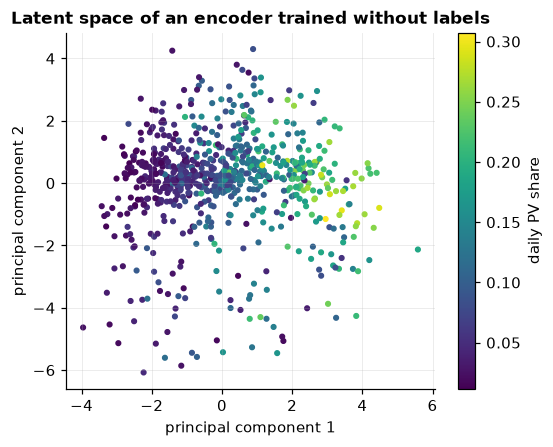

Linear readout from the 8-dimensional embedding:
  daily PV share               R2 =  0.715
  mean temperature             R2 =  0.393
  is it a weekend?             R2 = -0.042

A RANDOM split is right here and wrong in chapter 01. The question is
'is this factor linearly encoded in the representation', which is a probe,
not a forecast. A chronological split would additionally demand that the
probe extrapolate to unseen parts of the year and confound the two.

Sun-related factors are readable. Weekend is not, and the reason is in
the preprocessing: we normalised every day to zero mean, and a weekend
differs from a weekday mostly in LEVEL rather than in shape. The encoder
cannot encode what the preprocessing deleted.


In [32]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge

embeddings = autoencoder.embed(torch.tensor(profiles_train)).numpy()
print(f"embeddings {embeddings.shape}")

daily = frame.groupby(frame.index.date)[["pv_mw", "load_mw"]].sum()
pv_share = np.array([
    daily.loc[d.date(), "pv_mw"] / max(daily.loc[d.date(), "load_mw"], 1e-9)
    for d in dates_train
])
daily_temperature = frame.groupby(frame.index.date).temperature_c.mean()
temperature = np.array([daily_temperature[d.date()] for d in dates_train])
is_weekend = (dates_train.dayofweek >= 5).astype(float)

coords = PCA(n_components=2).fit_transform(embeddings)
fig, ax = plt.subplots(figsize=(5.4, 4.2))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=pv_share, s=9, cmap="viridis")
plt.colorbar(scatter, ax=ax, label="daily PV share")
ax.set_xlabel("principal component 1")
ax.set_ylabel("principal component 2")
ax.set_title("Latent space of an encoder trained without labels")
plt.show()

def linear_probe(features, target, name, seed=0):
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(features))
    cut = int(0.7 * len(order))
    fit, held = order[:cut], order[cut:]
    model = Ridge(alpha=1.0).fit(features[fit], target[fit])
    score = r2(target[held], model.predict(features[held]))
    print(f"  {name:28s} R2 = {score:6.3f}")
    return score

print("Linear readout from the 8-dimensional embedding:")
scores = {}
for name, values in [("daily PV share", pv_share),
                     ("mean temperature", temperature),
                     ("is it a weekend?", is_weekend)]:
    scores[name] = linear_probe(embeddings, values, name)

print("\nA RANDOM split is right here and wrong in chapter 01. The question is")
print("'is this factor linearly encoded in the representation', which is a probe,")
print("not a forecast. A chronological split would additionally demand that the")
print("probe extrapolate to unseen parts of the year and confound the two.")
print("\nSun-related factors are readable. Weekend is not, and the reason is in")
print("the preprocessing: we normalised every day to zero mean, and a weekend")
print("differs from a weekday mostly in LEVEL rather than in shape. The encoder")
print("cannot encode what the preprocessing deleted.")

In [33]:
assert coords.shape == (len(embeddings), 2)
assert scores["daily PV share"] > 0.3, \
    "PV share should be clearly readable — check the pretraining loss fell"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

The weekend failure is the most valuable line in the output. It is not
a defect of the encoder; it is a consequence of a decision made three
cells earlier, when each day was normalised to zero mean and unit
variance.

**Your preprocessing and your pretraining objective jointly decide
which downstream tasks are even possible.** Check what you deleted
before you go looking for it.

### Coding Task 4.4 ★★★ — Reuse the frozen encoder with very few labels

Pretraining does not buy accuracy. It buys **label efficiency** — and
whether that is worth anything depends entirely on whether labels are
your scarce resource. In power systems they usually are: measurements
are everywhere, annotations are not.

*Reuses what you wrote in 4.2 — do those first.*

**Your task.** Freeze the encoder, fit a ridge regression on its embeddings to
predict the daily PV share, and compare against the same ridge fitted
on the raw 24 values — across several label budgets.

**Requirements**

- The encoder must stay frozen; only the head is fitted.
- Evaluate on the test year, never on the labels used for fitting.
- Sweep at least three label budgets.
- Average over a few random draws so the small-budget numbers are not one lucky sample.

<details><summary><b>Hints</b></summary>

- `autoencoder.embed` is already decorated with `torch.no_grad`.
- Use the validation year as the labelled pool and the test year for evaluation, so neither was seen during pretraining.

</details>

**Expected outcome.** The frozen encoder should help most at the smallest budget. Expect the
advantage to be modest — 24 numbers is a small input, and the raw
baseline is strong. Report the size of the effect honestly.

In [34]:
import pandas as pd
from sklearn.linear_model import Ridge

def pv_share_for(dates):
    daily = frame.groupby(frame.index.date)[["pv_mw", "load_mw"]].sum()
    return np.array([
        daily.loc[d.date(), "pv_mw"] / max(daily.loc[d.date(), "load_mw"], 1e-9)
        for d in dates
    ])

y_pool = pv_share_for(dates_valid)      # labelled pool
y_eval = pv_share_for(dates_test)       # evaluation

z_pool = autoencoder.embed(torch.tensor(profiles_valid)).numpy()
z_eval = autoencoder.embed(torch.tensor(profiles_test)).numpy()
raw_pool = profiles_valid[:, :, 0]
raw_eval = profiles_test[:, :, 0]

def score_at(n_labels, features_pool, features_eval, seed):
    rng = np.random.default_rng(seed)
    chosen = rng.choice(len(y_pool), size=n_labels, replace=False)
    model = Ridge(alpha=1.0).fit(features_pool[chosen], y_pool[chosen])
    return mae(y_eval, model.predict(features_eval))

budgets = [10, 30] if fast_mode() else [10, 30, 100]
rows = []
for n in budgets:
    rows.append({
        "labels": n,
        "frozen encoder": np.mean(
            [score_at(n, z_pool, z_eval, s) for s in range(3)]),
        "raw 24 values": np.mean(
            [score_at(n, raw_pool, raw_eval, s) for s in range(3)]),
    })
efficiency = pd.DataFrame(rows).set_index("labels")
display(efficiency.round(4))

smallest = efficiency.index.min()
gain = 1 - (efficiency.loc[smallest, "frozen encoder"]
            / efficiency.loc[smallest, "raw 24 values"])
print(f"\nAt {smallest} labels the frozen encoder's MAE is {abs(gain):.1%} "
      f"{'lower' if gain > 0 else 'higher'} than the raw baseline.")
print("\nBe precise about the size of this effect. A 24-dimensional input is")
print("easy, and a ridge on the raw values is a serious competitor. The case for")
print("learned representations strengthens as inputs get bigger and more")
print("structured — which is exactly the regime of chapters 09 and 10.")

,frozen encoder,raw 24 values
labels,,
10,0.0376,0.0355
30,0.0364,0.0391
100,0.0307,0.0348



At 10 labels the frozen encoder's MAE is 6.0% higher than the raw baseline.

Be precise about the size of this effect. A 24-dimensional input is
easy, and a ridge on the raw values is a serious competitor. The case for
learned representations strengthens as inputs get bigger and more
structured — which is exactly the regime of chapters 09 and 10.


In [35]:
assert z_pool.shape[1] == LATENT, "the probe should use the latent code"
assert (efficiency > 0).all().all(), "MAE must be positive"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

The encoder was pretrained on the **training** years only, so both the
labelled pool (validation year) and the evaluation set (test year) are
unseen by it. Pretraining on everything and then probing would be a
leak, and a subtle one — the encoder would have seen the evaluation
profiles, just without their labels.

Averaging over three draws matters at ten labels: a single draw can
differ by tens of percent depending on which ten days you happen to
get.

---

## Exercise 05 — Attention

*Builds on [`05_attention.ipynb`](05_attention.ipynb).*

The central implementation exercise of the course. You will write scaled
dot-product attention from the equation, in NumPy, and only compare it
against PyTorch's version once yours works.

Do not use `nn.MultiheadAttention` or
`torch.nn.functional.scaled_dot_product_attention` for task 5.1. The whole
point is that you can write it.

In [36]:
import math

import numpy as np
import torch

from ai_power_course.config import set_seed
from ai_power_course.data import load_energy_data, time_split

set_seed()
frame = load_energy_data().frame
train_raw, valid_raw, test_raw = time_split(frame)
print("Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k)) V")

Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k)) V


### Coding Task 5.1 ★★ — Scaled dot-product attention from the equation

Attention is a soft, differentiable dictionary lookup. A **query**
asks what it is looking for, each **key** advertises what its position
offers, and each **value** is what that position returns if chosen.
Instead of retrieving one value, return a weighted average of all of
them:

$$S = \frac{QK^\top}{\sqrt{d_k}}, \qquad
  A = \mathrm{softmax}(S), \qquad
  Y = AV$$

**Your task.** Implement the three steps in NumPy: score, normalise, aggregate.
Implement the softmax yourself too, numerically stably.

**Requirements**

- `softmax(x, axis=-1)` must subtract the max before exponentiating.
- `scaled_dot_product_attention(Q, K, V, mask=None)` returns `(output, weights)`.
- `Q` is `(n_queries, d_k)`, `K` is `(n_keys, d_k)`, `V` is `(n_keys, d_v)`.
- `mask` is boolean with `True` = *may attend*; masked scores become `-inf` **before** the softmax.
- NumPy only. No PyTorch attention helpers.

<details><summary><b>Hints</b></summary>

- Each row of the weight matrix is a probability distribution over the keys, so it must sum to 1 along the last axis.
- Masking after the softmax would leave the surviving weights not summing to one — apply it to the scores.

</details>

**Expected outcome.** Output of shape `(n_queries, d_v)`, weights of shape
`(n_queries, n_keys)` with rows summing to 1, and agreement with
PyTorch to floating-point precision.

In [37]:
def softmax(x, axis=-1):
    """Numerically stable softmax."""
    shifted = x - np.max(x, axis=axis, keepdims=True)
    exponentials = np.exp(shifted)
    return exponentials / np.sum(exponentials, axis=axis, keepdims=True)

def scaled_dot_product_attention(Q, K, V, mask=None):
    """Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k)) V.

    Returns
    -------
    output  : (n_queries, d_v)
    weights : (n_queries, n_keys)
    """
    d_k = Q.shape[-1]
    scores = Q @ K.T / math.sqrt(d_k)
    if mask is not None:
        scores = np.where(mask, scores, -np.inf)
    weights = softmax(scores, axis=-1)
    output = weights @ V
    return output, weights

rng = np.random.default_rng(0)
Q = rng.normal(size=(6, 8))
K = rng.normal(size=(6, 8))
V = rng.normal(size=(6, 4))
output, weights = scaled_dot_product_attention(Q, K, V)
print(f"output {output.shape}   weights {weights.shape}")
print(f"every row of the weight matrix sums to 1: "
      f"{np.allclose(weights.sum(axis=-1), 1.0)}")

output (6, 4)   weights (6, 6)
every row of the weight matrix sums to 1: True


In [38]:
def check_attention_function(fn):
    rng = np.random.default_rng(7)
    q, k, v = (rng.normal(size=(5, 8)) for _ in range(3))
    out, w = fn(q, k, v)
    assert out.shape == (5, 8), f"output should be (5, 8), got {out.shape}"
    assert w.shape == (5, 5), f"weights should be (5, 5), got {w.shape}"
    assert np.allclose(w.sum(axis=-1), 1.0, atol=1e-6), "rows must sum to 1"
    assert (w >= 0).all(), "attention weights cannot be negative"
    reference = torch.nn.functional.scaled_dot_product_attention(
        *(torch.tensor(a).unsqueeze(0) for a in (q, k, v))
    ).squeeze(0).numpy()
    assert np.allclose(out, reference, atol=1e-10), "disagrees with PyTorch"
    print("Basic checks passed — and it matches PyTorch to 1e-10.")

check_attention_function(scaled_dot_product_attention)

Basic checks passed — and it matches PyTorch to 1e-10.


**Why this works.**

**The softmax is applied along the key axis** because each query
produces a probability distribution over all keys. Applying it along
the query axis instead is a real and surprisingly common bug: the
shapes still work, the model still trains, and it is computing
something else entirely.

The `-inf` before the softmax is exact: `exp(-inf) = 0`, so the masked
positions get precisely zero weight and the remaining row still sums
to one. Zeroing the weights after the softmax would leave the row
summing to less than one and quietly scale down the output.

### Analysis Task 5.2 ★★ — Why divide by the square root of d_k?

For random `q` and `k` with unit variance, the dot product
$\sum_{i=1}^{d_k} q_i k_i$ has variance $d_k$. At $d_k = 256$ the
scores have a standard deviation of 16, and a softmax over scores that
spread is effectively an `argmax`.

*Reuses what you wrote in 5.1 — do those first.*

**Your task.** Measure the effect: for several key dimensions, compare the standard
deviation of the scores and the largest softmax weight, with and
without the scaling.

**Requirements**

- Sweep at least four values of `d_k` spanning two orders of magnitude.
- Report the score spread and the maximum attention weight for both variants.
- Say in one line why a saturated softmax stops the model learning.

<details><summary><b>Hints</b></summary>

- The scaled scores should have a standard deviation close to 1 regardless of `d_k` — that is the whole point.
- A maximum weight near 1.0 means one key has taken everything.

</details>

**Expected outcome.** Unscaled, the maximum weight should march towards 1.0 as `d_k` grows.
Scaled, it should stay small and roughly constant.

In [39]:
import pandas as pd

rows = []
for d_k in [4, 16, 64, 256, 1024]:
    rng = np.random.default_rng(1)
    q = rng.normal(size=(1, d_k))
    k = rng.normal(size=(64, d_k))
    unscaled = q @ k.T
    scaled_scores = unscaled / math.sqrt(d_k)
    rows.append({
        "d_k": d_k,
        "score std (unscaled)": unscaled.std(),
        "score std (scaled)": scaled_scores.std(),
        "max weight (unscaled)": softmax(unscaled).max(),
        "max weight (scaled)": softmax(scaled_scores).max(),
    })
table = pd.DataFrame(rows).set_index("d_k")
display(table.round(3))

print("A saturated softmax has a near-zero gradient: once one weight is ~1 and")
print("the rest are ~0, changing the scores barely changes the output, so there")
print("is almost no signal telling the model to attend somewhere else. The")
print("division keeps the operation trainable as the model gets wider — it is")
print("not cosmetic.")

,score std (unscaled),score std (scaled),max weight (unscaled),max weight (scaled)
d_k,,,,
4,1.460,0.730,0.152,0.061
16,2.371,0.593,0.248,0.048
64,6.862,0.858,0.751,0.074
256,13.353,0.835,1.000,0.098
1024,28.019,0.876,0.998,0.054


A saturated softmax has a near-zero gradient: once one weight is ~1 and
the rest are ~0, changing the scores barely changes the output, so there
is almost no signal telling the model to attend somewhere else. The
division keeps the operation trainable as the model gets wider — it is
not cosmetic.


In [40]:
assert table.loc[1024, "max weight (unscaled)"] > 0.9, \
    "without scaling, a large d_k should saturate the softmax"
assert table.loc[1024, "max weight (scaled)"] < 0.3, \
    "with scaling, the distribution should stay usable"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

The scaled column shows a standard deviation near 1 at every `d_k`,
which is exactly what the $1/\sqrt{d_k}$ factor is designed to
achieve: it normalises the variance of a sum of `d_k` independent
products back to unity.

### Coding Task 5.3 ★★ — Causal masking and an attention heatmap

One line separates a model that fills in blanks from a model that
predicts the future: a lower-triangular mask, so position $i$ can
attend only to $j \le i$.

That single change is the whole difference between BERT and GPT.

*Reuses what you wrote in 5.1 — do those first.*

**Your task.** Build a causal mask, apply it through your attention function, and
plot both the unmasked and masked weight matrices side by side.

**Requirements**

- `causal_mask(n)` returns an `(n, n)` boolean array, `True` = allowed.
- Both heatmaps need a colourbar, axis labels and a title.
- Assert that the masked weights above the diagonal are exactly zero.

<details><summary><b>Hints</b></summary>

- `np.tril(np.ones((n, n), dtype=bool))` is the whole mask.
- `np.triu_indices(n, k=1)` selects the strictly upper triangle for the assertion.

</details>

**Expected outcome.** The masked heatmap should be strictly lower-triangular with exact
zeros above the diagonal, and its rows should still sum to one.

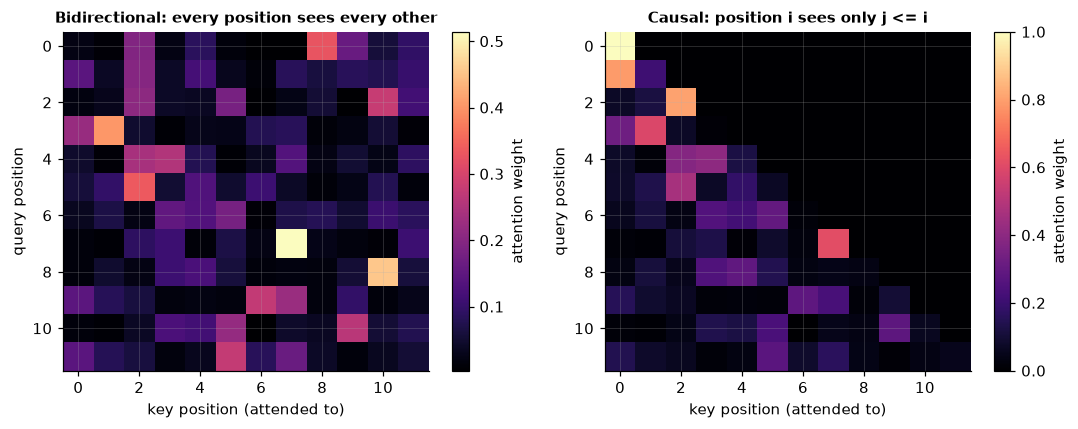

No attention leaks into the future.
Rows still sum to 1: True


In [41]:
import matplotlib.pyplot as plt

def causal_mask(n):
    """Lower-triangular boolean mask: True where attention is allowed."""
    return np.tril(np.ones((n, n), dtype=bool))

SEQ = 12
rng = np.random.default_rng(3)
Q = rng.normal(size=(SEQ, 16))
K = rng.normal(size=(SEQ, 16))
V = rng.normal(size=(SEQ, 16))

_, weights_open = scaled_dot_product_attention(Q, K, V)
_, weights_causal = scaled_dot_product_attention(Q, K, V, mask=causal_mask(SEQ))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, matrix, title in [
    (axes[0], weights_open, "Bidirectional: every position sees every other"),
    (axes[1], weights_causal, "Causal: position i sees only j <= i"),
]:
    image = ax.imshow(matrix, cmap="magma", aspect="auto")
    plt.colorbar(image, ax=ax, label="attention weight")
    ax.set_xlabel("key position (attended to)")
    ax.set_ylabel("query position")
    ax.set_title(title, fontsize=10)
fig.tight_layout()
plt.show()

assert weights_causal[np.triu_indices(SEQ, k=1)].max() == 0.0
print("No attention leaks into the future.")
print(f"Rows still sum to 1: {np.allclose(weights_causal.sum(axis=-1), 1.0)}")

In [42]:
_m = causal_mask(5)
assert _m.dtype == bool and _m.shape == (5, 5)
assert _m[0].sum() == 1 and _m[4].sum() == 5, "row i must allow exactly i+1 keys"
assert not _m[0, 1], "position 0 must not see position 1"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

Row 0 of a causal mask allows exactly one key — itself — so its
attention output is simply its own value vector. That is why the first
token of a language model carries so little information and why models
often prepend a dedicated start token.

Note that the rows still sum to one after masking. That is the payoff
for masking the scores rather than the weights.

### Reflection Question 5.4 ★★★ — Is a large attention weight an explanation?

Attention heatmaps are extremely persuasive and routinely
over-interpreted. Tutorial 05 replaced a trained model's attention
with a uniform average and measured what actually changed.

**Your task.** Give three concrete reasons why a large attention weight does not, on
its own, establish that the attended position caused the prediction.
Then describe one experiment that would produce *evidence* rather than
a picture.

**Expected outcome.** A strong answer distinguishes "the model looked here" from "this
changed the answer", and proposes an ablation with a number attached.

**Reason 1 — the value vector matters as much as the weight.** The
output is $\sum_j a_j v_j$. A weight of 0.6 on a position whose value
vector is near zero contributes nothing, while a weight of 0.01 on a
position with a large value vector can dominate. Task 5.1's own
example makes this concrete: attention weights are not contributions,
and only the product is.

**Reason 2 — residual connections route around attention entirely.**
In a real Transformer block the output is `x + Attention(LN(x))`. The
representation flows down the residual stream whether or not attention
looks at it, so a head can be almost irrelevant to the final
prediction while still producing a beautifully structured heatmap.

**Reason 3 — different attention distributions can give identical
outputs.** Jain and Wallace (2019) constructed adversarial weight
distributions that leave predictions unchanged. If two very different
explanations produce the same answer, neither is *the* explanation.

**An experiment that would produce evidence.** Ablate, and report a
number. Replace the learned attention with (a) a uniform average, (b)
the weights reversed, (c) weights permuted within each row, and (d)
weights taken from a different, randomly initialised model. Measure
the test error under each. If uniform attention costs you little, the
learned pattern was not doing the work the heatmap suggests. Tutorial
05 runs exactly (a) and finds the error rises from about 2,565 MW to
3,745 MW — which licenses the claim that the pattern matters, without
licensing any claim about *which* position caused *which* prediction.

---

## Exercise 06 — Transformers

*Builds on [`06_transformers.ipynb`](06_transformers.ipynb).*

Attention is a layer. A Transformer is an architecture: multi-head attention,
a position-wise feed-forward network, residual connections, layer
normalisation and — because attention has no notion of order — positional
information.

Here the tokens are **hours**, not words. That is the point of this chapter.

In [43]:
import math

import numpy as np
import torch
from torch import nn

from ai_power_course.config import scaled, set_seed
from ai_power_course.data import load_energy_data, time_split
from ai_power_course.metrics import mae
from ai_power_course.models.training import (
    Standardizer, TrainConfig, make_loader, train_model,
)

set_seed()
torch.set_num_threads(min(4, torch.get_num_threads()))

frame = load_energy_data().frame
train_raw, valid_raw, test_raw = time_split(frame)

CONTEXT, HORIZON = 168, 24
STRIDE = scaled(full=6, fast=36)

def windows(part, context=CONTEXT, horizon=HORIZON, stride=1):
    values = part.load_mw.to_numpy(dtype=np.float32)
    starts = np.arange(0, len(values) - context - horizon + 1, stride)
    x = np.stack([values[s : s + context] for s in starts])[:, :, None]
    y = np.stack([values[s + context : s + context + horizon] for s in starts])
    return x.astype(np.float32), y.astype(np.float32)

x_train, y_train = windows(train_raw, stride=STRIDE)
x_valid, y_valid = windows(valid_raw, stride=STRIDE)
x_test, y_test = windows(test_raw, stride=4)

x_scaler = Standardizer().fit(x_train.reshape(-1, 1))
y_scaler = Standardizer().fit(y_train)
xs_train, xs_valid, xs_test = (x_scaler.transform(a) for a in (x_train, x_valid, x_test))
ys_train, ys_valid = (y_scaler.transform(a) for a in (y_train, y_valid))
print(f"{len(xs_train):,} training windows of {CONTEXT} hours -> {HORIZON} hours")

2,889 training windows of 168 hours -> 24 hours


### Coding Task 6.1 ★★ — Multi-head attention

One attention head computes one weighted average, so it can express
one kind of relationship. Splitting `d_model` into `h` heads of width
`d_model / h` lets the layer attend to several patterns at once — the
same hour yesterday, the same hour last week, the recent trend — at no
extra cost, because the head width shrinks as the count grows.

**Your task.** Implement multi-head self-attention in PyTorch: project to Q, K and V,
split into heads, attend, concatenate, project out.

**Requirements**

- `MultiHeadSelfAttention(d_model, n_heads)`, with `d_model` divisible by `n_heads`.
- `forward(x)` takes `(batch, length, d_model)` and returns `(output, weights)` with weights `(batch, n_heads, length, length)`.
- Reuse the maths from task 5.1. Do **not** call `nn.MultiheadAttention` or `F.scaled_dot_product_attention`.
- Assert `d_model % n_heads == 0` in `__init__`.

<details><summary><b>Hints</b></summary>

- One `nn.Linear(d_model, 3 * d_model)` produces Q, K and V together; `.chunk(3, dim=-1)` splits them.
- Splitting heads is a reshape plus a transpose: `(B, L, H, d_head).transpose(1, 2)` -> `(B, H, L, d_head)`.
- Merging them back is the same two operations reversed, and needs `.contiguous()` before the final `.view`.

</details>

**Expected outcome.** Output shape equal to the input shape, weights summing to one along the
last axis, and — for a single head — exact agreement with PyTorch's
fused kernel.

In [44]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        self.d_model, self.n_heads = d_model, n_heads
        self.d_head = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def _split_heads(self, t):
        batch, length, _ = t.shape
        return t.view(batch, length, self.n_heads, self.d_head).transpose(1, 2)

    def _merge_heads(self, t):
        batch, heads, length, d_head = t.shape
        return t.transpose(1, 2).contiguous().view(batch, length, heads * d_head)

    def forward(self, x, mask=None):
        q, k, v = (self._split_heads(p) for p in self.qkv(x).chunk(3, dim=-1))
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.d_head)
        if mask is not None:
            scores = scores.masked_fill(~mask, float("-inf"))
        weights = self.dropout(torch.softmax(scores, dim=-1))
        attended = weights @ v
        return self.out_proj(self._merge_heads(attended)), weights

set_seed()
layer = MultiHeadSelfAttention(d_model=64, n_heads=4)
sample = torch.randn(2, 12, 64)
output, weights = layer(sample)
print(f"input {tuple(sample.shape)} -> output {tuple(output.shape)}")
print(f"weights {tuple(weights.shape)} (batch, heads, query, key)")

input (2, 12, 64) -> output (2, 12, 64)
weights (2, 4, 12, 12) (batch, heads, query, key)


In [45]:
assert output.shape == sample.shape, "attention must preserve the shape"
assert weights.shape == (2, 4, 12, 12)
assert torch.allclose(weights.sum(dim=-1), torch.ones(2, 4, 12), atol=1e-5)

# A single head must reproduce PyTorch's fused kernel exactly.
_single = MultiHeadSelfAttention(d_model=16, n_heads=1)
_x = torch.randn(1, 5, 16)
_q, _k, _v = _single.qkv(_x).chunk(3, dim=-1)
_reference = torch.nn.functional.scaled_dot_product_attention(_q, _k, _v)
_ours, _ = _single(_x)
assert torch.allclose(_single.out_proj(_reference), _ours, atol=1e-5), \
    "single-head attention disagrees with PyTorch"
print("Basic checks passed — and one head matches PyTorch's kernel.")

Basic checks passed — and one head matches PyTorch's kernel.


**Why this works.**

The scaling divisor is `sqrt(d_head)`, not `sqrt(d_model)`. Each head
takes a dot product over `d_head` dimensions, so that is the dimension
whose variance needs correcting — task 5.2 measured exactly this.

`.contiguous()` before `.view` in `_merge_heads` is required: after a
`transpose` the tensor's memory layout no longer matches its shape, and
`view` refuses to reinterpret it. `.reshape` would silently copy
instead, which works but hides the cost.

### Coding Task 6.2 ★★ — Positional encoding, and what happens without it

Self-attention is **permutation equivariant**: shuffle the input
positions and the outputs shuffle identically. For a set of buses that
is a feature. For a time series it is fatal — a load profile read
backwards would produce the same forecast.

*Reuses what you wrote in 6.1 — do those first.*

**Your task.** Implement sinusoidal positional encoding, then demonstrate the
equivariance empirically: show that attention alone is blind to order
and that adding the encoding fixes it.

**Requirements**

- `positional_encoding(length, d_model)` returns `(length, d_model)`.
- Even indices use sine, odd indices cosine.
- Demonstrate the permutation property with an assertion, not prose.
- Plot the encoding as a heatmap.

<details><summary><b>Hints</b></summary>

- $PE_{(p, 2i)} = \sin(p / 10000^{2i/d})$ and $PE_{(p, 2i+1)} = \cos(p / 10000^{2i/d})$.
- Compute the divisor in log space — `torch.exp(arange(0, d, 2) * (-log(10000) / d))` — to avoid overflow at large `d_model`.
- To show equivariance, permute the input rows and compare against the same permutation of the output rows.

</details>

**Expected outcome.** The equivariance assertion passes without positional encoding and fails
with it. The heatmap shows smooth low-frequency stripes in the early
dimensions and fast oscillation in the later ones.

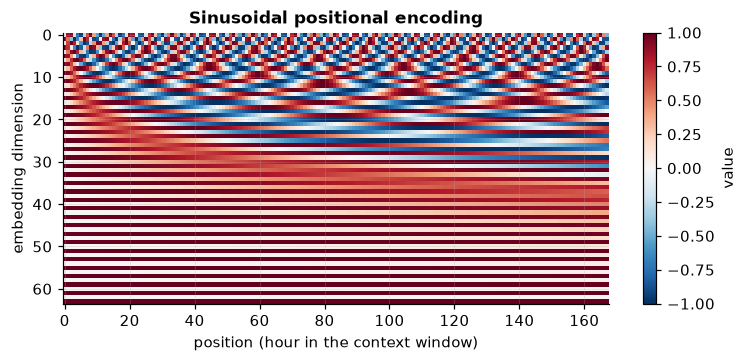

Without positional encoding, order carries no information.
With positional encoding, the same test fails: True

That failure is the feature. Order now changes the answer.


In [46]:
import matplotlib.pyplot as plt

def positional_encoding(length, d_model):
    """Sinusoidal positional encoding of shape (length, d_model)."""
    position = torch.arange(length, dtype=torch.float32).unsqueeze(1)
    divisor = torch.exp(
        torch.arange(0, d_model, 2, dtype=torch.float32)
        * (-math.log(10000.0) / d_model)
    )
    encoding = torch.zeros(length, d_model)
    encoding[:, 0::2] = torch.sin(position * divisor)
    encoding[:, 1::2] = torch.cos(position * divisor)
    return encoding

pe = positional_encoding(CONTEXT, 64)
fig, ax = plt.subplots(figsize=(8, 3.2))
image = ax.imshow(pe.T, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(image, ax=ax, label="value")
ax.set_xlabel("position (hour in the context window)")
ax.set_ylabel("embedding dimension")
ax.set_title("Sinusoidal positional encoding")
plt.show()

set_seed()
layer = MultiHeadSelfAttention(d_model=64, n_heads=4)
x = torch.randn(1, 10, 64)
perm = torch.randperm(10)

out_plain, _ = layer(x)
out_permuted, _ = layer(x[:, perm])
assert torch.allclose(out_permuted, out_plain[:, perm], atol=1e-5), \
    "attention should be permutation equivariant"
print("Without positional encoding, order carries no information.")

out_pe, _ = layer(x + pe[:10])
out_pe_permuted, _ = layer(x[:, perm] + pe[:10])
print(f"With positional encoding, the same test fails: "
      f"{not torch.allclose(out_pe_permuted, out_pe[:, perm], atol=1e-5)}")
print("\nThat failure is the feature. Order now changes the answer.")

In [47]:
_pe = positional_encoding(50, 32)
assert _pe.shape == (50, 32)
assert _pe.abs().max() <= 1.0 + 1e-6, "sin and cos are bounded by 1"
assert not torch.allclose(_pe[0], _pe[1]), "positions must be distinguishable"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

Computing the divisor with `torch.exp(... * -log(10000) / d)` rather
than `10000 ** (-2i/d)` is numerically deliberate: the direct power
underflows to zero for large `d_model`, which collapses the
high-frequency dimensions to a constant.

The equivariance demonstration is the load-bearing part of this task.
Chapter 10 needs exactly the *opposite* property — a grid encoder must
be permutation equivariant, because bus numbering is arbitrary — and so
it deliberately has no positional encoding. Same layer, opposite
requirement, decided by the domain.

### Coding Task 6.3 ★★ — Assemble a pre-norm Transformer block

The block is `x + Attention(LN(x))` followed by `x + MLP(LN(x))`. Two
choices deserve naming:

- the **residual** makes the block an edit to the representation
  rather than a replacement, which is what lets dozens stack;
- **pre-norm** (normalise *before* the sublayer) trains without a
  learning-rate warm-up, unlike the post-norm arrangement in the 2017
  paper.

*Reuses what you wrote in 6.1 — do those first.*

**Your task.** Implement the block, then measure the difference the residual makes by
comparing gradient magnitudes at the first layer of a deep stack with
and without it.

**Requirements**

- `TransformerBlock(d_model, n_heads, d_ff=None, dropout=0.1)`, with `d_ff` defaulting to `4 * d_model`.
- Pre-norm ordering.
- The feed-forward network uses GELU.
- Compare gradient norms at layer 0 of an 8-block stack, residual on versus off.

<details><summary><b>Hints</b></summary>

- The feed-forward network is position-wise: it maps `d_model` -> `d_ff` -> `d_model` and sees each time step independently.
- To disable the residual, return the sublayer output directly instead of adding `x`.

</details>

**Expected outcome.** Without residuals the first block's gradient should be orders of
magnitude smaller. That is the vanishing-gradient problem of chapter 03
reappearing in depth rather than in time.

In [48]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff=None, dropout=0.1, residual=True):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.residual = residual
        self.norm1 = nn.LayerNorm(d_model)
        self.attention = MultiHeadSelfAttention(d_model, n_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attended, weights = self.attention(self.norm1(x), mask=mask)
        x = x + self.dropout(attended) if self.residual else self.dropout(attended)
        fed = self.dropout(self.feed_forward(self.norm2(x)))
        x = x + fed if self.residual else fed
        return x, weights

def first_layer_gradient(residual, depth=8, d_model=64):
    set_seed()
    blocks = nn.ModuleList(
        TransformerBlock(d_model, 4, dropout=0.0, residual=residual)
        for _ in range(depth)
    )
    h = torch.randn(4, 16, d_model, requires_grad=True)
    x = h
    for block in blocks:
        x, _ = block(x)
    x.pow(2).mean().backward()
    return float(
        sum(p.grad.norm() for p in blocks[0].parameters() if p.grad is not None)
    )

with_residual = first_layer_gradient(residual=True)
without_residual = first_layer_gradient(residual=False)
print(f"gradient norm at block 0, with residuals   : {with_residual:.3e}")
print(f"gradient norm at block 0, without residuals: {without_residual:.3e}")
print(f"ratio: {with_residual / max(without_residual, 1e-30):.1f}x")
print("\nThe residual gives the gradient a path to the first block that skips")
print("every intervening transformation. Depth stopped being a barrier in 2015")
print("(ResNet) for exactly this reason, and Transformers inherited the trick.")

gradient norm at block 0, with residuals   : 2.209e+00
gradient norm at block 0, without residuals: 3.213e-01
ratio: 6.9x

The residual gives the gradient a path to the first block that skips
every intervening transformation. Depth stopped being a barrier in 2015
(ResNet) for exactly this reason, and Transformers inherited the trick.


In [49]:
_b = TransformerBlock(32, 4, dropout=0.0)
_x = torch.randn(2, 6, 32)
_y, _w = _b(_x)
assert _y.shape == _x.shape, "a block must preserve its input shape"
assert with_residual > without_residual, \
    "residual connections should preserve gradient magnitude"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

`d_ff = 4 * d_model` is the near-universal convention, from the 2017
paper through GPT-3 to Llama. Most of a Transformer's parameters live in
these feed-forward layers, not in attention — a fact that surprises
people who think of the architecture as "the attention model".

Note that this block preserves its input shape exactly. That is what
makes `nn.Sequential`-style stacking possible and why scaling a
Transformer is a matter of changing three numbers.

### Analysis Task 6.4 ★★★ — Transformer versus LSTM on identical windows

"Transformers beat RNNs" is a claim about *scale and parallelism*.
It is repeated far more often than it is measured, and the measurement
usually comes with conditions attached — sequence length, hardware,
parameter budget — that are left out when the claim is repeated.

Measure it here, and read the whole table rather than one column.

**Your task.** Train a small Transformer forecaster on the same windows chapter 03
used, compare it against an LSTM under a matched optimisation budget,
and report both accuracy and wall-clock time.

**Requirements**

- Both models see identical data, identical scaling and the same number of epochs.
- Report test MAE in MW, parameter count and training time for each.
- State a conclusion the numbers support — and say explicitly whether the comparison was fair.

<details><summary><b>Hints</b></summary>

- Keep both small: `d_model=64`, 2 layers, 4 heads is plenty here.
- `train_model(model, train_loader, valid_loader, loss_fn, config)` returns a `History` with `best_val_loss` and `seconds`.

</details>

**Expected outcome.** One of them wins on MAE. Before calling that an architecture result,
check whether the two models were the same size and cost the same to
train — and see whether the wall-clock column matches what you have
heard about Transformers and RNNs.

In [50]:
import pandas as pd

from ai_power_course.models.forecasters import LSTMForecaster, TransformerForecaster

EPOCHS = scaled(full=12, fast=2)
train_loader = make_loader(xs_train, ys_train, batch_size=64, shuffle=True)
valid_loader = make_loader(xs_valid, ys_valid, batch_size=256)

def fit_and_score(model, name):
    set_seed()
    history = train_model(
        model, train_loader, valid_loader, loss_fn=nn.MSELoss(),
        config=TrainConfig(epochs=EPOCHS, learning_rate=1e-3,
                           patience=4, verbose=False),
    )
    model.eval()
    with torch.no_grad():
        scaled_out = model(torch.tensor(xs_test, dtype=torch.float32)).numpy()
    prediction = y_scaler.inverse_transform(scaled_out)
    return {
        "model": name,
        "parameters": sum(p.numel() for p in model.parameters()),
        "MAE [MW]": mae(y_test.ravel(), prediction.ravel()),
        "train [s]": history.seconds,
    }

rows = [
    fit_and_score(
        LSTMForecaster(n_channels=1, hidden_size=64, horizon=HORIZON), "LSTM"
    ),
    fit_and_score(
        TransformerForecaster(context=CONTEXT, horizon=HORIZON, n_channels=1,
                              d_model=64, n_heads=4, n_layers=2),
        "Transformer",
    ),
]
comparison = pd.DataFrame(rows).set_index("model")
display(comparison.round(1))

winner = comparison["MAE [MW]"].idxmin()
loser = comparison["MAE [MW]"].idxmax()
gap = comparison.loc[loser, "MAE [MW]"] / comparison.loc[winner, "MAE [MW]"] - 1
size = comparison.loc[winner, "parameters"] / comparison.loc[loser, "parameters"]
cost = comparison.loc[winner, "train [s]"] / comparison.loc[loser, "train [s]"]
print(f"\n{winner} has the lower MAE, by {gap:.1%}.")
print(f"It also has {size:.1f}x the parameters and took {cost:.1f}x as long.")

print("\nSo the comparison is NOT matched, and the accuracy gap cannot be")
print("attributed to the architecture on its own. To make the claim properly")
print("you would equalise the parameter count and the training budget, and")
print("repeat over several seeds. That is the experiment; this is a hint.")

print("\nThe wall-clock column is the more interesting result, because it")
print("contradicts the folklore directly. 'Transformers are faster than RNNs'")
print("is about parallelism over the sequence during training — real on a GPU,")
print("with long sequences and large batches. On four CPU threads with a")
print("168-step window, the LSTM's sequential loop is cheap and attention's")
print("O(n^2) is not. The claim is conditional, and the conditions are exactly")
print("what gets dropped when it is repeated.")

print("\nThe durable advantages — constant path length between positions, and")
print("continued improvement as data and parameters grow — are not visible on")
print("a few thousand windows of one series. That is why chapters 09 and 10")
print("change the data, not the model.")

,parameters,MAE [MW],train [s]
model,,,
LSTM,18712,3089.2,10.5
Transformer,101784,2482.7,128.9



Transformer has the lower MAE, by 24.4%.
It also has 5.4x the parameters and took 12.3x as long.

So the comparison is NOT matched, and the accuracy gap cannot be
attributed to the architecture on its own. To make the claim properly
you would equalise the parameter count and the training budget, and
repeat over several seeds. That is the experiment; this is a hint.

The wall-clock column is the more interesting result, because it
contradicts the folklore directly. 'Transformers are faster than RNNs'
is about parallelism over the sequence during training — real on a GPU,
with long sequences and large batches. On four CPU threads with a
168-step window, the LSTM's sequential loop is cheap and attention's
O(n^2) is not. The claim is conditional, and the conditions are exactly
what gets dropped when it is repeated.

The durable advantages — constant path length between positions, and
continued improvement as data and parameters grow — are not visible on
a few thousand windows of one serie

In [51]:
assert set(comparison.index) == {"LSTM", "Transformer"}
assert (comparison["MAE [MW]"] > 0).all()
assert comparison["MAE [MW]"].max() < 20000, "check the inverse transform"
assert (comparison["parameters"] > 0).all(), "report the parameter counts too"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

The *optimisation* budget is matched — identical epochs, learning rate,
loaders, and a fresh seed before each fit — but the *capacity* budget is
not, and the printed output says so rather than quietly claiming an
architecture win. Noticing which knobs a comparison holds fixed, and
which it does not, is most of what reading a benchmark table consists of.

`set_seed()` inside `fit_and_score` rather than once at the top is
deliberate — otherwise the second model inherits whatever random state
the first one left behind, and the comparison is not reproducible in
isolation.

---

## Exercise 07 — Language Models

*Builds on [`07_language_models.ipynb`](07_language_models.ipynb).*

Same architecture as chapter 06, one change: a causal mask and a
discrete vocabulary. The training signal — predict the next token — needs no
labels at all, which is what makes the internet a training set.

The corpus here is a synthetic grid-operations handbook. It is far too small
to produce a good model, and that is instructive: you will watch a model
memorise rather than generalise, and see exactly what scale buys.

In [52]:
import numpy as np
import torch
from torch import nn

from ai_power_course.config import scaled, set_seed
from ai_power_course.corpus import HANDBOOK, generate_corpus
from ai_power_course.models.tinygpt import CharTokenizer, TinyGPT, TinyGPTConfig, generate

set_seed()
torch.set_num_threads(min(4, torch.get_num_threads()))

corpus = generate_corpus(n_logs=500, n_reports=140, n_assets=140)
print(f"corpus: {len(corpus):,} characters, {len(corpus.split()):,} words")
print(f"\n{corpus[:320]}...")

corpus: 134,831 characters, 22,243 words

POWER SYSTEMS HANDBOOK

PER-UNIT SYSTEM
The per-unit system expresses electrical quantities as fractions of a chosen
base. A base apparent power S_base and a base voltage V_base are selected for
each voltage level; base current and base impedance follow as I_base = S_base
/ (sqrt(3) V_base) and Z_base = V_base^2 / S_ba...


### Coding Task 7.1 ★★ — Tokenize, and build next-token batches

A language model sees integers. The tokenizer decides what an integer
means, and that choice determines the sequence length, the vocabulary
size and whether unseen words are even representable.

Character level keeps the vocabulary near 70 symbols so a tiny model
can learn something, and makes the step completely transparent.

**Your task.** Build a character tokenizer, encode the corpus, and write the batching
function that produces `(input, target)` pairs for next-token
prediction.

**Requirements**

- `encode` / `decode` must round-trip exactly.
- `get_batch(data, batch_size, context)` returns two tensors of shape `(batch_size, context)`.
- The target is the input shifted by exactly one position.
- Hold out the last 10% of the corpus for validation.

<details><summary><b>Hints</b></summary>

- For a start index `i`, the input is `data[i : i+context]` and the target is `data[i+1 : i+1+context]`.
- The largest legal start index is `len(data) - context - 1`.

</details>

**Expected outcome.** A vocabulary of roughly 70 characters, an exact round-trip, and a batch
whose target is visibly the input shifted left by one.

In [53]:
tokenizer = CharTokenizer(corpus)
print(f"vocabulary: {tokenizer.vocab_size} characters")
print("".join(tokenizer.chars).replace("\n", "\\n"))

data = torch.tensor(tokenizer.encode(corpus), dtype=torch.long)
split_at = int(0.9 * len(data))
train_data, valid_data = data[:split_at], data[split_at:]
print(f"\ntrain {len(train_data):,} tokens | validation {len(valid_data):,} tokens")

CONTEXT = 128

def get_batch(data, batch_size=32, context=CONTEXT, generator=None):
    """Random windows and their one-step-shifted targets."""
    starts = torch.randint(
        0, len(data) - context - 1, (batch_size,), generator=generator
    )
    x = torch.stack([data[s : s + context] for s in starts])
    y = torch.stack([data[s + 1 : s + 1 + context] for s in starts])
    return x, y

gen = torch.Generator().manual_seed(0)
xb, yb = get_batch(train_data, batch_size=4, generator=gen)
print(f"\ninput {tuple(xb.shape)}   target {tuple(yb.shape)}")
print(f"\ninput  : {tokenizer.decode(xb[0][:60])!r}")
print(f"target : {tokenizer.decode(yb[0][:60])!r}")

vocabulary: 76 characters
\n ()*,-./0123456789:;=ABCDEFGHIKLMNOPQRSTUVWXYZ^_abcdefghijklmnopqrstuvwxyz|

train 121,347 tokens | validation 13,484 tokens

input (4, 128)   target (4, 128)

input  : ' 1996 | rated 183.6 MVA | condition index 0.48 | next inspec'
target : '1996 | rated 183.6 MVA | condition index 0.48 | next inspect'


In [54]:
_text = "Bus voltage at Nordfeld fell to 0.94 per unit."
assert tokenizer.decode(tokenizer.encode(_text)) == _text, "round-trip failed"
assert xb.shape == yb.shape == (4, CONTEXT)
assert torch.equal(xb[0, 1:], yb[0, :-1]), "the target must be the input shifted by 1"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

The shift by one is the entire supervision signal, and it produces
`context` training examples per window rather than one: position 0
predicts position 1, position 1 predicts position 2, and so on, all in
a single forward pass. That is teacher forcing, and it is why language
models are so data-efficient per unit of compute.

Note the corpus split is chronological here only by accident — for text
the concern is not temporal leakage but *duplication*. Real corpora are
deduplicated before splitting, because a passage appearing in both
halves turns validation perplexity into a memorisation score.

### Coding Task 7.2 ★★ — The loss, and what perplexity means

The loss is one line: cross-entropy between the logits at each
position and the token that actually followed.

Perplexity is $e^{\text{loss}}$, and it has a reading: *the effective
number of equally likely choices the model is deciding between*. A
uniform model over a 70-character vocabulary has perplexity 70.

*Reuses what you wrote in 7.1 — do those first.*

**Your task.** Instantiate a TinyGPT, compute its loss before any training, and check
that the perplexity matches the vocabulary size.

**Requirements**

- Predict the untrained loss from the vocabulary size **before** running the model.
- Verify the prediction to within 10%.
- Report the parameter count.

<details><summary><b>Hints</b></summary>

- An untrained model is roughly uniform over the vocabulary, so the cross-entropy should be near `log(vocab_size)`.
- `TinyGPT.forward(idx, targets)` returns `(logits, loss)`.

</details>

**Expected outcome.** A loss near `log(70) ≈ 4.25` and a perplexity near 70. If it is far off,
the initialisation or the target alignment is wrong.

In [55]:
import math

predicted_loss = math.log(tokenizer.vocab_size)
predicted_perplexity = float(tokenizer.vocab_size)
print(f"predicted untrained loss: {predicted_loss:.3f} "
      f"(perplexity {predicted_perplexity:.1f})")

set_seed()
config = TinyGPTConfig(
    vocab_size=tokenizer.vocab_size, context=CONTEXT,
    d_model=128, n_heads=4, n_layers=4, dropout=0.1,
)
model = TinyGPT(config)
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

xb, yb = get_batch(train_data, batch_size=16, generator=gen)
with torch.no_grad():
    logits, loss = model(xb, yb)
measured_perplexity = math.exp(float(loss))
print(f"measured untrained loss : {float(loss):.3f} "
      f"(perplexity {measured_perplexity:.1f})")
print(f"\nlogits {tuple(logits.shape)} — one distribution over the vocabulary")
print("at every position, which is why one sequence gives `context` training")
print("signals rather than one.")

predicted untrained loss: 4.331 (perplexity 76.0)
parameters: 819,456
measured untrained loss : 4.333 (perplexity 76.2)

logits (16, 128, 76) — one distribution over the vocabulary
at every position, which is why one sequence gives `context` training
signals rather than one.


In [56]:
assert abs(float(loss) - predicted_loss) < 0.1 * predicted_loss, \
    "an untrained model should be close to uniform"
assert logits.shape == (16, CONTEXT, tokenizer.vocab_size)
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

Predicting the untrained loss before measuring it is a habit worth
keeping. It catches initialisation bugs immediately: a loss far above
`log(V)` means the output weights are too large, and a loss far below it
at step zero means the targets are leaking into the input.

Perplexity is a rescaling of the loss, nothing more. It is worth
reporting because it is interpretable, and worth distrusting across
papers because it depends entirely on the tokenizer — a character-level
perplexity and a subword perplexity are not comparable numbers.

### Coding Task 7.3 ★★ — Train the model and watch it memorise

A few hundred thousand characters is not a corpus. The model will fit
it and then start reciting it, and seeing that happen is more useful
than any explanation of why scale matters.

*Reuses what you wrote in 7.2 — do those first.*

**Your task.** Write the training loop, track the training and validation loss, and
generate a sample from the model before and after.

**Requirements**

- Estimate the validation loss periodically under `torch.no_grad()`.
- Clip gradients to a maximum norm of 1.0.
- Generate a sample from an untrained and a trained model, and show both.

<details><summary><b>Hints</b></summary>

- `torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)` goes between `backward()` and `step()`.
- `generate(model, idx, max_new_tokens=..., temperature=...)` expects `idx` of shape `(batch, length)`.

</details>

**Expected outcome.** The training loss should fall well below the validation loss — that gap
*is* the memorisation. The generated text should acquire the shape of
the corpus (substation names, per-unit voltages, MW figures) without
necessarily meaning anything.

In [57]:
prompt = torch.tensor([tokenizer.encode("Bus voltage at ")], dtype=torch.long)
before = generate(model, prompt, max_new_tokens=120, temperature=0.8,
                  generator=torch.Generator().manual_seed(0))
print("BEFORE TRAINING")
print(tokenizer.decode(before[0]))

STEPS = scaled(full=1200, fast=60)
EVAL_EVERY = max(1, STEPS // 8)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.1)
gen = torch.Generator().manual_seed(1)

@torch.no_grad()
def estimate_loss(data, batches=8):
    model.eval()
    losses = []
    for _ in range(batches):
        x, y = get_batch(data, batch_size=16, generator=gen)
        losses.append(float(model(x, y)[1]))
    model.train()
    return float(np.mean(losses))

loss_log = []
for step in range(1, STEPS + 1):
    x, y = get_batch(train_data, batch_size=16, generator=gen)
    _logits, loss = model(x, y)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    if step % EVAL_EVERY == 0 or step == 1:
        row = {"step": step, "train": estimate_loss(train_data),
               "validation": estimate_loss(valid_data)}
        loss_log.append(row)
        print(f"step {step:5d}  train {row['train']:.3f}  "
              f"validation {row['validation']:.3f}")

after = generate(model, prompt, max_new_tokens=200, temperature=0.8,
                 generator=torch.Generator().manual_seed(0))
print("\nAFTER TRAINING")
print(tokenizer.decode(after[0]))

gap = loss_log[-1]["validation"] - loss_log[-1]["train"]
print(f"\nvalidation minus train: {gap:+.3f} nats — that gap is memorisation,")
print("and it is what a corpus of this size buys you. The fix is not a better")
print("optimiser; it is three more orders of magnitude of text.")

BEFORE TRAINING
Bus voltage at jS7BxhFiL6bwAX36dW0wo,::S);2b1_16_m(XTLT_HhBCU88gE-jqlhX6dQ(khy,FA:XCRI)R0Ydf.aBjaBfP
P27:_GC/eKzAARECCT9V6h***Ck*MVIpva


step     1  train 4.046  validation 4.048


step   150  train 2.220  validation 2.155


step   300  train 1.785  validation 1.624


step   450  train 1.358  validation 1.144


...

step   750  train 0.914  validation 0.619


step   900  train 0.928  validation 0.510


step  1050  train 0.814  validation 0.458


step  1200  train 0.725  validation 0.391



AFTER TRAINING
Bus voltage at the ing bl weathe two the des aisem betillow thegen tre t oneec, and chetind tache ant ile powered
easend is, soung appaticitits ang surat dsered pe, hind be dvoltag sutimical ges sove ad remititionit

validation minus train: -0.335 nats — that gap is memorisation,
and it is what a corpus of this size buys you. The fix is not a better
optimiser; it is three more orders of magnitude of text.


In [58]:
assert loss_log[-1]["train"] < loss_log[0]["train"], "the training loss did not fall"
assert loss_log[-1]["train"] < math.log(tokenizer.vocab_size), \
    "the model should beat a uniform distribution"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

Gradient clipping earns its place in language-model training
specifically: a rare token combination can produce an enormous gradient
that moves the weights far enough to destroy several thousand steps of
progress in one update. Clipping the *norm* rather than the individual
values preserves the direction and only limits the step length.

`weight_decay=0.1` is much higher than the usual `1e-2` and is the
standard GPT-family setting. With a small corpus it slows memorisation
slightly; it does not prevent it.

### Coding Task 7.4 ★★ — Temperature and top-k sampling

The model outputs a distribution. Turning it into text is a separate
decision, and it has as much effect on what you read as the weights do.

Temperature rescales the logits before the softmax: below 1 sharpens,
above 1 flattens, 0 is greedy. Top-k truncates to the `k` most likely
tokens.

*Reuses what you wrote in 7.3 — do those first.*

**Your task.** Generate from the trained model at several temperatures and with top-k
truncation, then quantify the diversity of each setting rather than
judging by eye.

**Requirements**

- At least four settings, including greedy (`temperature=0`).
- Report a numeric diversity measure per setting, not only the text.
- Use the same seed for every setting so the comparison is fair.

<details><summary><b>Hints</b></summary>

- The fraction of unique 5-character sequences is a reasonable diversity proxy.
- `generate(..., top_k=20)` truncates the distribution to the 20 most likely next characters at each step.

</details>

**Expected outcome.** Greedy decoding should loop or repeat. High temperature should be
diverse and less coherent. The interesting question is where the
trade-off sits, not which end is 'right'.

In [59]:
import pandas as pd

def diversity(text, n=5):
    """Fraction of character n-grams that are unique."""
    grams = [text[i : i + n] for i in range(len(text) - n)]
    return len(set(grams)) / max(len(grams), 1)

settings = [
    {"temperature": 0.0, "top_k": None, "label": "greedy (T=0)"},
    {"temperature": 0.5, "top_k": None, "label": "T=0.5"},
    {"temperature": 1.0, "top_k": None, "label": "T=1.0"},
    {"temperature": 1.5, "top_k": None, "label": "T=1.5"},
    {"temperature": 1.0, "top_k": 10, "label": "T=1.0, top-k=10"},
]

rows = []
for setting in settings:
    sample = generate(
        model, prompt, max_new_tokens=220,
        temperature=setting["temperature"], top_k=setting["top_k"],
        generator=torch.Generator().manual_seed(0),
    )
    text = tokenizer.decode(sample[0])
    rows.append({"setting": setting["label"], "diversity": diversity(text)})
    print(f"--- {setting['label']} ---")
    print(text[:200].replace("\n", " | "))
    print()

table = pd.DataFrame(rows).set_index("setting")
display(table.round(3))
print("\nNone of these settings changed a single weight. Decoding is a knob on")
print("the same model, and a paper that reports 'the model produces X' without")
print("stating its decoding parameters has not told you enough to reproduce it.")

--- greedy (T=0) ---
Bus voltage at is ange the ang ange and and and and and and and aution ale and and anction an indesthe anction anction angese and and and and autiong and and and aution  and and aution  ind austion al



--- T=0.5 ---
Bus voltage at the ing ble ane d the ind ang ange ang isuron ange the at ofeee, and aind and and and and anche a isese ancon sinn arecation it maness | aund sere ion, thallle atiche is tint a ange sower



--- T=1.0 ---
Bus voltage at the she bl wenerounw thed des aisemont isuron angy-tolh t o fhe, aerke pr Y fores hant ily powe this seans as siker sppat sifres aowss | aur dsercancy, hiallle dvoagicis tifich anges ssor



--- T=1.5 ---
Bus voltage at jeag | hes iblegeroWiwitrkST 2busi62moX kV_Howermple-tr to dQ(fhe, Aho pint Y fore anf thely podemalie Cele is, siky Vrpvatis fres,. | 2/ SIur dsercafor, haker-W; voltages tifyplY 2Nezer;e 



--- T=1.0, top-k=10 ---
Bus voltage at the she bl weneroun, the the maisemont isuron angy tole t one cthe o cint as tarkan. |  | PORTIT |  | TIL ARETLTD RBANCEL | RANocation    location     : Steinberuck 30 kWejeitt 220 kV |   equipment



,diversity
setting,
greedy (T=0),0.452
T=0.5,0.848
T=1.0,1.000
T=1.5,0.983
"T=1.0, top-k=10",0.909



None of these settings changed a single weight. Decoding is a knob on
the same model, and a paper that reports 'the model produces X' without
stating its decoding parameters has not told you enough to reproduce it.


In [60]:
assert len(rows) == len(settings)
assert table.loc["greedy (T=0)", "diversity"] <= table.loc["T=1.5", "diversity"], \
    "greedy decoding should not be more diverse than T=1.5"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

Greedy decoding is deterministic but not optimal: taking the most
likely token at every step does not produce the most likely
*sequence*, and it falls into loops because a repeated phrase is
locally high-probability at every position.

Top-k and top-p both exist to cut the tail. The tail holds thousands of
individually unlikely tokens whose probability mass collectively is
large, so unrestricted sampling wanders into it regularly. Top-p adapts
to the model's confidence; top-k does not.

### Reflection Question 7.5 ★★★ — Is next-token prediction 'just autocomplete'?

The dismissal is common and it is not stupid: the training objective
genuinely is nothing more than predicting the next token. The question
is what that objective forces a model to represent.

**Your task.** Make the strongest case you can for *both* readings. Then take a
position: for a grid operations assistant, which reading should
determine how much you trust the system, and what would you measure to
decide?

**Expected outcome.** A good answer takes the deflationary reading seriously instead of
dismissing it, and lands on something measurable rather than on a
definition.

**The case for 'just autocomplete'.** The objective is exactly
$\max \sum_t \log p(x_t \mid x_{<t})$, and nothing in it references
truth, intent or the world. The model has no mechanism for checking a
claim against reality; it has a mechanism for continuing text
plausibly. That is why it produces a fluent, correctly formatted,
entirely fabricated protection setting with the same confidence as a
correct one — the failure is not a bug in an otherwise truth-seeking
system, it is the system working as specified. Chapter 07's own model
makes this vivid: it learned the *shape* of an operations log without
learning a single fact about the grid.

**The case against.** "Just" is doing a lot of work. Predicting the
next token well *at scale* requires representing whatever the text
depends on. To continue "the fault current at the 110 kV busbar was
calculated as" accurately, something has to encode the relationship
between short-circuit power and impedance. The objective is simple; the
function class that minimises it is not, and we have empirical evidence
— in-context learning, chain-of-thought, transfer to unseen tasks —
that large models acquire structure nobody put there deliberately. The
same argument applies to evolution: a simple objective, arbitrarily
complex solutions.

**My position, and what I would measure.** For a grid operations
assistant the dispute is beside the point, because both readings agree
on the operational fact: *fluency is uncorrelated with correctness, and
the model gives you no signal about which you are getting*. Whether the
model "understands" is unfalsifiable; whether it is reliable is not.

So I would measure three things, none of which requires resolving the
philosophy. First, **accuracy on questions with verifiable answers**
drawn from our own documentation — and separately for questions whose
answers appear in the pretraining corpus versus questions about our
internal standards, because the gap between those two is the whole
risk. Second, **calibration**: does stated or token-level confidence
predict correctness? An uncalibrated model is unusable in an operational
loop regardless of its average accuracy. Third, **behaviour under
adversarial premises** — ask about a piece of equipment that does not
exist and see whether it invents a rating.

A system that scores well on all three is safe to deploy behind a human
reviewer whatever we call its inner life. A system that fails the third
is not, however impressive its prose.

---

## Exercise 08 — Pretrained LLMs and Adaptation

*Builds on [`08_pretrained_llms_and_adaptation.ipynb`](08_pretrained_llms_and_adaptation.ipynb).*

You stop training models and start adapting one. The spectrum runs from
zero-cost (embeddings, prompting) through cheap (linear probe, LoRA) to
expensive (full fine-tuning), and the engineering skill is choosing the
cheapest point that solves the problem.

The task: classify grid operations log entries into `routine`, `overload`,
`voltage_violation` and `outage`.

**Requires a network connection** the first time, to download a 23 M-parameter
encoder. Under `AI_POWER_COURSE_OFFLINE=1` these cells report and skip.

In [61]:
import warnings

import numpy as np
import torch
from sklearn.model_selection import train_test_split

from ai_power_course.config import offline_mode, scaled, set_seed
from ai_power_course.corpus import EVENT_CLASSES, generate_event_dataset
from ai_power_course.metrics import classification_metrics

warnings.filterwarnings("ignore")
set_seed()
torch.set_num_threads(min(4, torch.get_num_threads()))

ENCODER_NAME = "sentence-transformers/all-MiniLM-L6-v2"   # 22.7 M params, Apache-2.0

texts, labels = generate_event_dataset(n_per_class=scaled(full=220, fast=60))
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.3, random_state=0, stratify=labels
)
print(f"{len(texts)} log entries across {len(EVENT_CLASSES)} classes: "
      f"{', '.join(EVENT_CLASSES)}")
print(f"train {len(train_texts)} | test {len(test_texts)}")

tokenizer = encoder = None
if offline_mode():
    print("\nAI_POWER_COURSE_OFFLINE is set — the download-dependent tasks will skip.")
else:
    import transformers
    from transformers import AutoModel, AutoTokenizer

    transformers.logging.set_verbosity_error()
    tokenizer = AutoTokenizer.from_pretrained(ENCODER_NAME)
    encoder = AutoModel.from_pretrained(ENCODER_NAME).eval()
    n_params = sum(p.numel() for p in encoder.parameters())
    print(f"\n{ENCODER_NAME}: {n_params:,} parameters, "
          f"{encoder.config.num_hidden_layers} layers, "
          f"hidden {encoder.config.hidden_size}")
    print("That is the chapter-06 architecture with weights someone else paid for.")

880 log entries across 4 classes: routine, overload, voltage_violation, outage
train 616 | test 264


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


sentence-transformers/all-MiniLM-L6-v2: 22,713,216 parameters, 6 layers, hidden 384
That is the chapter-06 architecture with weights someone else paid for.


### Coding Task 8.1 ★★ — Mean pooling that respects the attention mask

An encoder returns one vector per token. To get one vector per
sentence you average them — but a batch is padded to its longest
member, and averaging the padding in dilutes every short sentence by a
different amount.

This is the single most common bug in home-made embedding code, and it
is invisible: the shapes are right and the numbers look reasonable.

**Your task.** Implement mask-aware mean pooling with L2 normalisation, then
demonstrate the bug by comparing against the naive version.

**Requirements**

- `embed(texts)` returns `(n_texts, 384)`, L2-normalised.
- Run under `torch.no_grad()` — nothing is being trained.
- Show numerically that naive pooling changes a sentence's embedding depending on what it was batched with.

<details><summary><b>Hints</b></summary>

- `tokenizer(texts, padding=True, truncation=True, return_tensors='pt')` gives `input_ids` and `attention_mask`.
- Expand the mask to the hidden width, multiply, sum over the token axis, and divide by the mask's sum — clamped away from zero.

</details>

**Expected outcome.** Correct pooling gives an identical embedding for a sentence regardless
of its batch. Naive pooling does not, and the difference should be large
enough to matter.

In [62]:
if encoder is None:
    print("Skipped: offline mode.")
else:
    @torch.no_grad()
    def embed(texts, batch_size=64, masked=True):
        """Mean-pooled, L2-normalised sentence embeddings."""
        out = []
        for start in range(0, len(texts), batch_size):
            chunk = list(texts[start : start + batch_size])
            encoded = tokenizer(chunk, padding=True, truncation=True,
                                max_length=128, return_tensors="pt")
            hidden = encoder(**encoded).last_hidden_state
            if masked:
                mask = encoded["attention_mask"].unsqueeze(-1).to(hidden.dtype)
                pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
            else:
                pooled = hidden.mean(dim=1)   # the bug, for comparison
            out.append(torch.nn.functional.normalize(pooled, p=2, dim=1))
        return torch.cat(out).numpy()

    probe = "Scheduled inspection completed on the overhead line at Nordfeld."
    # A real long SENTENCE, not "A" * 400. A 400-character run of
    # one letter is a single unknown word to MiniLM's WordPiece
    # vocabulary -- 3 tokens with the specials, SHORTER than the
    # 13-token probe. The batch therefore had no padding at all,
    # and the demonstration of a padding bug showed nothing but
    # float noise (1.3e-07) while the text narrated a large effect.
    # This mate tokenizes to 131 tokens, so the probe really is
    # padded with ~118 pad positions.
    filler = (
        "The maintenance crew reported that the transformer at the "
        "substation had been inspected, tested, cleaned, and returned "
        "to service after the scheduled outage, and that no further "
        "action was required before the next inspection interval. "
    ) * 3
    padded_batch = [probe, filler]           # forces heavy padding
    alone = embed([probe])[0]
    batched_ok = embed(padded_batch, masked=True)[0]
    batched_bad = embed(padded_batch, masked=False)[0]

    alone_bad = embed([probe], masked=False)[0]
    print(f"mask-aware, alone vs batched : "
          f"max difference {np.abs(alone - batched_ok).max():.2e}")
    print(f"naive,      alone vs batched : "
          f"max difference {np.abs(alone_bad - batched_bad).max():.2e}")

    X_train = embed(train_texts)
    X_test = embed(test_texts)
    print(f"\nembeddings: {X_train.shape}")
    print("\nThe naive version makes a sentence's representation depend on its")
    print("neighbours in the batch. Nothing errors, the accuracy just quietly")
    print("drops and never recovers.")

mask-aware, alone vs batched : max difference 1.23e-07
naive,      alone vs batched : max difference 5.06e-01



embeddings: (616, 384)

The naive version makes a sentence's representation depend on its
neighbours in the batch. Nothing errors, the accuracy just quietly
drops and never recovers.


In [63]:
if encoder is None:
    print("Skipped: offline mode.")
else:
    assert X_train.shape[1] == encoder.config.hidden_size
    assert np.allclose(np.linalg.norm(X_train, axis=1), 1.0, atol=1e-5), \
        "embeddings should be L2-normalised"
    assert np.abs(alone - batched_ok).max() < 1e-5, \
        "mask-aware pooling must be batch-independent"
    print("Basic checks passed.")

Basic checks passed.


**Why this works.**

`.clamp(min=1e-9)` on the mask sum guards against an all-padding row,
which happens with an empty string and produces `nan` that then
propagates through everything downstream.

L2 normalisation makes the dot product equal to cosine similarity,
which is what nearly all retrieval and clustering code assumes. If you
skip it, longer texts get larger norms and dominate every similarity
ranking for reasons that have nothing to do with meaning.

### Coding Task 8.2 ★★ — A linear probe on frozen embeddings

The cheapest useful adaptation: freeze the 23 M-parameter encoder,
fit a logistic regression on its output. Seconds to train, no
gradients through the backbone, and the same embeddings serve any
number of tasks.

*Reuses what you wrote in 8.1 — do those first.*

**Your task.** Fit a linear probe on the frozen embeddings, evaluate it, and compare
against a bag-of-words baseline on the same split.

**Requirements**

- Use `LogisticRegression` on the embeddings from task 8.1.
- Include a `TfidfVectorizer` + logistic regression baseline.
- Report accuracy and macro-F1 for both. `classification_metrics` is binary one-vs-rest, so macro-average it yourself.
- Report how many parameters each approach actually fits.

<details><summary><b>Hints</b></summary>

- `classification_metrics(y, p, positive_label=k)` scores class `k` against all the others and returns `F1` among its keys.
- The probe fits `384 * 4 + 4` parameters. The backbone's 22.7 M are frozen.

</details>

**Expected outcome.** Both should do well — this is an easy, templated task. Note honestly
if TF-IDF matches the embeddings, and think about what that says.

In [64]:
if encoder is None:
    print("Skipped: offline mode.")
else:
    import pandas as pd
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression

    probe_model = LogisticRegression(max_iter=1000)
    probe_model.fit(X_train, train_labels)
    probe_pred = probe_model.predict(X_test)

    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
    tfidf_train = vectorizer.fit_transform(train_texts)
    tfidf_test = vectorizer.transform(test_texts)
    tfidf_model = LogisticRegression(max_iter=1000).fit(tfidf_train, train_labels)
    tfidf_pred = tfidf_model.predict(tfidf_test)

    def multiclass_scores(y_true, y_pred):
        """Accuracy, and macro-F1 as the unweighted mean of per-class F1.

        `classification_metrics` is binary one-vs-rest, so macro-averaging
        means running it once per class and taking the plain mean — which
        is exactly what "macro" means, and why it is the right metric when
        the rare classes are the ones you care about.
        """
        per_class = [
            classification_metrics(y_true, y_pred, positive_label=k)
            for k in range(len(EVENT_CLASSES))
        ]
        return {
            "accuracy": float(np.mean(np.asarray(y_true) == np.asarray(y_pred))),
            "macro F1": float(np.mean([m["F1"] for m in per_class])),
        }

    rows = []
    for name, pred, n_fitted in [
        ("linear probe on MiniLM", probe_pred,
         X_train.shape[1] * len(EVENT_CLASSES) + len(EVENT_CLASSES)),
        ("TF-IDF + logistic regression", tfidf_pred,
         tfidf_train.shape[1] * len(EVENT_CLASSES) + len(EVENT_CLASSES)),
    ]:
        rows.append({"method": name, **multiclass_scores(test_labels, pred),
                     "fitted params": n_fitted})
    probe_table = pd.DataFrame(rows).set_index("method")
    display(probe_table.round(3))

    print("\nTF-IDF competes here, and that is a finding about the DATA, not")
    print("about embeddings. These log entries come from templates with strongly")
    print("class-specific vocabulary ('tripped', 'per unit', 'percent of its")
    print("rating'), so word counts are nearly sufficient. Real operator free")
    print("text — abbreviations, negations, paraphrase — is where the ordering")
    print("reverses. Always run the cheap baseline before claiming you needed")
    print("the expensive model.")

,accuracy,macro F1,fitted params
method,,,
linear probe on MiniLM,0.996,0.996,1540
TF-IDF + logistic regression,1.000,1.000,3272



TF-IDF competes here, and that is a finding about the DATA, not
about embeddings. These log entries come from templates with strongly
class-specific vocabulary ('tripped', 'per unit', 'percent of its
rating'), so word counts are nearly sufficient. Real operator free
text — abbreviations, negations, paraphrase — is where the ordering
reverses. Always run the cheap baseline before claiming you needed
the expensive model.


In [65]:
if encoder is None:
    print("Skipped: offline mode.")
else:
    assert probe_table["accuracy"].min() > 0.7, \
        "both methods should do well on this templated task"
    assert len(probe_pred) == len(test_labels)
    print("Basic checks passed.")

Basic checks passed.


**Why this works.**

Note the parameter counts. The probe fits 1,540 parameters on top of a
frozen 22.7 M-parameter backbone; TF-IDF fits tens of thousands because
its feature space is the vocabulary. "Fewer parameters" and "less
capacity" are not the same thing — the probe is small precisely because
the representation it sits on is doing the work.

The honest report here includes the baseline that matched. Publishing
only the embedding result would not be false, but it would leave the
reader unable to judge whether the encoder was needed.

### Coding Task 8.3 ★★★ — LoRA: predict the parameter count, then verify it

LoRA freezes $W_0$ and learns a low-rank correction
$\Delta W = BA$ with $B \in \mathbb{R}^{d \times r}$,
$A \in \mathbb{R}^{r \times k}$ and $r \ll \min(d, k)$.

A $384 \times 384$ attention projection has 147,456 parameters. Its
rank-8 correction has $2 \times 384 \times 8 = 6{,}144$.

**Your task.** Work out from the architecture how many trainable parameters a LoRA
configuration will have, then build it with `peft` and check your
arithmetic against the real model.

**Requirements**

- Derive the count by hand **before** building the model.
- Target the `query` and `value` projections with `r=8`.
- Assert that your formula matches the actual trainable count.
- Report the trainable fraction of the whole model.

<details><summary><b>Hints</b></summary>

- Per targeted module: `2 * hidden * r` (the `A` and `B` matrices).
- Multiply by the number of targeted modules per layer and by the number of layers.
- `sum(p.numel() for n, p in model.named_parameters() if p.requires_grad and 'lora' in n)` counts what was actually added.

</details>

**Expected outcome.** Your formula should match exactly. A trainable fraction well under 1%.

In [66]:
if encoder is None:
    print("Skipped: offline mode.")
else:
    from peft import LoraConfig, TaskType, get_peft_model
    from transformers import AutoModelForSequenceClassification

    hidden = encoder.config.hidden_size
    n_layers = encoder.config.num_hidden_layers
    RANK = 8
    TARGETS = ["query", "value"]

    expected_lora = n_layers * len(TARGETS) * 2 * hidden * RANK
    print(f"{n_layers} layers x {len(TARGETS)} modules x 2 matrices x "
          f"{hidden} x {RANK} = {expected_lora:,} expected")

    set_seed()
    base = AutoModelForSequenceClassification.from_pretrained(
        ENCODER_NAME, num_labels=len(EVENT_CLASSES)
    )
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=RANK,
        lora_alpha=16,
        lora_dropout=0.05,
        target_modules=TARGETS,
    )
    lora_model = get_peft_model(base, lora_config)

    actual_lora = sum(p.numel() for n, p in lora_model.named_parameters()
                      if p.requires_grad and "lora" in n)
    total = sum(p.numel() for p in lora_model.parameters())
    trainable = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
    print(f"actual LoRA parameters: {actual_lora:,}")
    print(f"trainable overall     : {trainable:,} of {total:,} "
          f"({trainable / total:.2%}) — the rest is the classifier head")
    print("\nAt inference BA folds into W0, so there is no latency penalty, and")
    print("one frozen backbone can serve many tasks by swapping small adapters.")
    print("That is the deployment argument, and it matters more than the")
    print("training-memory argument people usually quote.")

6 layers x 2 modules x 2 matrices x 384 x 8 = 73,728 expected


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

actual LoRA parameters: 73,728
trainable overall     : 75,268 of 22,790,024 (0.33%) — the rest is the classifier head

At inference BA folds into W0, so there is no latency penalty, and
one frozen backbone can serve many tasks by swapping small adapters.
That is the deployment argument, and it matters more than the
training-memory argument people usually quote.


In [67]:
if encoder is None:
    print("Skipped: offline mode.")
else:
    assert expected_lora == actual_lora, (
        f"formula gives {expected_lora:,} but the model has {actual_lora:,}"
    )
    assert trainable / total < 0.05, "LoRA should train a small fraction"
    print("Basic checks passed — the formula matches the model exactly.")

Basic checks passed — the formula matches the model exactly.


**Why this works.**

The assertion is the point of the task. Reading `print_trainable_parameters()`
and believing it teaches nothing; deriving the number and finding it
matches means you know what LoRA actually inserted and where.

`lora_alpha / r` is the scaling applied to the update, which is why
`alpha=16, r=8` and `alpha=32, r=16` behave similarly. Changing `r`
without changing `alpha` changes the effective learning rate of the
adapter, which is a frequent and confusing source of "LoRA didn't work
for me".

### Reflection Question 8.4 ★★ — Which adaptation method, and why?

The spectrum: embeddings → prompting → in-context learning → RAG →
linear probe → LoRA → full fine-tuning. Cost, data requirements and
achievable accuracy all increase along it, and so does the maintenance
burden.

**Your task.** For each of the four scenarios below, pick a method and justify it in
two or three sentences. Name the deciding constraint in each case.

1. 300 labelled operator log entries; a classifier is needed next week.
2. 50,000 labelled entries; accuracy is worth real money; a GPU is
   available.
3. No labels; engineers want to search 20 years of maintenance reports
   by meaning, not keyword.
4. The model must answer questions about internal grid codes that are
   updated quarterly.

**Expected outcome.** Case 4 is the one that separates answers. If your instinct is to
fine-tune on the documents, argue against yourself before committing.

| Scenario | Method | Deciding constraint |
| --- | --- | --- |
| 1. 300 labels, one week | Linear probe, frozen backbone | Labels and time |
| 2. 50,000 labels, GPU | LoRA, full only if it wins | Returns vs. upkeep |
| 3. No labels, search | Embeddings + vector index | Nothing to train on |
| 4. Grid codes, quarterly | RAG | Knowledge outruns training |

**Reasoning.**

1. With 300 examples, fine-tuning 23 M parameters will overfit and you
will spend the week fighting it. A probe fits about 1,500 parameters in
seconds, is trivially re-runnable when more labels arrive, and — as task
8.2 showed — you should run TF-IDF alongside it, because on templated
text it may match and then you are done.

2. Enough labels to justify updating the backbone, but LoRA first:
it usually lands within a point or two of full fine-tuning at a fraction
of the cost, and it gives you a small artefact to version instead of a
full model copy per task. Escalate to full fine-tuning only if a
measured gap justifies it, and if the domain is genuinely far from the
pretraining distribution.

3. No labels means no supervised method is even available. Off-the-shelf
embeddings plus a vector index is the entire system, and it works on day
one. Spend the effort on chunking and on evaluating retrieval quality
instead — that is where semantic search actually succeeds or fails.

4. **Fine-tuning is the wrong tool here, and it is the tempting one.**
Weights are a bad place to put facts that change: you cannot update one
clause without retraining, you cannot tell whether the model is quoting
the current version or a superseded one, and you cannot cite a source.
RAG keeps the knowledge in a retrievable store where it can be edited,
versioned and *shown to the user*, and the model does what it is
actually good at — reading the retrieved passage and expressing it.

The general rule underneath all four: **fine-tune to change behaviour,
retrieve to change knowledge.** Format, tone, a classification decision
boundary, a domain's phrasing — those belong in weights. Facts belong in
a database.

---

## Exercise 09 — Foundation Models Beyond LLMs

*Builds on [`09_foundation_models_beyond_llms.ipynb`](09_foundation_models_beyond_llms.ipynb).*

The chapter that makes the course's argument concrete. A time-series
foundation model has no vocabulary, no tokens in the linguistic sense and
generates nothing you would call text — and it is unmistakably a foundation
model: pretrained on a broad distribution, adapted to many downstream tasks
without task-specific training.

You will run one zero-shot against specialists trained on the target data.

**Requires a network connection** the first time. Under
`AI_POWER_COURSE_OFFLINE=1` the foundation-model cells report and skip, and
the rest still runs.

In [68]:
import numpy as np
import pandas as pd
import torch

from ai_power_course.config import fast_mode, offline_mode, scaled, set_seed
from ai_power_course.data import load_energy_data, time_split
from ai_power_course.metrics import coverage, crps_from_quantiles, mae, pinball_loss

set_seed()
torch.set_num_threads(min(4, torch.get_num_threads()))

dataset = load_energy_data()
frame = dataset.frame
train_raw, valid_raw, test_raw = time_split(frame)

CONTEXT, HORIZON = 512, 24
QUANTILES = [0.1, 0.5, 0.9]

# One forecast per day, issued at 00:00 UTC — a realistic day-ahead cadence.
origins = test_raw.index[test_raw.index.hour == 0]
origins = origins[origins >= frame.index[0] + pd.Timedelta(hours=CONTEXT)]
origins = origins[origins + pd.Timedelta(hours=HORIZON) <= frame.index[-1]]
origins = origins[: scaled(full=120, fast=12)]

series = frame.load_mw
positions = series.index.get_indexer(origins)
contexts = np.stack([series.to_numpy()[p - CONTEXT + 1 : p + 1] for p in positions])
targets = np.stack([series.to_numpy()[p + 1 : p + 1 + HORIZON] for p in positions])
print(f"{len(origins)} daily forecast origins, "
      f"{origins[0]:%Y-%m-%d} to {origins[-1]:%Y-%m-%d}")
print(f"contexts {contexts.shape}   targets {targets.shape}")
print(f"\n{dataset.describe()}")

120 daily forecast origins, 2020-01-01 to 2020-04-29
contexts (120, 512)   targets (120, 24)

DATA PROVENANCE: SIMULATED (not measurements)
  source   : synthetic
  title    : Synthetic European power-system time series (ai_power_course.synthetic)
  license  : MIT (generated by this repository)
  cite as  : Generated by ai_power_course.synthetic.generate_energy_frame, seed 20260101.
  notes    : Physically motivated simulation. Magnitudes are tuned to resemble Germany (~479 TWh/a load, PV CF 0.12, wind CF 0.20) but no value is a measurement.
rows      : 35,064 (2017-01-01 to 2020-12-31, h)
columns   : load_mw, pv_mw, wind_mw, residual_load_mw, price_eur_mwh, temperature_c, wind_speed_ms, clear_sky_index, is_night, is_weekend, is_holiday


### Coding Task 9.1 ★★ — A shared evaluation harness

Before any model is loaded, fix the protocol. Every method will be
scored on exactly the same target values, with the same metric, against
the same reference — otherwise the comparison measures the protocol
rather than the models.

**Your task.** Build the baseline forecasts and a scoring function that reports MAE
and skill against the seasonal naive.

**Requirements**

- A flat persistence baseline and a 168-hour seasonal naive.
- `score(name, prediction)` records into a shared dictionary.
- Skill is measured against the seasonal naive, and the reference must therefore score exactly 0.
- Every prediction has shape `(n_origins, HORIZON)`.

<details><summary><b>Hints</b></summary>

- Persistence at all 24 lead times is the value at the origin, repeated: `np.repeat(contexts[:, -1:], HORIZON, axis=1)`.
- Skill = `1 - MAE_model / MAE_reference`.

</details>

**Expected outcome.** The seasonal naive should clearly beat flat persistence, and scoring the
reference against itself must give exactly zero skill.

In [69]:
predictions = {}
scores = {}

predictions["Persistence (flat)"] = np.repeat(contexts[:, -1:], HORIZON, axis=1)
predictions["Seasonal naive (168 h)"] = np.stack(
    [series.to_numpy()[p + 1 - 168 : p + 1 - 168 + HORIZON] for p in positions]
)

REFERENCE = "Seasonal naive (168 h)"

def score(name, prediction=None):
    """Record MAE and skill against the reference forecast."""
    prediction = predictions[name] if prediction is None else prediction
    if prediction.shape != targets.shape:
        raise ValueError(f"{name}: expected {targets.shape}, got {prediction.shape}")
    model_mae = mae(targets.ravel(), prediction.ravel())
    reference_mae = mae(targets.ravel(), predictions[REFERENCE].ravel())
    scores[name] = {"MAE [MW]": model_mae,
                    "skill vs naive": 1.0 - model_mae / reference_mae}
    return scores[name]

for name in predictions:
    result = score(name)
    print(f"{name:26s} MAE {result['MAE [MW]']:8,.1f} MW   "
          f"skill {result['skill vs naive']:+.3f}")

Persistence (flat)         MAE  7,277.5 MW   skill -1.622
Seasonal naive (168 h)     MAE  2,775.4 MW   skill +0.000


In [70]:
assert abs(scores[REFERENCE]["skill vs naive"]) < 1e-12, \
    "the reference must score exactly zero skill against itself"
assert scores[REFERENCE]["MAE [MW]"] < scores["Persistence (flat)"]["MAE [MW]"], \
    "the weekly naive should beat flat persistence at a 24 h horizon"
for _name, _p in predictions.items():
    assert _p.shape == targets.shape, f"{_name} has the wrong shape"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

Fixing the harness before loading any model is not pedantry; it is what
makes the later comparison trustworthy. The most common way a zero-shot
claim goes wrong is that the foundation model is evaluated on a slightly
different set of origins, or at a different lead-time aggregation, than
the baselines it is being compared against.

The reference-scores-zero assertion is a cheap, complete check that the
skill formula is right.

### Coding Task 9.2 ★★★ — Run a real foundation model zero-shot

Chronos-2 (Ansari et al., 2025) is a 120 M-parameter encoder-only model
pretrained on a broad corpus of time series. It has never seen this
dataset — it is synthetic, generated for this course — so contamination
is genuinely ruled out here in a way it almost never is on a public
benchmark.

No training. No fine-tuning. Hand it 512 numbers, ask for 24.

*Reuses what you wrote in 9.1 — do those first.*

**Your task.** Load Chronos-2, produce quantile forecasts for every origin, and score
it in the harness from task 9.1 alongside a specialist trained on this
data.

**Requirements**

- Guard the whole block so it degrades gracefully offline.
- Request the quantile levels fixed in `QUANTILES`.
- Report inference time per series.
- Fit one specialist — gradient boosting, one model per lead time — on the training split, and score it in the same harness.

<details><summary><b>Hints</b></summary>

- `Chronos2Pipeline.from_pretrained('amazon/chronos-2', device_map='cpu')`.
- `predict_quantiles(list_of_tensors, prediction_length=..., quantile_levels=...)` returns `(quantiles, mean)`; each quantile element is `(n_variates, horizon, n_quantiles)`, so index `[0]` for a univariate series.
- The median is `QUANTILES.index(0.5)` along the last axis.

</details>

**Expected outcome.** A zero-shot model that is competitive with, and may beat, a specialist
trained on this exact series. Whichever way it lands, report it — the
interesting content is the comparison, not a win.

In [71]:
import time

chronos_quantiles = None
if offline_mode():
    print("Skipped: offline mode.")
else:
    try:
        from chronos import Chronos2Pipeline

        started = time.perf_counter()
        pipeline = Chronos2Pipeline.from_pretrained(
            "amazon/chronos-2", device_map="cpu")
        n_params = sum(p.numel() for p in pipeline.model.parameters())
        print(f"loaded {n_params / 1e6:.0f} M parameters in "
              f"{time.perf_counter() - started:.0f}s")

        started = time.perf_counter()
        quantile_list, _mean = pipeline.predict_quantiles(
            [torch.tensor(row, dtype=torch.float32) for row in contexts],
            prediction_length=HORIZON,
            quantile_levels=QUANTILES,
            batch_size=16,
        )
        elapsed = time.perf_counter() - started
        chronos_quantiles = torch.stack([q[0] for q in quantile_list]).numpy()
        predictions["Chronos-2 (zero-shot)"] = (
            chronos_quantiles[:, :, QUANTILES.index(0.5)]
        )
        print(f"{len(contexts)} series in {elapsed:.0f}s "
              f"({elapsed / len(contexts) * 1000:.0f} ms each)")
        print(score("Chronos-2 (zero-shot)"))
    except Exception as exc:  # noqa: BLE001
        print(f"Chronos-2 unavailable ({type(exc).__name__}: {str(exc)[:160]})")

# A specialist trained on THIS series, as the fair point of comparison.
from sklearn.ensemble import HistGradientBoostingRegressor

from ai_power_course.data import make_supervised

specialist = np.zeros_like(targets)
for lead in range(HORIZON):
    X_fit, y_fit = make_supervised(train_raw, horizon=lead + 1,
                                   exogenous=("temperature_c",))
    model = HistGradientBoostingRegressor(max_iter=scaled(full=120, fast=30),
                                          random_state=0).fit(X_fit, y_fit)
    X_eval, _ = make_supervised(frame, horizon=lead + 1,
                                exogenous=("temperature_c",))
    specialist[:, lead] = model.predict(X_eval.loc[origins])
predictions["Gradient boosting (specialist)"] = specialist
print(score("Gradient boosting (specialist)"))

display(pd.DataFrame(scores).T.sort_values("MAE [MW]").round(3))

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

loaded 119 M parameters in 1s


120 series in 2s (21 ms each)
{'MAE [MW]': 1564.566072233073, 'skill vs naive': 0.4362643441367764}


{'MAE [MW]': 1607.7873399757975, 'skill vs naive': 0.42069109980366337}


,MAE [MW],skill vs naive
Chronos-2 (zero-shot),1564.566,0.436
Gradient boosting (specialist),1607.787,0.421
Seasonal naive (168 h),2775.354,0.000
Persistence (flat),7277.545,-1.622


In [72]:
assert "Gradient boosting (specialist)" in scores
assert scores["Gradient boosting (specialist)"]["skill vs naive"] > 0, \
    "a trained specialist should beat the naive baseline"
if chronos_quantiles is not None:
    assert chronos_quantiles.shape == (len(origins), HORIZON, len(QUANTILES))
    _q = chronos_quantiles
    assert (_q[:, :, 0] <= _q[:, :, 2] + 1e-6).all(), \
        "the 10% quantile must not exceed the 90% quantile"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

The specialist is fitted per lead time on the *training* split, and
evaluated at origins drawn from the test split — the feature table is
built over the whole frame only so the origins can be indexed, and
`make_supervised` keeps lags origin-relative, so nothing from after
each origin enters its own features.

The monotonicity assertion on the quantiles is worth keeping. Quantile
crossing is a real failure mode of quantile-regression models, and it
invalidates any interval you build from them.

One caveat that belongs in every zero-shot claim: "zero-shot" means *no
gradient updates on this task*. It does not mean the model has never
seen anything like it. Chronos-2's corpus certainly contains public
electricity data. On a public benchmark that would be contamination you
could not rule out; here the series is synthetic, which is the only
reason the claim is clean.

### Coding Task 9.3 ★★★ — Probabilistic evaluation: sharpness and calibration

Grid operations decisions are about risk, not point estimates. Reserve
procurement asks "how bad could the peak be?", not "what is the
expected peak?".

A point metric cannot answer that, and it cannot distinguish a
well-calibrated wide interval from an overconfident narrow one.

*Reuses what you wrote in 9.2 — do those first.*

**Your task.** Score the Chronos-2 quantile forecasts with the pinball loss, CRPS,
and empirical coverage of the 80% interval, and plot one day with the
interval shaded.

**Requirements**

- Pinball loss at each of the three quantile levels.
- CRPS approximated from the quantiles.
- Empirical coverage of the [0.1, 0.9] interval, compared with the nominal 80%.
- One plot showing the context, the truth, the median and the band.

<details><summary><b>Hints</b></summary>

- `pinball_loss(y_true, y_quantile, quantile)`, `crps_from_quantiles(y_true, quantiles, levels)` and `coverage(y_true, lower, upper)` are already imported.
- Coverage far below nominal means overconfidence — the interval is too narrow for the errors the model actually makes.

</details>

**Expected outcome.** Coverage somewhere near 80%. Say which direction it misses in: below
nominal is overconfident, above is conservative, and they have opposite
operational consequences.

pinball loss at q0.1:    354.6 MW
pinball loss at q0.5:    782.3 MW
pinball loss at q0.9:    345.2 MW

CRPS                     :  1,045.7 MW
80% interval coverage    : 78.8% (nominal 80.0%)
mean interval width      :  5,014.8 MW

The interval is roughly calibrated.


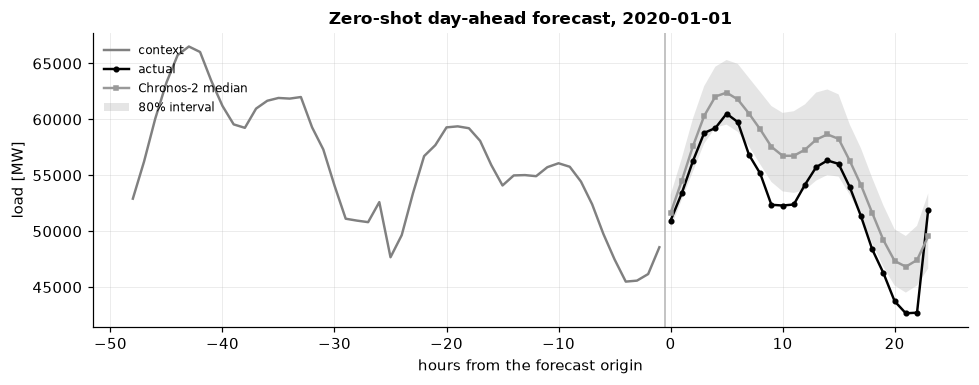


Sharpness and calibration trade off, and only one of them can be
gamed. An infinitely wide interval has perfect coverage and no value;
a zero-width one is maximally sharp and never right. Report both, or
report a proper scoring rule like CRPS, which penalises each.


In [73]:
import matplotlib.pyplot as plt

if chronos_quantiles is None:
    print("Skipped: no quantile forecasts available (offline mode).")
else:
    flat_truth = targets.ravel()
    for i, level in enumerate(QUANTILES):
        loss = pinball_loss(flat_truth, chronos_quantiles[:, :, i].ravel(), level)
        print(f"pinball loss at q{level:.1f}: {loss:8,.1f} MW")

    crps = crps_from_quantiles(
        flat_truth,
        chronos_quantiles.reshape(-1, len(QUANTILES)),
        QUANTILES,
    )
    lower = chronos_quantiles[:, :, QUANTILES.index(0.1)].ravel()
    upper = chronos_quantiles[:, :, QUANTILES.index(0.9)].ravel()
    empirical = coverage(flat_truth, lower, upper)
    print(f"\nCRPS                     : {crps:8,.1f} MW")
    print(f"80% interval coverage    : {empirical:.1%} (nominal 80.0%)")
    print(f"mean interval width      : {np.mean(upper - lower):8,.1f} MW")
    if empirical < 0.75:
        verdict = "too narrow — overconfident"
    elif empirical <= 0.85:
        verdict = "roughly calibrated"
    else:
        verdict = "too wide — conservative"
    print(f"\nThe interval is {verdict}.")

    day = 0
    hours = np.arange(HORIZON)
    fig, ax = plt.subplots(figsize=(9, 3.6))
    ax.plot(np.arange(-48, 0), contexts[day, -48:], color="0.5", label="context")
    ax.plot(hours, targets[day], "o-", color="black", ms=3, label="actual")
    ax.plot(hours, chronos_quantiles[day, :, 1], "s-", ms=3,
            label="Chronos-2 median")
    ax.fill_between(hours, chronos_quantiles[day, :, 0],
                    chronos_quantiles[day, :, 2], alpha=0.25,
                    label="80% interval")
    ax.axvline(-0.5, color="0.7", lw=1)
    ax.set_xlabel("hours from the forecast origin")
    ax.set_ylabel("load [MW]")
    ax.set_title(f"Zero-shot day-ahead forecast, {origins[day]:%Y-%m-%d}")
    ax.legend(loc="upper left", fontsize=8)
    fig.tight_layout()
    plt.show()

    print("\nSharpness and calibration trade off, and only one of them can be")
    print("gamed. An infinitely wide interval has perfect coverage and no value;")
    print("a zero-width one is maximally sharp and never right. Report both, or")
    print("report a proper scoring rule like CRPS, which penalises each.")

In [74]:
if chronos_quantiles is None:
    print("Skipped: offline mode.")
else:
    assert 0.0 <= empirical <= 1.0
    assert crps > 0, "CRPS is a positive loss"
    assert (upper >= lower - 1e-6).all(), "the interval bounds are crossed"
    print("Basic checks passed.")

Basic checks passed.


**Why this works.**

The pinball loss at q0.1 penalises *over*-prediction ten times more
heavily than under-prediction, and at q0.9 the asymmetry reverses. That
asymmetry is what makes each quantile converge to the right place, and
averaging the pinball loss across a dense set of levels is precisely
what approximates the CRPS.

CRPS is a *proper* scoring rule: it is minimised only by the true
predictive distribution, so it cannot be gamed by widening or narrowing
the interval. Coverage alone can be — which is why calibration should
never be reported without sharpness.

### Reflection Question 9.4 ★★★ — What does a foundation model actually change?

The measured result is likely to be undramatic: a zero-shot model
roughly level with a specialist trained on the target data. It is worth
being precise about why that would still be significant, and about what
it would not establish.

**Your task.** Answer three questions. (a) If the zero-shot model merely ties the
specialist, what has actually changed for a practitioner? (b) Name two
situations where you would still choose the specialist. (c) What claim
would this experiment *not* support, even if the foundation model won
outright?

**Expected outcome.** Part (c) is the one that matters. A single-series, single-horizon
comparison on synthetic data supports a narrow claim, and naming its
limits precisely is the skill being tested.

**(a) What changes if it only ties.** The cost structure, completely.
The specialist needed years of history for this specific series, a
feature pipeline, a training run per lead time, and a retraining
schedule for as long as it is in service. The foundation model needed
512 numbers and a forward pass. At parity of accuracy that is not a tie
— it is the same result at a small fraction of the engineering cost,
and it is available on day one for a new substation with no history at
all. The cold-start case is where this stops being a convenience and
starts being a capability nobody had.

**(b) Two cases for the specialist.** First, when the series has
**structure the foundation model cannot see**: a large industrial
customer whose load follows a production schedule, or a feeder whose
behaviour depends on a curtailment signal. A specialist can take those
as exogenous features; a univariate zero-shot forecast cannot, and no
amount of pretraining substitutes for information that was never in the
input. Second, when the deployment constraints bind: 120 M parameters
per forecast is a real latency and memory cost, and for thousands of
feeders forecast every five minutes on embedded hardware, a gradient
boosting model that fits in a megabyte wins on grounds that have nothing
to do with accuracy.

**(c) What this experiment does not support.** Almost any general
claim. It is *one* synthetic series, *one* horizon, *one* cadence, and
the aggregate MAE hides the regimes that matter operationally — storm
days, holidays, the winter peak. Specifically, it would not support:
"Chronos-2 beats gradient boosting for load forecasting" (one series is
not a population); "foundation models beat specialists" (one model
family, one domain); or "this will work on our grid" (synthetic data
was chosen precisely to rule out contamination, which also means it
omits every real-world irregularity — meter faults, missing data, tariff
changes, behaviour shifts).

What it *does* support is narrow and still worth having: a
general-purpose model, with no exposure to this data and no training on
it, produced day-ahead forecasts competitive with a specialist fitted to
it. That is evidence the pretraining transferred. Scaling that claim to
a fleet requires a fleet-sized evaluation, and the right next step is to
run this harness over many real series with per-regime breakdowns rather
than to generalise from one.

---

## Exercise 10 — Towards Grid Foundation Models

*Builds on [`10_grid_foundation_models.ipynb`](10_grid_foundation_models.ipynb).*

Everything converges here. A power grid is not a sequence and not an image:
it is a graph with physics on it, a different graph for every network, and
bus numbering that carries no meaning.

You will build a small grid foundation model — pretrain a message-passing
encoder on a population of networks with a masked objective, then transfer it
to a grid it has never seen — and validate it against the physics, not only
against the statistics.

This is the frontier. Nothing in this chapter is settled.

In [75]:
import numpy as np
import torch
from torch import nn

from ai_power_course.config import fast_mode, scaled, set_seed
from ai_power_course.grid.graphs import (
    EDGE_FEATURE_NAMES, NODE_FEATURE_NAMES, STATE_FEATURE_NAMES, net_to_graph,
)
from ai_power_course.grid.networks import load_network, run_power_flow
from ai_power_course.grid.sampling import SamplingConfig, sample_operating_points
from ai_power_course.metrics import mae
from ai_power_course.models.gnn import GraphBatch, MaskedGridModel, collate_graphs

set_seed()
torch.set_num_threads(min(4, torch.get_num_threads()))

PRETRAIN = ("case9", "case14", "case30")
HELDOUT = "case33bw"
N_SAMPLES = scaled(full=80, fast=26)

print(f"node features ({len(NODE_FEATURE_NAMES)}): {', '.join(NODE_FEATURE_NAMES)}")
print(f"  maskable state: {', '.join(STATE_FEATURE_NAMES)}")
print(f"edge features ({len(EDGE_FEATURE_NAMES)}): {', '.join(EDGE_FEATURE_NAMES)}")

config = SamplingConfig(n_samples=N_SAMPLES, seed=20260101)
pretrain_graphs, heldout_graphs = [], []
for offset, name in enumerate(PRETRAIN):
    points, _ = sample_operating_points(
        name, SamplingConfig(**{**config.__dict__, "seed": config.seed + 100 * offset})
    )
    pretrain_graphs.extend(p.graph for p in points)
points, _ = sample_operating_points(
    HELDOUT, SamplingConfig(**{**config.__dict__, "seed": config.seed + 9000})
)
heldout_graphs = [p.graph for p in points]

print(f"\npretraining: {len(pretrain_graphs)} states over {len(PRETRAIN)} grids "
      f"({', '.join(PRETRAIN)})")
print(f"held out   : {len(heldout_graphs)} states of {HELDOUT}, "
      f"{heldout_graphs[0]['node_features'].shape[0]} buses — never seen in pretraining")

node features (9): p_pu, q_pu, vm_pu, va_sin, va_cos, is_slack, is_pv, is_pq, log_base_kv
  maskable state: p_pu, q_pu, vm_pu, va_sin, va_cos
edge features (5): r_pu, x_pu, b_pu, is_transformer, tap_ratio



pretraining: 240 states over 3 grids (case9, case14, case30)
held out   : 80 states of case33bw, 33 buses — never seen in pretraining


### Coding Task 10.1 ★★★ — Permutation equivariance is not optional

Bus 14 is bus 14 because someone typed it. Renumber the network and it
is the same grid, so the model's per-bus outputs must simply come back
in the new order.

An MLP on a flattened state vector fails this immediately. A
message-passing network satisfies it by construction — and it is worth
*testing* rather than assuming, because a single indexing mistake breaks
it silently.

**Your task.** Write a function that permutes a graph's node ordering consistently,
then verify that the encoder's output permutes identically.

**Requirements**

- `permute_graph(graph, perm)` relabels the nodes *and* the edge endpoints.
- Edge features must follow their edges unchanged.
- Verify equivariance to `1e-5`.
- Also show that an MLP on the flattened state is **not** equivariant.

<details><summary><b>Hints</b></summary>

- If `perm` gives the new position of each old node, then `inverse[perm] = arange(n)` maps old indices to new ones, and `node_features[perm]` reorders the rows.
- Edges are indices into the node array, so apply the inverse mapping to `edge_index`.

</details>

**Expected outcome.** The message-passing encoder should match to floating-point precision.
The MLP should not — by a wide margin.

In [76]:
def permute_graph(graph, perm):
    """Relabel the buses of a graph. Same grid, different numbering."""
    n = graph["node_features"].shape[0]
    inverse = torch.empty(n, dtype=torch.long)
    inverse[perm] = torch.arange(n)
    return {
        "node_features": graph["node_features"][perm],
        "edge_index": inverse[graph["edge_index"]],
        "edge_features": graph["edge_features"],
    }

set_seed()
model = MaskedGridModel(
    node_dim=len(NODE_FEATURE_NAMES),
    edge_dim=len(EDGE_FEATURE_NAMES),
    d_model=64, n_layers=4, n_state=len(STATE_FEATURE_NAMES),
)

graph = heldout_graphs[0]
n_buses = graph["node_features"].shape[0]
perm = torch.randperm(n_buses, generator=torch.Generator().manual_seed(0))

original = model.embed(collate_graphs([graph]))
permuted = model.embed(collate_graphs([permute_graph(graph, perm)]))

gap = float((permuted - original[perm]).abs().max())
print(f"message passing, max |difference|: {gap:.2e}")
assert gap < 1e-5, "the grid encoder must be permutation equivariant"

# The contrast: an MLP on the flattened state vector.
set_seed()
flat_mlp = nn.Sequential(
    nn.Linear(n_buses * len(NODE_FEATURE_NAMES), 64), nn.GELU(), nn.Linear(64, 64)
)
flat_original = flat_mlp(graph["node_features"].reshape(1, -1))
flat_permuted = flat_mlp(graph["node_features"][perm].reshape(1, -1))
print(f"flat MLP,         max |difference|: "
      f"{float((flat_permuted - flat_original).abs().max()):.2e}")
print("\nThe MLP would have to LEARN that bus numbering is meaningless, from")
print("data, for every grid separately. The GNN cannot represent a violation")
print("of it. Building a symmetry into the architecture is worth more than any")
print("amount of data spent teaching it.")

message passing, max |difference|: 0.00e+00
flat MLP,         max |difference|: 5.56e-02

The MLP would have to LEARN that bus numbering is meaningless, from
data, for every grid separately. The GNN cannot represent a violation
of it. Building a symmetry into the architecture is worth more than any
amount of data spent teaching it.


In [77]:
_g = permute_graph(heldout_graphs[1], torch.arange(
    heldout_graphs[1]["node_features"].shape[0]))
assert torch.equal(_g["edge_index"], heldout_graphs[1]["edge_index"]), \
    "the identity permutation must leave the graph unchanged"
assert gap < 1e-5
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

The inverse permutation is the part people get wrong. `perm` says where
each old node *goes*; `edge_index` holds old indices that must be
rewritten as new ones, which is the inverse map. Using `perm` directly
on `edge_index` produces a different graph that still looks plausible —
same shapes, same degree distribution, wrong topology.

The identity-permutation check in the self-test is a cheap way to catch
exactly that: if you used `perm` where `inverse` belonged, the identity
case still passes, so the real assertion is the equivariance one.
Together they pin it down.

### Coding Task 10.2 ★★★ — Message passing in ten lines

Every graph neural network is the same three steps: compute a message
along each edge, sum the messages arriving at each node, update the node
from its own state and that sum.

$$m_{i \to j} = \phi([h_i, h_j, e_{ij}]), \qquad
  h_j' = h_j + \psi([h_j, \textstyle\sum_{i \in N(j)} m_{i \to j}])$$

No library needed. `index_add_` does the aggregation.

**Your task.** Implement one message-passing layer from scratch and verify that the
aggregation matches an explicit per-node loop.

**Requirements**

- `forward(x, edge_index, edge_features)` returns updated node embeddings of the same shape.
- Use **sum** aggregation via `index_add_`, not mean.
- Include a residual connection and a `LayerNorm`.
- Verify the aggregation against a loop over nodes.

<details><summary><b>Hints</b></summary>

- `edge_index[0]` is the source, `edge_index[1]` the target. `x[source]` gathers one row per edge.
- `torch.zeros_like(x).index_add_(0, target, messages)` scatters messages back to their target nodes, summing collisions.

</details>

**Expected outcome.** Agreement with the loop to floating-point precision, and an output that
keeps the input shape.

In [78]:
class MyMessagePassing(nn.Module):
    def __init__(self, d_model, edge_dim, hidden=None):
        super().__init__()
        hidden = hidden or 2 * d_model
        self.message = nn.Sequential(
            nn.Linear(2 * d_model + edge_dim, hidden), nn.GELU(),
            nn.Linear(hidden, d_model),
        )
        self.update = nn.Sequential(
            nn.Linear(2 * d_model, hidden), nn.GELU(), nn.Linear(hidden, d_model)
        )
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, edge_index, edge_features):
        source, target = edge_index[0], edge_index[1]
        messages = self.message(
            torch.cat([x[source], x[target], edge_features], dim=-1)
        )
        aggregated = torch.zeros_like(x).index_add_(0, target, messages)
        return self.norm(x + self.update(torch.cat([x, aggregated], dim=-1)))

set_seed()
layer = MyMessagePassing(d_model=32, edge_dim=len(EDGE_FEATURE_NAMES))
batch = collate_graphs(heldout_graphs[:2])
x = torch.randn(batch.n_nodes, 32)
out = layer(x, batch.edge_index, batch.edge_features)
print(f"nodes {batch.n_nodes}, edges {batch.edge_index.shape[1]} -> "
      f"output {tuple(out.shape)}")

with torch.no_grad():
    src, tgt = batch.edge_index[0], batch.edge_index[1]
    msgs = layer.message(torch.cat([x[src], x[tgt], batch.edge_features], dim=-1))
    vectorised = torch.zeros_like(x).index_add_(0, tgt, msgs)
    looped = torch.zeros_like(x)
    for edge in range(batch.edge_index.shape[1]):
        looped[tgt[edge]] += msgs[edge]
print(f"index_add_ vs explicit loop: "
      f"{float((vectorised - looped).abs().max()):.2e}")
print("\nThat is the whole of geometric deep learning on grids. Every graph")
print("library is this, plus batching, plus CUDA kernels.")

nodes 66, edges 128 -> output (66, 32)
index_add_ vs explicit loop: 0.00e+00

That is the whole of geometric deep learning on grids. Every graph
library is this, plus batching, plus CUDA kernels.


In [79]:
assert out.shape == x.shape, "a layer must preserve the embedding shape"
assert float((vectorised - looped).abs().max()) < 1e-4, \
    "index_add_ disagrees with the explicit loop"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

**Sum, not mean.** Mean aggregation would make a bus with two incident
lines indistinguishable from a bus with twenty carrying half the current
each — but total injected power is a *sum* over branches. The physics is
additive, so the aggregator should be too. This is one of the few places
where a domain argument settles an architecture choice cleanly.

Note that the receptive field grows by one hop per layer. Four layers
reach four buses away: enough for a distribution feeder, deliberately
not enough to see a whole transmission system. That is a real and
teachable limit, not an implementation detail.

### Coding Task 10.3 ★★★ — Pretrain on a population of grids

The pretraining task is BERT's, transplanted onto a power system: hide
the state of some buses, reconstruct it from the rest of the network.
Doing that well requires an internal model of how injections, voltages
and topology constrain one another — which is exactly the reusable
knowledge we want.

The training set is several *different grids*, with different sizes and
topologies. A fixed-width model could not even be evaluated on them.

**Your task.** Standardise the features across the population, write the masked
pretraining loop, and train the encoder on all pretraining grids at once.

**Requirements**

- Standardise node and edge features using statistics from the pretraining grids only.
- Mask 15% of buses per batch; score only the masked ones.
- Never mask the slack bus — its voltage is a reference, not an unknown.
- Report the loss curve.

<details><summary><b>Hints</b></summary>

- `MaskedGridModel(node_dim, edge_dim, d_model, n_layers, n_state)` already provides `apply_mask` and a learned `mask_token`.
- The slack flag is `NODE_FEATURE_NAMES.index('is_slack')` in the *unstandardised* features, so build the mask before standardising or keep the flag around.
- Batch with `collate_graphs`, which merges graphs instead of padding them.

</details>

**Expected outcome.** A loss that falls steadily. It will not reach zero — reconstructing a
hidden bus exactly requires solving the power flow, which four rounds of
message passing cannot do.

In [80]:
N_STATE = len(STATE_FEATURE_NAMES)
SLACK = NODE_FEATURE_NAMES.index("is_slack")

# Standardise across the population, using the pretraining grids only.
all_nodes = torch.cat([g["node_features"] for g in pretrain_graphs])
all_edges = torch.cat([g["edge_features"] for g in pretrain_graphs])
node_mean, node_std = all_nodes.mean(0), all_nodes.std(0).clamp(min=1e-6)
edge_mean, edge_std = all_edges.mean(0), all_edges.std(0).clamp(min=1e-6)

def standardise(graph):
    return {
        "node_features": (graph["node_features"] - node_mean) / node_std,
        "edge_index": graph["edge_index"],
        "edge_features": (graph["edge_features"] - edge_mean) / edge_std,
        "is_slack": graph["node_features"][:, SLACK] > 0.5,
    }

pretrain_std = [standardise(g) for g in pretrain_graphs]
heldout_std = [standardise(g) for g in heldout_graphs]

set_seed()
pretrained = MaskedGridModel(
    node_dim=len(NODE_FEATURE_NAMES), edge_dim=len(EDGE_FEATURE_NAMES),
    d_model=64, n_layers=4, n_state=N_STATE,
)
optimizer = torch.optim.AdamW(pretrained.parameters(), lr=3e-3)
gen = torch.Generator().manual_seed(0)
MASK_RATE, BATCH = 0.15, 8
STEPS = scaled(full=500, fast=60)

pretrain_loss = []
pretrained.train()
for step in range(1, STEPS + 1):
    picks = torch.randint(0, len(pretrain_std), (BATCH,), generator=gen)
    graphs = [pretrain_std[int(i)] for i in picks]
    batch = collate_graphs(graphs)
    is_slack = torch.cat([g["is_slack"] for g in graphs])

    mask = torch.rand(batch.n_nodes, generator=gen) < MASK_RATE
    mask = mask & ~is_slack
    if not mask.any():
        continue

    target = batch.node_features[:, :N_STATE]
    reconstruction = pretrained(batch, mask=mask)
    loss = torch.nn.functional.mse_loss(reconstruction[mask], target[mask])

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(pretrained.parameters(), 1.0)
    optimizer.step()
    pretrain_loss.append(float(loss.detach()))
    if step % max(1, STEPS // 6) == 0:
        print(f"step {step:4d}  masked reconstruction loss "
              f"{np.mean(pretrain_loss[-50:]):.4f}")
print(f"\nfirst 50 steps {np.mean(pretrain_loss[:50]):.4f} -> "
      f"last 50 steps {np.mean(pretrain_loss[-50:]):.4f}")
print("\nNot one label was used. The training signal came entirely from the")
print("structure of the operating states themselves — which is the whole")
print("proposition, because measurements are abundant in a grid and")
print("annotations are not.")

step   83  masked reconstruction loss 0.3123


step  166  masked reconstruction loss 0.1776


step  249  masked reconstruction loss 0.1814


step  332  masked reconstruction loss 0.1476


step  415  masked reconstruction loss 0.1459


step  498  masked reconstruction loss 0.1330

first 50 steps 0.4017 -> last 50 steps 0.1326

Not one label was used. The training signal came entirely from the
structure of the operating states themselves — which is the whole
proposition, because measurements are abundant in a grid and
annotations are not.


In [81]:
assert np.mean(pretrain_loss[-50:]) < np.mean(pretrain_loss[:50]), \
    "the pretraining loss did not fall"
assert pretrained.mask_token.shape == (N_STATE,)
_emb = pretrained.embed(collate_graphs(heldout_std[:1]))
assert _emb.shape[0] == heldout_std[0]["node_features"].shape[0], \
    "the encoder must handle a grid size it never saw"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

**Standardisation across the population is what makes transfer
possible at all.** A 9-bus transmission case and a 33-bus distribution
feeder have per-unit quantities on entirely different scales; without
shared statistics the encoder learns grid-specific magnitudes and the
transferred weights are worse than random initialisation. This was
measured during the course's development — the first version, without
standardisation, transferred *negatively*.

Excluding the slack bus from masking is a physics argument, not a
heuristic. Its voltage is the angular reference of the whole system;
asking the model to infer it is asking it to recover information that is
definitionally fixed, and the resulting loss term is pure noise.

### Coding Task 10.4 ★★★ — Transfer to a grid the model has never seen

The claim being tested: pretraining on *other* grids produces a
representation that makes learning on *this* grid cheaper in labels.

The downstream task is voltage-magnitude estimation from injections and
topology — a state-estimation-flavoured problem. The held-out grid is a
33-bus radial distribution feeder; the pretraining grids are meshed
transmission networks. This is a hard transfer, deliberately.

*Reuses what you wrote in 10.3 — do those first.*

**Your task.** Fine-tune the pretrained encoder and an identically-sized
randomly-initialised one on the held-out grid, across several label
budgets, under a matched optimisation budget.

**Requirements**

- Both conditions get identical data, steps, learning rate and seed.
- At least three label budgets, the smallest being tiny.
- Evaluate on held-out states of the same grid, never on the ones used for fitting.
- Report the relative improvement at each budget.

<details><summary><b>Hints</b></summary>

- Input: hide the voltage magnitude with the pretrained mask token, predict it. Target: the standardised `vm_pu` column.
- Equalise budgets by **steps**, not epochs — otherwise the small-budget condition gets far fewer updates.
- `MaskedGridModel(...)` fresh from `set_seed()` gives you the scratch condition with identical architecture.

</details>

**Expected outcome.** The largest advantage at the smallest budget, shrinking as labels
accumulate. If pretraining loses somewhere, report that too.

In [82]:
import copy

import pandas as pd

VM = STATE_FEATURE_NAMES.index("vm_pu")
N_TEST = scaled(full=30, fast=6)
BUDGETS = [5, 12] if fast_mode() else [5, 20, 40]
STEPS_FT = scaled(full=150, fast=30)

assert max(BUDGETS) + N_TEST <= len(heldout_std), (
    f"{max(BUDGETS)} training + {N_TEST} test states requested but only "
    f"{len(heldout_std)} sampled"
)

def voltage_task(graphs, mask_token):
    """Hide vm_pu everywhere; the target is the value that was hidden."""
    inputs, targets = [], []
    for g in graphs:
        features = g["node_features"].clone()
        targets.append(features[:, VM].clone())
        features[:, VM] = mask_token[VM]
        inputs.append({**g, "node_features": features})
    return inputs, targets

def run(model, n_train, seed=0):
    torch.manual_seed(seed)
    head = nn.Sequential(nn.Linear(64, 64), nn.GELU(), nn.Linear(64, 1))
    params = list(model.encoder.parameters()) + list(head.parameters())
    optimizer = torch.optim.AdamW(params, lr=1e-3)
    inputs, targets = voltage_task(heldout_std, model.mask_token.detach())
    fit_idx, test_idx = range(n_train), range(len(inputs) - N_TEST, len(inputs))

    model.train()
    for step in range(STEPS_FT):
        pick = [fit_idx[step % n_train]]
        batch = collate_graphs([inputs[i] for i in pick])
        target = torch.cat([targets[i] for i in pick])
        prediction = head(model.encoder(batch)).squeeze(-1)
        loss = torch.nn.functional.mse_loss(prediction, target)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        batch = collate_graphs([inputs[i] for i in test_idx])
        prediction = head(model.encoder(batch)).squeeze(-1)
        truth = torch.cat([targets[i] for i in test_idx])
    # Back to per-unit so the number means something.
    return float((prediction - truth).abs().mean()) * float(node_std[VM])

rows = []
for n_train in BUDGETS:
    warm = copy.deepcopy(pretrained)
    warm_mae = run(warm, n_train)

    set_seed()
    cold = MaskedGridModel(
        node_dim=len(NODE_FEATURE_NAMES), edge_dim=len(EDGE_FEATURE_NAMES),
        d_model=64, n_layers=4, n_state=N_STATE,
    )
    cold.mask_token.data = pretrained.mask_token.data.clone()
    cold_mae = run(cold, n_train)

    rows.append({"labels": n_train, "pretrained": warm_mae, "from scratch": cold_mae,
                 "improvement": 1 - warm_mae / cold_mae})
transfer = pd.DataFrame(rows).set_index("labels")
display(transfer.round(4))

best = transfer["improvement"].idxmax()
print(f"\nLargest gain at {best} labels: "
      f"{transfer.loc[best, 'improvement']:.1%} lower MAE in per unit.")
print("\nThe encoder was pretrained on meshed transmission networks and")
print("evaluated on a radial distribution feeder — different topology,")
print("different R/X ratio, different voltage level. What transferred is not")
print("'knowledge of case33bw'. It is something more general about how")
print("injections, impedances and voltages constrain one another.")

,pretrained,from scratch,improvement
labels,,,
5,0.0100,0.0181,0.4506
20,0.0126,0.0180,0.3014
40,0.0133,0.0214,0.3812



Largest gain at 5 labels: 45.1% lower MAE in per unit.

The encoder was pretrained on meshed transmission networks and
evaluated on a radial distribution feeder — different topology,
different R/X ratio, different voltage level. What transferred is not
'knowledge of case33bw'. It is something more general about how
injections, impedances and voltages constrain one another.


In [83]:
assert set(transfer.columns) == {"pretrained", "from scratch", "improvement"}
assert (transfer[["pretrained", "from scratch"]] > 0).all().all(), \
    "MAE must be positive"
assert (transfer[["pretrained", "from scratch"]] < 1.0).all().all(), \
    "an MAE above 1.0 per unit means something is badly wrong"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

**Copying `mask_token` into the scratch model** is what makes the
comparison fair. The masking mechanism has to be identical in both
conditions, otherwise the pretrained model gets an advantage from a
better-placed mask value rather than from its encoder — which would be a
real effect but not the one being claimed.

**Equalising by steps, not epochs**, is the other half. With five
labels and "ten epochs", the small-budget condition gets 50 updates while
the 60-label condition gets 600; the label-efficiency curve would then
mostly measure the optimisation budget.

`copy.deepcopy(pretrained)` per budget keeps the budgets independent.
Fine-tuning in place would mean each budget starts from the previous
one's weights, and the "improvement" would accumulate across rows for
entirely uninteresting reasons.

### Analysis Task 10.5 ★★★ — Statistical accuracy is not physical validity

A voltage profile can have an excellent MAE and still be a state the
network cannot physically be in. The residual of the AC power balance,

$$S = V \odot \overline{(YV)},$$

recovers the nodal injections a predicted voltage profile implies.
Comparing those with the injections that were actually scheduled tells
you whether the prediction is a realisable operating point or merely a
plausible-looking set of numbers. No statistical metric can answer
that question.

*Reuses what you wrote in 10.3, 10.4 — do those first.*

**Your task.** Train the voltage head properly, confirm it is accurate in per unit,
then compute the power-balance residual of its prediction and compare
it against the feeder's own total load.

**Requirements**

- Train the head first — an untrained model is bad at both statistics and physics, which would demonstrate nothing.
- Report the voltage MAE in per unit, and the mismatch in MW.
- Compare against the residual of the true solved state, which is the numerical floor.
- Express the mismatch as a share of the feeder's total load, because megawatts mean nothing without a denominator.

<details><summary><b>Hints</b></summary>

- `run_power_flow(net)` solves the base case; `internal_state(net)` returns the solved `(vm_pu, va_degree)` in the internal ordering that `get_ybus` uses.
- You predicted magnitudes only, so take the angles from the solved state — and note in your answer that this makes the check *optimistic*.
- `net.load.p_mw.sum()` is the feeder's total demand.

</details>

**Expected outcome.** A voltage MAE well under 1% of nominal — by any statistical standard a
good result — alongside a power mismatch that is a large fraction of
everything the feeder consumes. That gap is the entire point of the
task.

In [84]:
from ai_power_course.grid.physics import internal_state, power_balance_residual

net = load_network(HELDOUT)
assert run_power_flow(net), "the base case must converge"
vm_true, va_true = internal_state(net)
base_graph = standardise(net_to_graph(net))

# Train the head. An untrained one would be bad at BOTH statistics and
# physics, and would prove nothing; we want a model that looks good.
set_seed()
probe_model = copy.deepcopy(pretrained)
head_check = nn.Sequential(nn.Linear(64, 64), nn.GELU(), nn.Linear(64, 1))
optimizer = torch.optim.AdamW(
    list(probe_model.encoder.parameters()) + list(head_check.parameters()),
    lr=1e-3,
)
fit_inputs, fit_targets = voltage_task(
    heldout_std[:40], pretrained.mask_token.detach())

probe_model.train()
for step in range(scaled(full=400, fast=120)):
    batch = collate_graphs([fit_inputs[step % len(fit_inputs)]])
    target = fit_targets[step % len(fit_targets)]
    prediction = head_check(probe_model.encoder(batch)).squeeze(-1)
    loss = torch.nn.functional.mse_loss(prediction, target)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

inputs, _truths = voltage_task([base_graph], pretrained.mask_token.detach())
probe_model.eval()
with torch.no_grad():
    predicted_std = head_check(
        probe_model.encoder(collate_graphs(inputs))).squeeze(-1)
vm_pred = (predicted_std * node_std[VM] + node_mean[VM]).numpy()

voltage_mae = float(np.abs(vm_pred - vm_true).mean())
print(f"voltage MAE: {voltage_mae:.4f} per unit "
      f"({voltage_mae * 100:.2f}% of nominal)")
print(f"predicted range {vm_pred.min():.3f}-{vm_pred.max():.3f} pu, "
      f"true {vm_true.min():.3f}-{vm_true.max():.3f} pu")

# The angles come from the SOLVED state — we only predicted magnitudes.
# That makes this check optimistic, and it still fails.
predicted_residual = power_balance_residual(net, vm_pred, va_true)
true_residual = power_balance_residual(net, vm_true, va_true)
total_load = float(net.load.p_mw.sum())
print(f"\npredicted state: {predicted_residual['p_mismatch_mean_mw']:7.3f} MW "
      f"mean, {predicted_residual['p_mismatch_max_mw']:7.3f} MW max")
print(f"solved state   : {true_residual['p_mismatch_mean_mw']:7.3f} MW "
      f"mean, {true_residual['p_mismatch_max_mw']:7.3f} MW max")
print(f"\ntotal feeder load: {total_load:.2f} MW")
share = predicted_residual["p_mismatch_mean_mw"] / total_load
print(f"mean mismatch as a share of it: {share:.1%}")

print(f"\nVoltage error {voltage_mae * 100:.2f}% of nominal; the injections it")
print(f"implies are wrong by {share:.0%} of everything the feeder consumes.")
if voltage_mae < 0.02:
    print("By any statistical standard the first number is a good state")
    print("estimator. There is no operating point in which the second is true.")
else:
    print("(Reduced configuration: the head is undertrained, so the first")
    print("number is not yet good and the contrast is not yet the intended")
    print("one. Run the full configuration to see it.)")
print("\nThe solved state's residual is the numerical floor — zero, because it")
print("is by construction a solution of these equations. Everything above that")
print("floor is power appearing or vanishing at buses.")
print("\nThe model has learned the MARGINAL DISTRIBUTION of voltages — around")
print("1.0 per unit, rarely outside 0.9 to 1.1 — without the constraints that")
print("couple them. It is right on average and wrong as a system state, which")
print("is the failure mode that matters operationally and the one MAE cannot")
print("see. This is why physics validation is reported SEPARATELY and never")
print("averaged into a statistical score.")

voltage MAE: 0.0076 per unit (0.76% of nominal)
predicted range 0.926-0.997 pu, true 0.913-1.000 pu

predicted state:   1.706 MW mean,   7.670 MW max
solved state   :   0.000 MW mean,   0.000 MW max

total feeder load: 3.71 MW
mean mismatch as a share of it: 45.9%

Voltage error 0.76% of nominal; the injections it
implies are wrong by 46% of everything the feeder consumes.
By any statistical standard the first number is a good state
estimator. There is no operating point in which the second is true.

The solved state's residual is the numerical floor — zero, because it
is by construction a solution of these equations. Everything above that
floor is power appearing or vanishing at buses.

The model has learned the MARGINAL DISTRIBUTION of voltages — around
1.0 per unit, rarely outside 0.9 to 1.1 — without the constraints that
couple them. It is right on average and wrong as a system state, which
is the failure mode that matters operationally and the one MAE cannot
see. This is why physi

In [85]:
assert true_residual["p_mismatch_max_mw"] < 1e-3, \
    "the solved state should satisfy its own equations"
if fast_mode():
    print("Reduced configuration: skipping the accuracy check — 120 steps")
    print("is not enough to train the head to the point the task is making.")
else:
    assert voltage_mae < 0.02, \
        "train the head further — the point needs an ACCURATE model"
assert predicted_residual["p_mismatch_mean_mw"] > \
    true_residual["p_mismatch_mean_mw"], \
    "a prediction cannot beat the exact solution on its own residual"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

Training the head is what makes this task an argument rather than an
anecdote. An untrained model is bad at the statistics *and* the
physics, which shows nothing; the claim being demonstrated is that
those two can come apart, so the statistics have to be good.

Note what makes the check *optimistic*: only magnitudes were predicted,
so the angles came from the true solved state. A full state prediction
would have to get both right and the residual would be larger still.
Reporting the favourable variant and still finding a large mismatch is
stronger evidence than reporting the unfavourable one.

Expressing the mismatch as a share of total load matters too. A
mismatch of "1.7 MW" is meaningless in isolation — it is small for a
transmission system and catastrophic for a 3.7 MW distribution feeder.
Always give a physical quantity a denominator.

Tutorial 10 runs the same comparison with a physics-informed loss term
added. The gap narrows and does not close.

### Reflection Question 10.6 ★★★ — Design your own grid foundation model

The open question this course has been building towards:

> **What should the tokens of an electrical grid foundation model be?**

A language model has words. An image model has patches. A grid has …
buses? Lines? Substations? Time-steps of a bus? Feeders? Whole snapshots?

Nobody knows. The models that exist — GridFM, PowerGraph, the
grid-specific variants appearing since 2024 — disagree with each other,
and the disagreement is not a detail: the tokenisation decides what can
be masked, what transfers, and what the model can generalise across.

This is a genuinely open research question and there is no answer key.

**Your task.** Design a foundation model for a power-systems problem you actually care
about. Fill in the template below. You are being assessed on whether the
pieces are *consistent with each other* — pretraining objective with
token choice, evaluation with claim — not on ambition.

**Requirements**

- Name the token explicitly and say what one token *is*.
- The pretraining objective must be self-supervised: no labels.
- Say what you would evaluate zero-shot and what needs fine-tuning.
- Include at least one *physical* validation, separate from the statistical one.
- Name the failure mode you consider most likely, and the experiment that would reveal it.

<details><summary><b>Hints</b></summary>

- Start from what you want to transfer ACROSS — grids? seasons? voltage levels? — because that determines what a token must be comparable across.
- Per-unit normalisation is what makes a 110 kV and a 20 kV measurement commensurable. Without it, your tokens are not comparable and nothing transfers.
- A good sanity check: would your masked-reconstruction task be trivially solvable by interpolation? If so it will teach the model nothing.

</details>

**Expected outcome.** Internal consistency. The most common failure is a token choice that
cannot support the claimed downstream task — for example tokenising
whole snapshots and then claiming per-bus anomaly localisation.

### A Worked Example — a Foundation Model for Distribution-Feeder State

This is *one* consistent design, not the answer. Its purpose is to show
what "consistent" looks like; a good alternative might tokenise
completely differently and be equally defensible.

**1. The problem I care about.**
Medium-voltage distribution operators have measurements at the
substation and at a handful of large connections, and almost nothing in
between. I want a model that fills in the unmeasured state of a feeder
well enough to flag developing voltage and thermal problems before they
are visible at the substation.

**2. The token.**
One token is **one bus at one 15-minute interval**: a vector of
`(p_pu, q_pu, vm_pu, sin va, cos va, is_measured, is_slack,
has_generation, log_base_kv, sin/cos time-of-day, sin/cos day-of-year)`.
A feeder snapshot is a *set* of these tokens plus the branch impedances
connecting them; a sequence of snapshots is a set that grows along the
time axis.

This choice is driven by point 7: I want per-bus outputs, so the token
must be per-bus. Tokenising whole snapshots would make the downstream
task inexpressible.

**3. What makes tokens comparable across grids.**
Per-unit on a common base for the electrical quantities, and impedances
per unit on the same base. Per unit is what makes a 110 kV and a 20 kV
measurement the same kind of number — it is the domain's own answer to
the normalisation problem, arrived at a century before anyone needed it
for a neural network. The angle is represented as
$(\sin, \cos)$ so that the wraparound at $\pm\pi$ is not a
discontinuity, and the calendar features likewise.

**4. The pretraining corpus.**
Two sources. Real SCADA and smart-meter archives from as many feeders as
can be obtained — realistic but sparse and messy. And a much larger
synthetic corpus: public feeder models (SimBench, the IEEE European LV
feeder, the ENWL networks) driven by sampled load and PV profiles and
solved with a power flow, which gives complete, noise-free states in
unlimited quantity. The synthetic part carries the physics; the real
part carries the irregularity. Ordering matters: pretrain on synthetic,
continue on real.

**5. The self-supervised objective.**
Two terms.
*(a) Spatial masking.* Hide the state of a contiguous, randomly-sized
**region** of the feeder and reconstruct it. Contiguous rather than
scattered, for the reason task 4.1 established: scattered masking is
solvable by interpolating from neighbours, which teaches nothing, and a
contiguous region is what an actual measurement gap looks like.
*(b) Temporal masking.* Hide a block of intervals at some buses and
reconstruct them from the rest of the window.
Both are label-free. Neither is solvable without an internal model of
how injections propagate along an impedance.

**6. Architecture, and the symmetry it builds in.**
Message passing over the feeder graph, with attention over the time
axis. **Permutation equivariant** over buses — bus numbering is
arbitrary, as task 10.1 demonstrates — and **not** permutation invariant
over time, which is what the temporal positional encoding is for. The
same layer type, the opposite requirement on each axis. Depth is capped
around 6–8 message-passing rounds, which is roughly the electrical
diameter of a distribution feeder; more would over-smooth.

**7. Downstream tasks.**

| Task | How | Why |
| --- | --- | --- |
| Fill a measurement gap | Zero-shot | It *is* the pretraining objective |
| Estimate unmeasured voltages | Zero-shot, then a probe | Same objective, new mask |
| Flag a developing overload | Linear probe | Few labels; regimes already separate |
| Detect a topology error | Fine-tune | Needs a comparison pretraining never asks |
| Day-ahead feeder forecast | Fine-tune | Extrapolation is not interpolation |

**8. Evaluation.**
- *Statistical:* MAE and CRPS on held-out **feeders**, not held-out time
  steps of feeders that are in the training set. Broken down by how far
  a bus is from the nearest measurement, because the aggregate is
  dominated by easy buses near the substation.
- *Physical:* the AC power-balance residual of the reconstructed state,
  in kW, reported separately and never averaged into the statistical
  score — plus the rate at which the model predicts voltages outside
  EN 50160 limits when the true state is inside them, and vice versa.
- *Baselines it must beat:* linear interpolation along the feeder; a
  classical weighted-least-squares state estimator given the same
  measurements; and a per-feeder GNN trained from scratch on the target
  feeder's own labels. The third is the one that matters — if a scratch
  model matches it with the labels a real operator has, the foundation
  model has bought nothing.

**9. The most likely failure mode, and the experiment that reveals it.**
**The model learns the marginal distribution of voltages instead of the
constraints that couple them.** Distribution voltages live in a narrow
band; a model that always predicts something near the feeder's local
mean will score well on MAE while being useless for exactly the
excursions it was built to catch.

The experiment: evaluate *conditioned on the event*. Score only the
intervals where the true state violates a limit, and separately score
the model's predicted injections against the scheduled ones via the
power-balance residual. If MAE is good, event-conditional MAE is poor
and the residual is large, the model is a climatology with extra steps.
Task 10.5 is a miniature of exactly this diagnostic, and chapter 03's
error analysis is the same idea one chapter earlier.

**10. The thing I am least sure about.**
Whether the bus-at-an-instant token is right. Its weakness is that the
*topology* — which is what actually changes between feeders — enters only
through the edges, as features rather than as tokens. A design that
tokenised **branches** instead would make topology first-class and might
transfer better across feeders with different structures, at the cost of
making per-bus outputs indirect.

I do not know which is better, and I do not think anyone does yet. That
is a reason to run the comparison, not a reason to pick the familiar one.

---

## Exercise 11 — Federated Learning and Federated Foundation Models

*Builds on [`11_federated_learning_and_foundation_models.ipynb`](11_federated_learning_and_foundation_models.ipynb).*

**Optional / Advanced.** Chapters 01-10 are the onboarding course. This one
assumes you have finished them.

Four Distribution System Operators would like a shared model and cannot
pool their data. You will implement Federated Averaging from nothing, run a
federation round by hand, measure what heterogeneity does to it, count the
bytes a federated foundation model would actually move, and federate LoRA
adapters over a frozen backbone.

One sentence to keep in view throughout: raw training samples stay with
their operator, and model updates do not. Task 11.6 is about exactly that
distinction.

In [86]:
import copy

import numpy as np
import torch
from torch import nn

from ai_power_course.config import fast_mode, scaled, set_seed
from ai_power_course.federated import (
    ClientData, build_dso_clients, evaluate, local_train,
    standardise_clients, state_dict_bytes, trainable_state_dict,
)

set_seed()
torch.set_num_threads(min(4, torch.get_num_threads()))

N_SAMPLES = scaled(full=100, fast=40)
dso_clients = standardise_clients(build_dso_clients(n_samples=N_SAMPLES))
federation = [c for c in dso_clients if c.name != "DSO_D"]
N_FEATURES = dso_clients[0].x_train.shape[1]

def make_model():
    "The same small MLP for every experiment, so comparisons are like-for-like."
    return nn.Sequential(
        nn.Linear(N_FEATURES, 32), nn.ReLU(),
        nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 1),
    )

print(f"{len(federation)} participating DSOs, {len(dso_clients) - len(federation)} held out")
for _c in dso_clients:
    print(f"  {_c.name}  n_train={_c.n_train:4d}  "
          f"mean target={float(_c.y_train.mean()):.4f}  {_c.description}")

3 participating DSOs, 1 held out
  DSO_A  n_train=  75  mean target=0.9198  case33bw — residential radial feeder, high PV penetration
  DSO_B  n_train=  75  mean target=1.0097  case14 — rural, strong and variable wind generation
  DSO_C  n_train=  75  mean target=0.9430  case30 — urban, heavy demand with EV charging, little local DER
  DSO_D  n_train=  75  mean target=0.7244  case57 — mixed load and generation (held out for transfer)


### Coding Task 11.1 ★ — Implement FedAvg

Federated Averaging is one weighted mean over parameter tensors:

$$w_{t+1} = \sum_{k} \frac{n_k}{\sum_j n_j}\, w_{t+1}^{(k)}$$

The weighting by dataset size is the whole algorithm. A client with
ten times the data pulls the average ten times as hard.

**Your task.** Write `federated_average(client_weights, client_sizes)`, taking a
list of `state_dict`-like mappings and a list of sample counts, and
returning one aggregated mapping.

**Requirements**

- The output has exactly the same keys as the inputs.
- Every output tensor has the same shape as its inputs.
- Weighting is proportional to `client_sizes`, not uniform.
- The input mappings are NOT mutated.

<details><summary><b>Hints</b></summary>

- Iterate over the keys of the first client and build a new dict.
- `sum(state[k] * (n / total) for state, n in zip(...))` is enough.
- Returning `client_weights[0]` after in-place `+=` mutates the caller's tensors.

</details>

**Expected outcome.** With two clients holding 1 and 3 samples, the aggregate sits three
quarters of the way toward the second client.

In [87]:
def federated_average(client_weights, client_sizes):
    "Weighted mean of parameter tensors. Do not mutate the inputs."
    if len(client_weights) != len(client_sizes):
        raise ValueError("one size per client state is required")
    total = float(sum(client_sizes))
    if total <= 0:
        raise ValueError("total dataset size must be positive")

    aggregated = {}
    for key in client_weights[0]:
        # Start from a fresh tensor so the caller's state is untouched.
        acc = torch.zeros_like(client_weights[0][key], dtype=torch.float64)
        for state, size in zip(client_weights, client_sizes):
            acc += state[key].detach().to(torch.float64) * (size / total)
        aggregated[key] = acc.to(client_weights[0][key].dtype)
    return aggregated


state_a = {"w": torch.tensor([1.0, 2.0]), "b": torch.tensor([0.0])}
state_b = {"w": torch.tensor([3.0, 4.0]), "b": torch.tensor([2.0])}
aggregated = federated_average([state_a, state_b], [1, 3])
print(aggregated)
print(f"equal weighting would have given w = [2.0, 3.0]")

{'w': tensor([2.5000, 3.5000]), 'b': tensor([1.5000])}
equal weighting would have given w = [2.0, 3.0]


In [88]:
assert set(aggregated) == {"w", "b"}, "keys must be preserved"
assert aggregated["w"].shape == state_a["w"].shape, "shapes must be preserved"
assert torch.allclose(aggregated["w"], torch.tensor([2.5, 3.5])), (
    f"expected [2.5, 3.5] for sizes 1:3, got {aggregated['w'].tolist()}"
)
assert torch.allclose(aggregated["b"], torch.tensor([1.5]))
assert torch.allclose(state_a["w"], torch.tensor([1.0, 2.0])), (
    "inputs were mutated -- build a new dict instead of accumulating in place"
)
_uniform = torch.tensor([2.0, 3.0])
assert not torch.allclose(aggregated["w"], _uniform), (
    "this is the UNWEIGHTED mean; weight by client_sizes"
)
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

The two failure modes the check targets are the ones that actually
happen.

**Unweighted averaging** produces `[2.0, 3.0]` and looks perfectly
reasonable. It silently gives a client with three samples the same
influence as one with a thousand, and on a federation with unequal
partners that is a different algorithm with a different fixed point.

**In-place accumulation** into `client_weights[0]` passes every
numerical check on the first round and corrupts the federation
afterwards, because the server has just edited a client's tensors.
Building a fresh dict costs nothing and removes the class of bug.

The float64 accumulation is a small detail with a real effect: over
many clients, summing float32 products loses precision in exactly
the low-order bits that distinguish one round's update from the
next.

### Coding Task 11.2 ★★ — Build one federation round

A communication round is five steps: broadcast, local training,
collect, aggregate, evaluate. No framework required, and building it
once is what makes Flower legible later.

*Reuses what you wrote in 11.1 — do those first.*

**Your task.** Complete `federated_round`, which takes a global `state_dict` and
returns the aggregated state after one round over `federation`.
Then run it for several rounds and print the mean validation MAE.

**Requirements**

- Every client starts the round from a COPY of the global state.
- Each client trains only on its own data.
- Aggregation is weighted by each client's training-set size.
- The global model improves over the rounds you run.

<details><summary><b>Hints</b></summary>

- `copy.deepcopy(global_state)` before `load_state_dict`.
- `local_train(model, c.x_train, c.y_train, epochs=...)` runs the local step.
- Reuse your `federated_average` from 11.1.

</details>

**Expected outcome.** Mean validation MAE falls over the rounds. It will not match a
centrally trained model — that gap is the subject of the tutorial.

In [89]:
def federated_round(global_state, clients, local_epochs=10, lr=0.02):
    "One communication round. Returns the new global state."
    client_states, client_sizes = [], []
    for client in clients:
        model = make_model()
        model.load_state_dict(copy.deepcopy(global_state))   # broadcast
        local_train(                                          # local step
            model, client.x_train, client.y_train,
            epochs=local_epochs, lr=lr,
        )
        client_states.append(
            {k: v.detach().clone() for k, v in model.state_dict().items()}
        )
        client_sizes.append(client.n_train)
    return federated_average(client_states, client_sizes)


set_seed()
global_state = {k: v.clone() for k, v in make_model().state_dict().items()}
round_history = []
for round_index in range(5):
    global_state = federated_round(global_state, federation)
    probe = make_model()
    probe.load_state_dict(global_state)
    maes = [evaluate(probe, c.x_valid, c.y_valid) for c in federation]
    round_history.append(float(np.mean(maes)))
    print(f"round {round_index + 1}: mean validation MAE {round_history[-1]:.5f}")

round 1: mean validation MAE 0.10396
round 2: mean validation MAE 0.06141
round 3: mean validation MAE 0.05493
round 4: mean validation MAE 0.05105
round 5: mean validation MAE 0.04852


In [90]:
assert len(round_history) == 5, "run five rounds"
assert all(np.isfinite(round_history)), "some round produced a non-finite MAE"
assert round_history[-1] < round_history[0], (
    f"the federation should improve: {round_history[0]:.5f} -> "
    f"{round_history[-1]:.5f}. If it did not, check that each client "
    f"starts from a COPY of the global state rather than sharing it."
)
print(f"Checks passed: mean MAE fell from {round_history[0]:.5f} "
      f"to {round_history[-1]:.5f} over 5 rounds.")

Checks passed: mean MAE fell from 0.10396 to 0.04852 over 5 rounds.


**Why this works.**

The `copy.deepcopy` is the line that matters. Without it every
client holds a reference to the *same* tensors, so each one trains
on top of the previous client's work and the "average" is taken over
four views of one object. The loop still runs, the loss still falls,
and the algorithm is no longer FedAvg — it is sequential training
with extra steps.

That failure is worth seeing once, because it produces plausible
output and no error.

### Analysis Task 11.3 ★★ — Analyse non-IID clients

The four DSOs run different networks under different regimes. Their
targets have visibly different distributions, which is the point:
a federation of identical clients would not test anything.

*Reuses what you wrote in 11.1, 11.2 — do those first.*

**Your task.** Compare local-only, centralized and federated training, and report
**per-client** metrics rather than one average.

**Requirements**

- Train one local model per DSO on its own data.
- Train one centralized model on the pooled data.
- Run a federation with the same total local budget.
- Report per-client MAE, the mean, and the worst client.

<details><summary><b>Hints</b></summary>

- `torch.cat` the participants' tensors for the centralized model.
- Reuse `federated_round` from 11.2.
- Give every method the same number of local epochs to keep it fair.

</details>

**Expected outcome.** The per-client column varies substantially. Whether federation beats
local training will depend on the client — that variation is the
finding, not a defect.

In [91]:
import pandas as pd

EPOCHS = 20

# --- local only
local_scores = {}
for client in federation:
    set_seed()
    model = make_model()
    local_train(model, client.x_train, client.y_train, epochs=EPOCHS, lr=0.02)
    local_scores[client.name] = evaluate(model, client.x_valid, client.y_valid)

# --- centralized
set_seed()
pooled_x = torch.cat([c.x_train for c in federation])
pooled_y = torch.cat([c.y_train for c in federation])
central = make_model()
local_train(central, pooled_x, pooled_y, epochs=EPOCHS, lr=0.02)
central_scores = {
    c.name: evaluate(central, c.x_valid, c.y_valid) for c in federation
}

# --- federated
set_seed()
state = {k: v.clone() for k, v in make_model().state_dict().items()}
for _ in range(5):
    state = federated_round(state, federation, local_epochs=EPOCHS // 5)
fed_model = make_model()
fed_model.load_state_dict(state)
federated_scores = {
    c.name: evaluate(fed_model, c.x_valid, c.y_valid) for c in federation
}

comparison = pd.DataFrame({
    "local only": local_scores,
    "centralized": central_scores,
    "federated": federated_scores,
})
comparison.loc["mean"] = comparison.mean()
comparison.loc["worst client"] = comparison.iloc[:-1].max()
print(comparison.round(5))
print()
print(f"Best mean: {comparison.loc['mean'].idxmin()}")
print(f"Best worst-case: {comparison.loc['worst client'].idxmin()}")

              local only  centralized  federated
DSO_A            0.04346      0.05531    0.04840
DSO_B            0.04028      0.05891    0.08967
DSO_C            0.05088      0.02677    0.04534
mean             0.04487      0.04700    0.06114
worst client     0.05088      0.05891    0.08967

Best mean: local only
Best worst-case: local only


In [92]:
assert set(local_scores) == {c.name for c in federation}, (
    "score every participating DSO"
)
assert set(central_scores) == set(local_scores)
assert set(federated_scores) == set(local_scores)
_spread = max(local_scores.values()) - min(local_scores.values())
assert _spread > 0, "per-client scores should differ -- these clients are not identical"
print(f"Checks passed. Spread across clients, local-only: {_spread:.5f} pu")

Checks passed. Spread across clients, local-only: 0.01060 pu


**Why this works.**

The number to look at is the spread, not the mean.

A federation is usually reported as one global metric, and one
global metric is exactly the statistic that hides a participant the
federation is failing. If DSO B's error under the global model is
worse than the model it could have trained alone, then B is paying
for the federation and receiving nothing — and the average will not
say so.

This is why the tutorial reports mean, worst client and spread
everywhere, and why personalization (a shared body with a local
head) exists as an architecture rather than as an afterthought.

### Coding Task 11.4 ★★ — Communication accounting

Federated learning is a systems problem as much as an optimisation
problem. Before adopting a method, count the bytes it moves.

**Your task.** Write `model_size_bytes(parameters)` and use it to compare the
communication cost of federating a full model against federating
only a small adapter, over several rounds and clients.

**Requirements**

- `model_size_bytes` sums `numel() * element_size()` over the tensors.
- Count BOTH directions: server to client and client to server.
- Report per-round and total cost.
- Extrapolate to a 1-billion-parameter model.

<details><summary><b>Hints</b></summary>

- `tensor.element_size()` is the bytes per value; do not assume 4.
- Per round the wire carries `2 * n_clients * payload`.
- A billion float32 parameters is 4 GB per message.

</details>

**Expected outcome.** The adapter payload is orders of magnitude smaller, and the
billion-parameter extrapolation is large enough to rule out naive
full-model federation.

In [93]:
def model_size_bytes(parameters):
    "Total bytes of a mapping of name -> tensor."
    return int(sum(t.numel() * t.element_size() for t in parameters.values()))


full_payload = make_model().state_dict()
adapter_payload = {"A": torch.zeros(4, 32), "B": torch.zeros(32, 4)}

N_CLIENTS, N_ROUNDS_ACCT = 4, 50
full_bytes = model_size_bytes(full_payload)
adapter_bytes = model_size_bytes(adapter_payload)

def total_mb(payload_bytes, clients=N_CLIENTS, rounds=N_ROUNDS_ACCT):
    # Both directions: down to every client and back up again.
    return payload_bytes * clients * 2 * rounds / 1e6

print(f"full model : {full_bytes:,} bytes/message, "
      f"{total_mb(full_bytes):.3f} MB over {N_ROUNDS_ACCT} rounds")
print(f"adapter    : {adapter_bytes:,} bytes/message, "
      f"{total_mb(adapter_bytes):.3f} MB over {N_ROUNDS_ACCT} rounds")
print(f"ratio      : {full_bytes / adapter_bytes:.1f}x")
print()

billion = 1_000_000_000 * 4          # float32
print(f"A 1B-parameter model, 100 clients, 100 rounds:")
print(f"  {billion / 1e9:.0f} GB per message")
print(f"  {billion * 100 * 2 / 1e12:.1f} TB per round")
print(f"  {billion * 100 * 2 * 100 / 1e12:,.0f} TB in total")

full model : 3,332 bytes/message, 1.333 MB over 50 rounds
adapter    : 1,024 bytes/message, 0.410 MB over 50 rounds
ratio      : 3.3x

A 1B-parameter model, 100 clients, 100 rounds:
  4 GB per message
  0.8 TB per round
  80 TB in total


In [94]:
_expected = sum(t.numel() * t.element_size() for t in full_payload.values())
assert model_size_bytes(full_payload) == _expected, (
    "size must use numel() * element_size(), summed over all tensors"
)
assert model_size_bytes({}) == 0, "an empty payload is zero bytes"
_half = {"x": torch.zeros(10, dtype=torch.float16)}
assert model_size_bytes(_half) == 20, (
    f"float16 is 2 bytes per value, so 10 values is 20 bytes, "
    f"got {model_size_bytes(_half)} -- do not hard-code 4 bytes"
)
assert adapter_bytes < full_bytes, "the adapter should be the smaller payload"
print("Basic checks passed.")

Basic checks passed.


**Why this works.**

The float16 case in the check is there on purpose. Hard-coding four
bytes per parameter is the natural shortcut, it is right for
float32, and it silently doubles every number the moment anyone
quantises — which is one of the standard communication-reduction
techniques and therefore exactly when the accounting matters.

Counting both directions matters for the same reason. Reporting only
the upload halves the total and makes every method look twice as
good as it is.

### Coding Task 11.5 ★★★ — Federated LoRA

The communication arithmetic rules out shipping a foundation model
every round. LoRA's answer: freeze the backbone, learn a low-rank
update, and federate only the adapters.

$$W' = W + BA, \qquad \operatorname{rank}(BA) \ll \min(\dim W)$$

*Reuses what you wrote in 11.1 — do those first.*

**Your task.** Wrap a model's `Linear` layers in LoRA modules, freeze the base
weights, and aggregate *only* the adapter tensors across clients.

**Requirements**

- Base weights have `requires_grad = False`.
- Adapter tensors A and B have `requires_grad = True`.
- `B` is zero-initialised, so the adapted model starts equal to the base.
- Only adapter tensors are aggregated.

<details><summary><b>Hints</b></summary>

- `trainable_state_dict(model)` returns exactly the `requires_grad` tensors.
- Zero-initialising B makes `W + BA == W` at step zero.
- Reuse `federated_average` from 11.1 on the adapter payload only.

</details>

**Expected outcome.** The aggregated payload is a small fraction of the full model, and
the backbone is provably untouched by the round.

In [95]:
class LoRALinear(nn.Module):
    def __init__(self, base, rank=4, alpha=8.0):
        super().__init__()
        self.base = base
        for p in self.base.parameters():
            p.requires_grad = False                    # frozen backbone
        self.A = nn.Parameter(torch.randn(rank, base.in_features) * 0.01)
        self.B = nn.Parameter(torch.zeros(base.out_features, rank))
        self.scaling = alpha / rank

    def forward(self, x):
        return self.base(x) + (x @ self.A.T @ self.B.T) * self.scaling


def add_lora(model, rank=4):
    for name, child in list(model.named_children()):
        if isinstance(child, nn.Linear):
            setattr(model, name, LoRALinear(child, rank=rank))
        else:
            add_lora(child, rank)
    return model


set_seed()
lora_model = add_lora(make_model(), rank=4)
lora_payload = trainable_state_dict(lora_model)

n_trainable = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in lora_model.parameters())
print(f"trainable {n_trainable:,} / {n_total:,} ({n_trainable / n_total:.1%})")
print(f"aggregated tensors ({len(lora_payload)}): {list(lora_payload)}")

# Federate the adapters only, across three simulated clients.
adapters = [trainable_state_dict(add_lora(make_model(), rank=4))
            for _ in range(len(federation))]
merged = federated_average(adapters, [c.n_train for c in federation])
print(f"merged adapter tensors: {list(merged)}")

trainable 420 / 1,253 (33.5%)
aggregated tensors (6): ['0.A', '0.B', '2.A', '2.B', '4.A', '4.B']
merged adapter tensors: ['0.A', '0.B', '2.A', '2.B', '4.A', '4.B']


In [96]:
_bases = [m for m in lora_model.modules() if isinstance(m, LoRALinear)]
assert _bases, "no LoRALinear layers were inserted"
assert all(not p.requires_grad for m in _bases for p in m.base.parameters()), (
    "base weights must be frozen (requires_grad = False)"
)
assert all(m.A.requires_grad and m.B.requires_grad for m in _bases), (
    "adapter tensors A and B must be trainable"
)
assert all(torch.allclose(m.B, torch.zeros_like(m.B)) for m in _bases), (
    "B must be zero-initialised so the adapted model starts equal to the base"
)
assert all("base" not in k for k in lora_payload), (
    f"only adapters should be aggregated, but the payload contains "
    f"{[k for k in lora_payload if 'base' in k][:3]}"
)
_full = sum(t.numel() for t in make_model().state_dict().values())
_lora = sum(t.numel() for t in lora_payload.values())
assert _lora < _full, "the adapter payload should be smaller than the full model"
print(f"Checks passed: {_lora:,} adapter values vs {_full:,} full-model values.")

Checks passed: 420 adapter values vs 833 full-model values.


**Why this works.**

Zero-initialising `B` is the detail that makes this work rather than
merely compile. With `B = 0` the product `BA` is zero, so the adapted
model is *exactly* the base model before any training. Every client
therefore starts the federation from the same function, which is the
precondition for averaging their adapters to mean anything.

Initialise both matrices randomly and each client starts from a
different perturbation of the backbone; the average of those is not
a sensible starting point, and the federation spends its first
rounds undoing the initialisation.

A subtlety worth knowing about, which this task does not implement:
averaging `A` and `B` separately is not the same as averaging the
product `BA`, because the mean of products is not the product of
means. Methods such as FFA-LoRA and FlexLoRA exist precisely to deal
with that discrepancy.

### Reflection Question 11.6 ★★ — Critique a privacy claim

A vendor proposal lands on your desk containing one sentence:

> "Federated learning makes the training data private."

**Your task.** Critique it. A yes/no answer is not the exercise — separate the
claims that are true from the ones that are not, and say what would
have to be added before the sentence could be defended.

**Requirements**

- Distinguish raw data locality from privacy.
- Explain what a model update can leak.
- Name what secure aggregation adds, and what it does not.
- Name what differential privacy adds, and what it costs.
- State why a threat model has to come first.

**Expected outcome.** A paragraph a colleague could act on, not a verdict.

**What the sentence gets right.** Under the standard architecture
raw training samples do stay with the operator that owns them. That
is a genuine and useful property — it can satisfy a contractual
restriction on data transfer, and it removes the central database
that would otherwise be the single most attractive target.

**What it gets wrong.** It conflates *data locality* with *privacy*.
Model updates leave the client every round, and an update is a
deterministic function of the data that produced it. Tutorial 11
measures this directly: updates computed from the same data are
nearly identical, and updates from different data are visibly
different. Anything carrying that much reliable signal is a channel.

**What an update can leak.** Gradient-inversion work (Zhu et al.
2019; Geiping et al. 2020) reconstructs training samples from shared
gradients, and a parameter difference is an accumulated gradient.
More realistic for a DSO is membership inference — not "reconstruct
this household's profile" but "was this feeder in the training set",
which can itself be commercially sensitive. Repeated observation
across rounds leaks more than a single round does.

**Secure aggregation** stops the *server* from seeing any individual
update; it learns only the sum. It does not stop the sum itself from
encoding information, and with only four participants a server
colluding with two of them can isolate a third.

**Differential privacy** bounds how much any single unit can
influence the published model, which is the only formal guarantee
available here. It costs accuracy, and the cost falls hardest on
rare events — which in a power system are the overloads and unusual
outages that are the most valuable things to learn from.

**Why the threat model comes first.** "Private" is not a property of
a system, it is a property of a system relative to an adversary.
Protecting against an honest-but-curious server, a competitor inside
the federation, and a malicious participant are three different
engineering problems with three different answers. A proposal that
does not name its adversary cannot be evaluated, only believed.

**What I would require.** A named threat model; a statement of the
privacy unit (measurement, household, feeder, or operator); if DP is
claimed, the mechanism, the accountant and the resulting epsilon,
not just "noise is added"; and whether secure aggregation is
actually implemented or merely described.

### Reflection Question 11.7 ★★★ — Design a Federated GridFM

Four European DSOs want a transferable grid foundation model. They
will not exchange raw feeder models or measurements. They have
different network sizes, different voltage levels and partly
different measurement infrastructure.

**Your task.** Specify the system. There is no uniquely correct design — the
exercise is to make choices and defend them.

**Requirements**

- Client definition: what is one client?
- Data and modalities available locally.
- Which components are global, and which stay local.
- The self-supervised pretraining objective.
- What exactly is aggregated.
- What federation protects, and what else would be needed.
- How transfer to an unseen fifth DSO is evaluated.
- How communication cost is controlled.
- How the model is checked for physical plausibility.

**Expected outcome.** A design a colleague could criticise on specifics.

One defensible design. Other choices are defensible too; what
follows commits to specifics so it can be argued with.

**Client definition.** One client is one DSO, not one feeder. This
is cross-silo: a handful of large, persistent, contractually bound
participants. Making a feeder the client would multiply the
participant count without adding institutional diversity, and it is
the institution that owns the legal constraint.

**Local data and modalities.** Each DSO holds network topology and
equipment parameters, plus some subset of SCADA, smart meters, PMU
and market data. Assume the subsets differ, because they do.

**Global components.** A message-passing encoder over the grid
graph. This is the only architecture that survives the fact that
every operator has a different number of buses — a fixed-width model
cannot even be evaluated across them. Per-modality input adapters
are also global where two operators share a modality.

**Local components.** Task heads, and any modality encoder unique to
one operator. Keeping the head local is both the personalization
mechanism and the strongest privacy property in the design: a
component that is never transmitted cannot be inverted from an
update.

**Pretraining objective.** Masked state reconstruction: hide bus
features, rebuild them from the rest of the network. It needs no
labels, which is what makes it federatable — the operators never
have to agree on a label schema. Add a physics-informed term
penalising AC power-balance violation at the reconstructed state, so
the representation is pushed toward physically realisable states
rather than merely plausible numbers.

**What is aggregated.** Encoder parameters, weighted by each
operator's number of operating points. Once the encoder is large
enough for that payload to matter, freeze it and federate LoRA
adapters instead; the tutorial's arithmetic shows where that
crossover sits.

**Privacy.** Federation keeps raw feeder models and measurements
local. That is all it does. On top of it I would want secure
aggregation, so no single operator's update is visible to the server
or to a competitor in the federation; and DP with a *per-operator*
privacy unit if the participants' concern is commercial rather than
personal. The tension to state openly is that a rare congestion
event is both the most valuable training signal and the most
identifying record.

**Transfer evaluation.** Hold out a fifth DSO entirely. Freeze the
encoder, fit only a small head, and measure error as a function of
labelled operating points from that operator — 5, 10, 25, 100.
Compare against a specialist trained on the fifth DSO alone and
against predicting the training mean. The interesting result is
label efficiency at the low end, not the ceiling at the high end.

**Communication.** Federate adapters rather than the backbone;
distribute the frozen backbone once. Reduce round frequency before
reducing client count. Quantise the payload, and account for the
saving honestly in both directions.

**Physical validation.** Statistical error is not sufficient. For
each predicted state, compute the AC power-balance residual against
the operator's own network model, check voltage magnitudes against
operating limits, and confirm losses are positive. A model with good
MAE that predicts physically impossible states has learned the
dataset, not the grid — and the whole argument for a grid foundation
model is that it learned the grid.

---

## That is the whole track

Forty-four tasks from a linear regression on lagged load to a
message-passing encoder pretrained on a population of grids. Two things
are worth saying at the end.

**The worked answers here are not the only correct ones.** Several tasks —
3.4, 9.4, and the final challenge above — have defensible alternatives, and
a student who reaches a different conclusion *with the numbers to support
it* has done the exercise better than one who reproduced this text.

**The last question is still open.** Nobody knows what the tokens of a grid
foundation model should be. The worked example in task 10.6 is one
consistent design; it is not the answer, and it says so. If a student
argues convincingly that branches beat buses, that is a research
contribution, not a wrong answer.